In [9]:
# =====================================================
#  Dataset Builder for G-code Layers (with Areas)
# =====================================================
# Features:
# - Reads multiple .gcode files
# - Extracts layers dynamically by Z height
# - Skips the 3rd layer (index 2)
# - Pads to maximum number of layers & points
# - Stores per-layer convex hull area (raw + normalized)
# - Outputs a clean .npy dataset
# =====================================================

import os
import re
import numpy as np
from pathlib import Path


# =====================================================
#  Configuration
# =====================================================
gcode_dir = Path(r"C:\Users\matsi\CodePResearch\Testing GAN\Coding of GAN\DataSetV2")

# Find all G-code files
gcode_files = list(gcode_dir.glob("*.gcode"))
print(f"🧾 Found {len(gcode_files)} G-code files.")

# Parameters
z_tolerance = 1e-3       # precision tolerance
outlier_threshold = 1e-3 # filter near-zero points like (0,0)


# =====================================================
#  Geometry Helper Functions
# =====================================================
def convex_hull(points: np.ndarray):
    """Compute convex hull vertices (CCW) using monotone chain algorithm."""
    pts = np.unique(points, axis=0)
    if len(pts) <= 1:
        return pts

    # Sort by x, then y
    pts = pts[np.lexsort((pts[:,1], pts[:,0]))]

    def cross(o, a, b):
        return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])

    # Build lower hull
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    # Build upper hull
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))

    hull = np.array(lower[:-1] + upper[:-1], dtype=float)
    return hull


def polygon_area(points: np.ndarray) -> float:
    """Shoelace formula for polygon area. Points must be ordered."""
    if len(points) < 3:
        return 0.0
    x, y = points[:,0], points[:,1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def convex_hull_area(points: np.ndarray) -> float:
    """Compute convex hull area for a set of points."""
    if len(points) < 3:
        return 0.0
    hull = convex_hull(points)
    return polygon_area(hull)


# =====================================================
#  G-code Parsing
# =====================================================
def extract_layers_dynamically(filepath):
    """Parse one G-code file and extract layers as arrays of (x,y) points."""
    with open(filepath, 'r') as f:
        lines = f.readlines()

    layer_dict = {}
    current_z = None
    last_x, last_y = None, None

    for line in lines:
        if line.startswith(";") or not any(axis in line for axis in ["X", "Y", "Z"]):
            continue

        # Match XYZ coordinates
        x_match = re.search(r"X(-?\d*\.?\d+)", line)
        y_match = re.search(r"Y(-?\d*\.?\d+)", line)
        z_match = re.search(r"Z(-?\d*\.?\d+)", line)

        if z_match:
            current_z = round(float(z_match.group(1)), 3)
            if current_z not in layer_dict:
                layer_dict[current_z] = []

        if x_match:
            last_x = float(x_match.group(1))
        if y_match:
            last_y = float(y_match.group(1))

        # Save point if valid
        if current_z is not None and last_x is not None and last_y is not None:
            if abs(last_x) > outlier_threshold or abs(last_y) > outlier_threshold:
                layer_dict[current_z].append([last_x, last_y])

    # Sort by Z and convert to arrays
    sorted_z = sorted(layer_dict.keys())
    sorted_layers = [np.array(layer_dict[z]) for z in sorted_z]

    return sorted_layers


# =====================================================
#  Extract Dataset from All Files
# =====================================================
all_data = []
labels = []
max_layers = 0
max_points = 0

for file in gcode_files:
    layers = extract_layers_dynamically(file)

    # 🚨 Skip the 3rd layer (index 2)
    layers = [layer for i, layer in enumerate(layers) if i not in (0, 2)]

    all_data.append(layers)
    labels.append(file.stem)  # filename stem as label

    max_layers = max(max_layers, len(layers))
    max_points = max(max_points, max((len(l) for l in layers), default=0))

print(f"📏 Max layers (after skipping 3rd): {max_layers}, Max points per layer: {max_points}")


# =====================================================
#  Padding + Area Computation
# =====================================================
final_array = []
layer_index_array = []
areas_array = []

for layers in all_data:
    padded_layers = []
    layer_indices = []
    layer_areas = []

    for i, layer in enumerate(layers):
        # --- area before padding ---
        area_val = convex_hull_area(layer) if layer.shape[0] > 2 else 0.0
        layer_areas.append(area_val)

        # --- pad points ---
        n = layer.shape[0]
        if n < max_points:
            pad = np.pad(layer, ((0, max_points - n), (0, 0)),
                         mode='constant', constant_values=0)
        else:
            pad = layer[:max_points]
        padded_layers.append(pad)
        layer_indices.append(i)

    # Pad extra empty layers
    while len(padded_layers) < max_layers:
        padded_layers.append(np.zeros((max_points, 2)))
        layer_indices.append(len(layer_indices))
        layer_areas.append(0.0)  # area = 0 for empty layer

    final_array.append(padded_layers)
    layer_index_array.append(layer_indices)
    areas_array.append(layer_areas)

final_array = np.array(final_array)              # [num_files, max_layers, max_points, 2]
layer_index_array = np.array(layer_index_array)  # [num_files, max_layers]
areas_array = np.array(areas_array)              # [num_files, max_layers]


# =====================================================
#  Area Normalization
# =====================================================
amin = areas_array.min()
amax = areas_array.max()
areas_norm_array = (areas_array - amin) / (amax - amin + 1e-8)


# =====================================================
#  Labels
# =====================================================
unique_labels = sorted(set(labels))
label_to_idx = {name: i for i, name in enumerate(unique_labels)}
int_labels = np.array([label_to_idx[l] for l in labels])


# =====================================================
#  Save Dataset
# =====================================================
dataset = {
    "data": final_array,               # (N, L, P, 2)
    "labels": int_labels,              # (N,)
    "label_names": labels,             # e.g., ["cube", "gear-spur", ...]
    "label_map": label_to_idx,         # str -> int
    "layer_indices": layer_index_array,# (N, L)
    "areas": areas_array,              # raw areas
    "areas_norm": areas_norm_array     # normalized 0–1
}

output_path = gcode_dir / "gcode_layers_V3.npy"
np.save(output_path, dataset, allow_pickle=True)

print(f"✅ Saved: {output_path}")
print(f"📐 Data shape: {final_array.shape}")
print(f"🏷️ Labels: {labels}")
print(f"🔑 Label map: {label_to_idx}")
print(f"🔢 Layer indices shape: {layer_index_array.shape}")
print(f"📏 Raw Areas shape: {areas_array.shape}, range=({amin:.3f}, {amax:.3f})")
print(f"📏 Norm Areas shape: {areas_norm_array.shape}, range=({areas_norm_array.min():.3f}, {areas_norm_array.max():.3f})")


🧾 Found 10 G-code files.
📏 Max layers (after skipping 3rd): 99, Max points per layer: 1234
✅ Saved: C:\Users\matsi\CodePResearch\Testing GAN\Coding of GAN\DataSetV2\gcode_layers_V3.npy
📐 Data shape: (10, 99, 1234, 2)
🏷️ Labels: ['cube', 'cylinder', 'flange', 'gear-bevel', 'gear-spur', 'lead-screw', 'nut', 'propeller', 'pyramid', 'sphere']
🔑 Label map: {'cube': 0, 'cylinder': 1, 'flange': 2, 'gear-bevel': 3, 'gear-spur': 4, 'lead-screw': 5, 'nut': 6, 'propeller': 7, 'pyramid': 8, 'sphere': 9}
🔢 Layer indices shape: (10, 99)
📏 Raw Areas shape: (10, 99), range=(0.000, 384.160)
📏 Norm Areas shape: (10, 99), range=(0.000, 1.000)


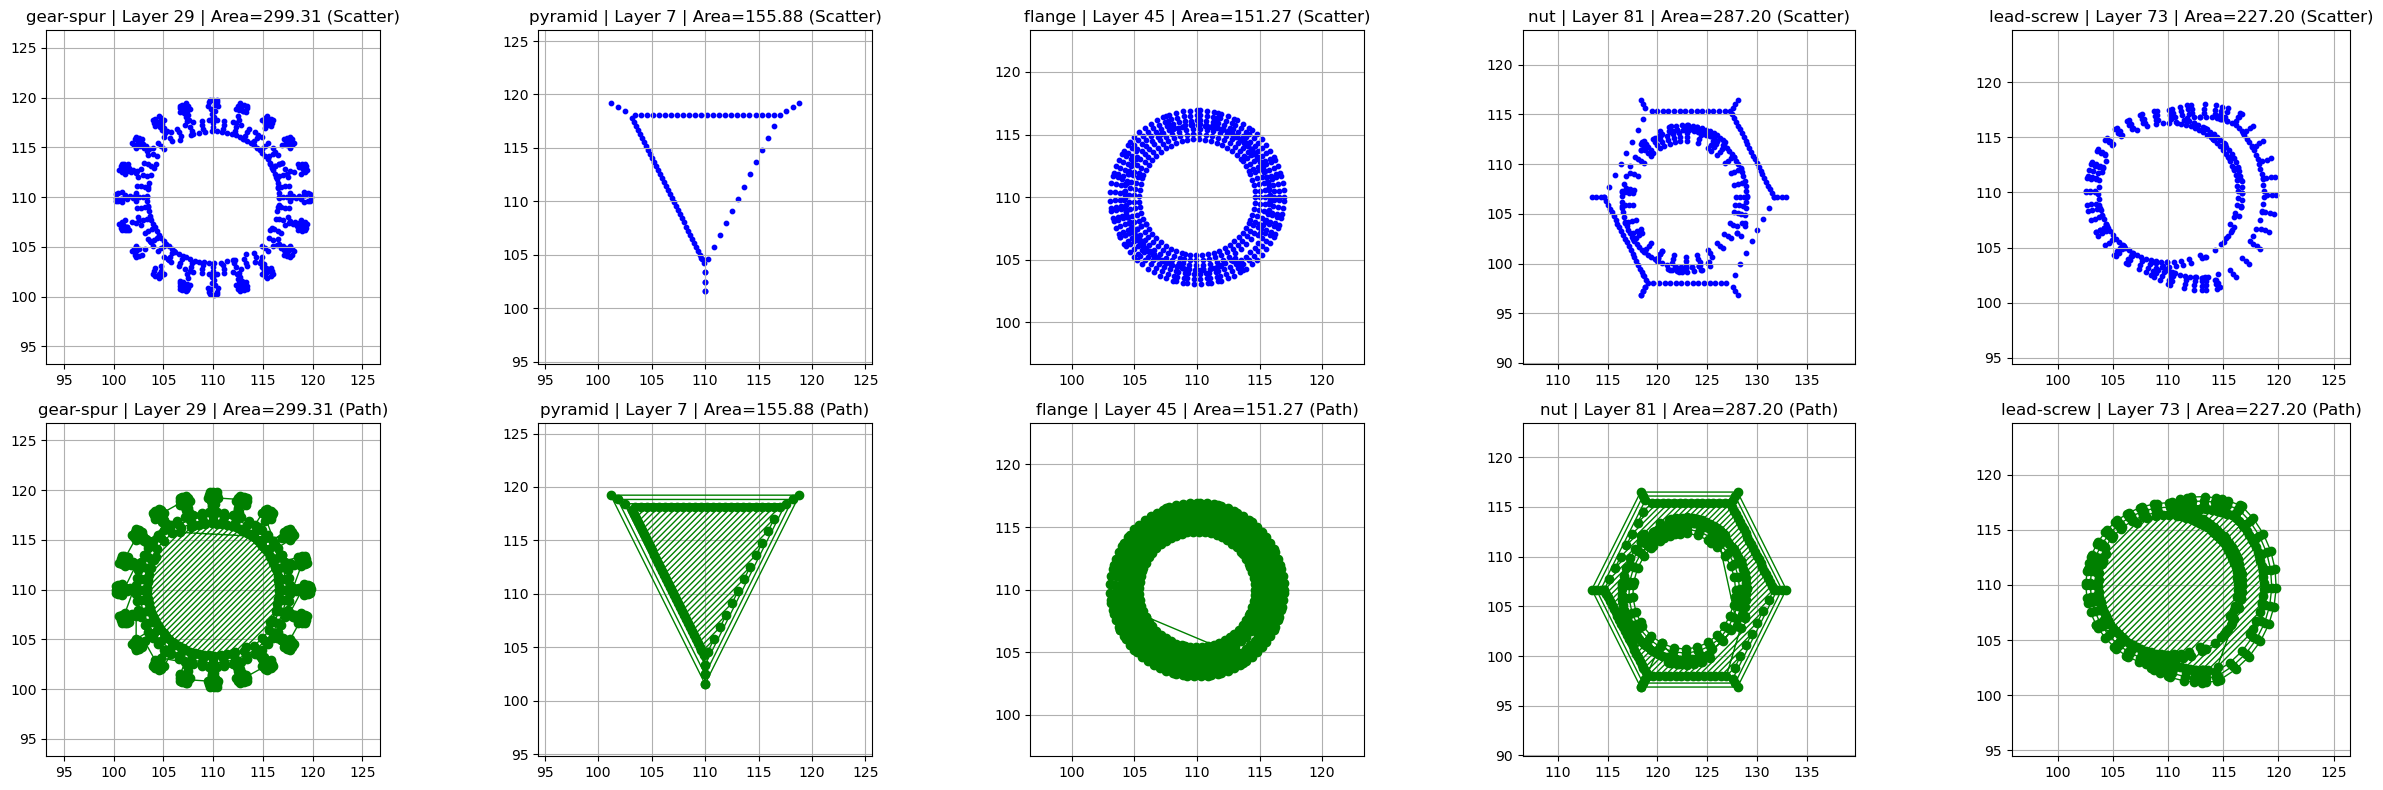

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random

# === Load the new .npy file ===
npy_path = r"C:\Users\matsi\CodePResearch\Testing GAN\Coding of GAN\DataSetV2\gcode_layers_V3.npy"
loaded = np.load(npy_path, allow_pickle=True).item()

X = loaded["data"]             # [num_files, max_layers, max_points, 2]
y = loaded["labels"]           # integer labels
label_map = loaded["label_map"]  # dict {name: int}
layer_indices = loaded["layer_indices"]  # [num_files, max_layers]
areas = loaded["areas"]        # [num_files, max_layers] (raw areas)
name_map = {v: k for k, v in label_map.items()}  # reverse lookup

# === Flatten all layers with their label & layer index ===
samples = []
for i, file in enumerate(X):
    for j, layer in enumerate(file):
        if np.any(layer):   # skip all-zero padding
            samples.append((layer, y[i], layer_indices[i, j], areas[i, j]))  
            # (points, label, layer_num, raw_area)

# === Randomly pick 5 layers ===
selected_layers = random.sample(samples, 5)

# === Plotting horizontally: 2 rows (scatter & line), 5 columns ===
fig, axs = plt.subplots(2, 5, figsize=(25, 8))

for col, (layer, label, layer_num, raw_area) in enumerate(selected_layers):
    # Remove zero-padded rows
    points = layer[~np.all(layer == 0, axis=1)]

    # Auto margins
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    x_margin = (x_max - x_min) * 0.1 + 5
    y_margin = (y_max - y_min) * 0.1 + 5

    # === Top Row: Scatter ===
    axs[0, col].scatter(points[:, 0], points[:, 1], s=10, color='blue')
    axs[0, col].set_title(f"{name_map[label]} | Layer {layer_num} | Area={raw_area:.2f} (Scatter)")
    axs[0, col].set_aspect('equal')
    axs[0, col].grid(True)
    axs[0, col].set_xlim(x_min - x_margin, x_max + x_margin)
    axs[0, col].set_ylim(y_min - y_margin, y_max + y_margin)

    # === Bottom Row: Path (line plot) ===
    axs[1, col].plot(points[:, 0], points[:, 1], marker='o', linewidth=1, color='green')
    axs[1, col].set_title(f"{name_map[label]} | Layer {layer_num} | Area={raw_area:.2f} (Path)")
    axs[1, col].set_aspect('equal')
    axs[1, col].grid(True)
    axs[1, col].set_xlim(x_min - x_margin, x_max + x_margin)
    axs[1, col].set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()


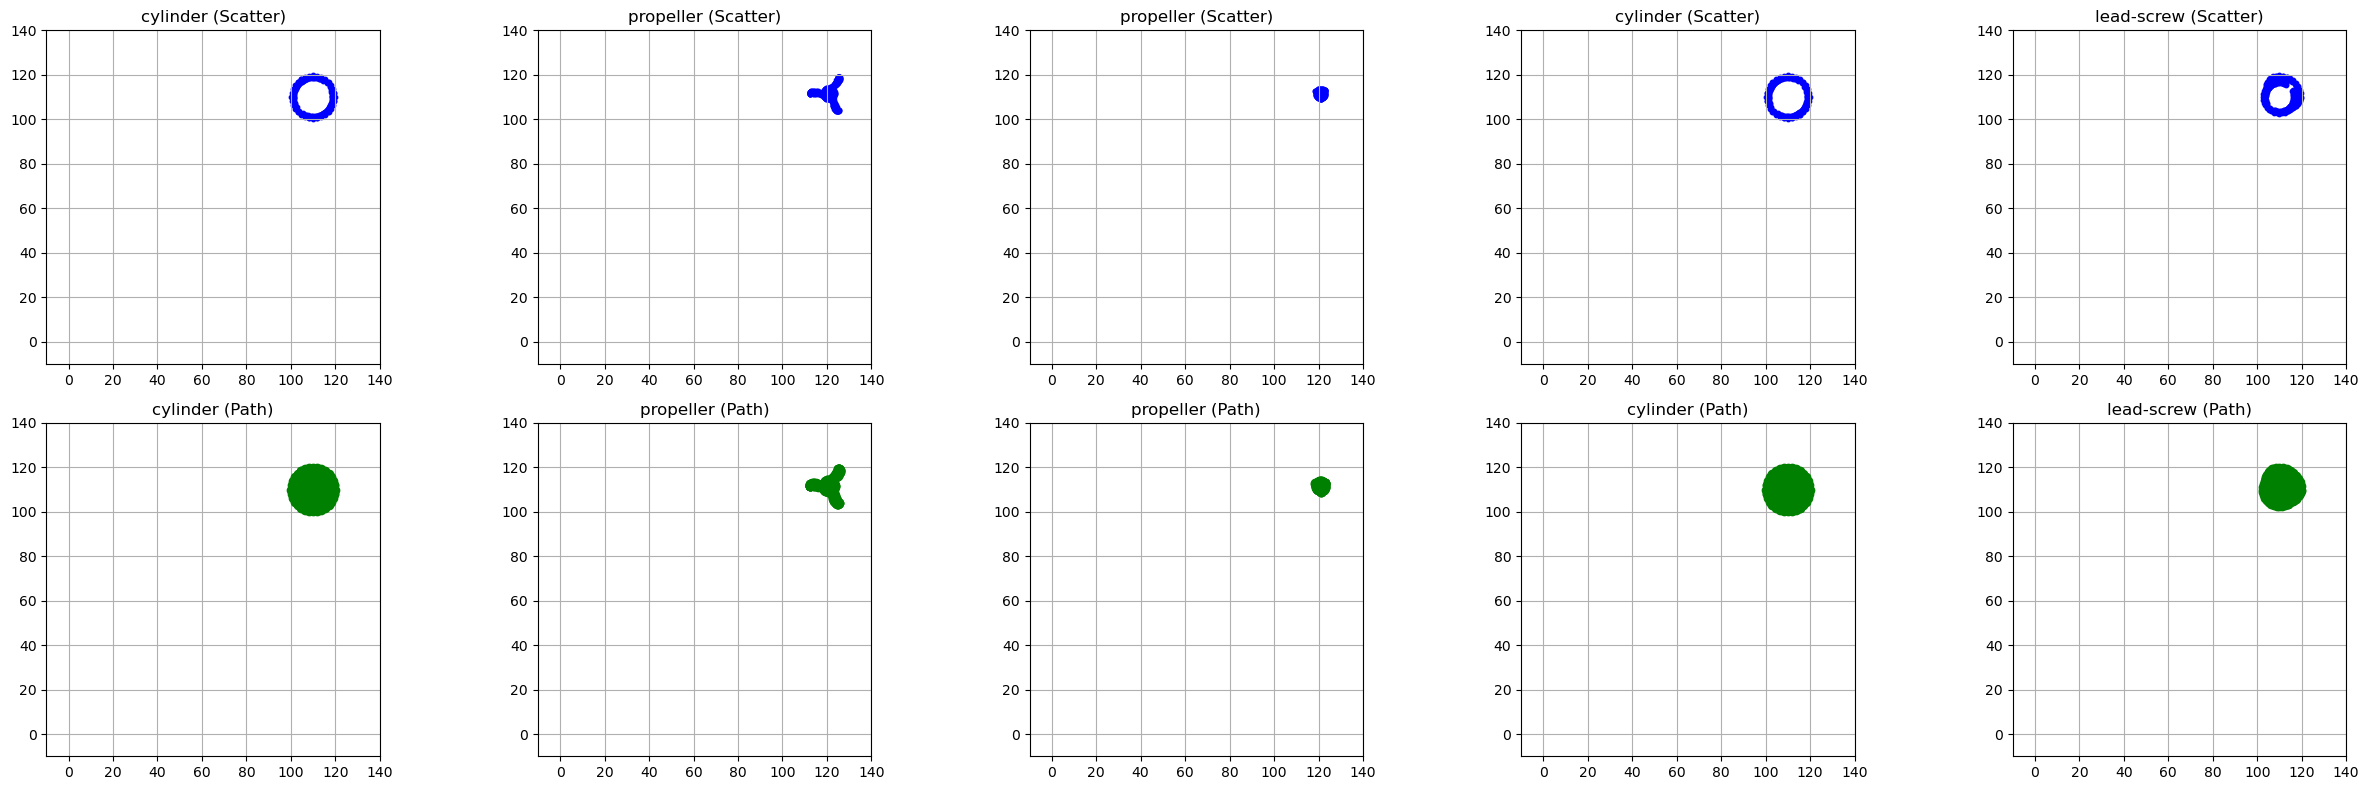

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random

# === Load the new dataset (dictionary) ===
npy_path = r"C:\Users\matsi\CodePResearch\Testing GAN\Coding of GAN\DataSetV2\gcode_layers_V3.npy"
loaded = np.load(npy_path, allow_pickle=True).item()

X = loaded["data"]        # [num_files, max_layers, max_points, 2]
y = loaded["labels"]      # integer labels
label_map = loaded["label_map"]
name_map = {v: k for k, v in label_map.items()}  # reverse dict: int → name

# === Flatten all layers into a list with labels ===
samples = []
for i, file in enumerate(X):
    for layer in file:
        if np.any(layer):  # skip empty (zero-padded) layers
            samples.append((layer, y[i]))

# === Randomly pick 5 layers ===
selected_layers = random.sample(samples, 5)

# === Plotting horizontally: 2 rows (scatter & line), 5 columns ===
fig, axs = plt.subplots(2, 5, figsize=(25, 8))

for col, (layer, label) in enumerate(selected_layers):
    # Remove zero padding
    points = layer[~np.all(layer == 0, axis=1)]

    # === Top Row: Scatter plot ===
    axs[0, col].scatter(points[:, 0], points[:, 1], s=10, color='blue')
    axs[0, col].set_title(f"{name_map[label]} (Scatter)")
    axs[0, col].set_xlim(-10, 140)
    axs[0, col].set_ylim(-10, 140)
    axs[0, col].set_aspect('equal')
    axs[0, col].grid(True)

    # === Bottom Row: Path (connected line) ===
    axs[1, col].plot(points[:, 0], points[:, 1], marker='o', linewidth=1, color='green')
    axs[1, col].set_title(f"{name_map[label]} (Path)")
    axs[1, col].set_xlim(-10, 140)
    axs[1, col].set_ylim(-10, 140)
    axs[1, col].set_aspect('equal')
    axs[1, col].grid(True)

plt.tight_layout()
plt.show()


✅ Total valid layers to plot: 987


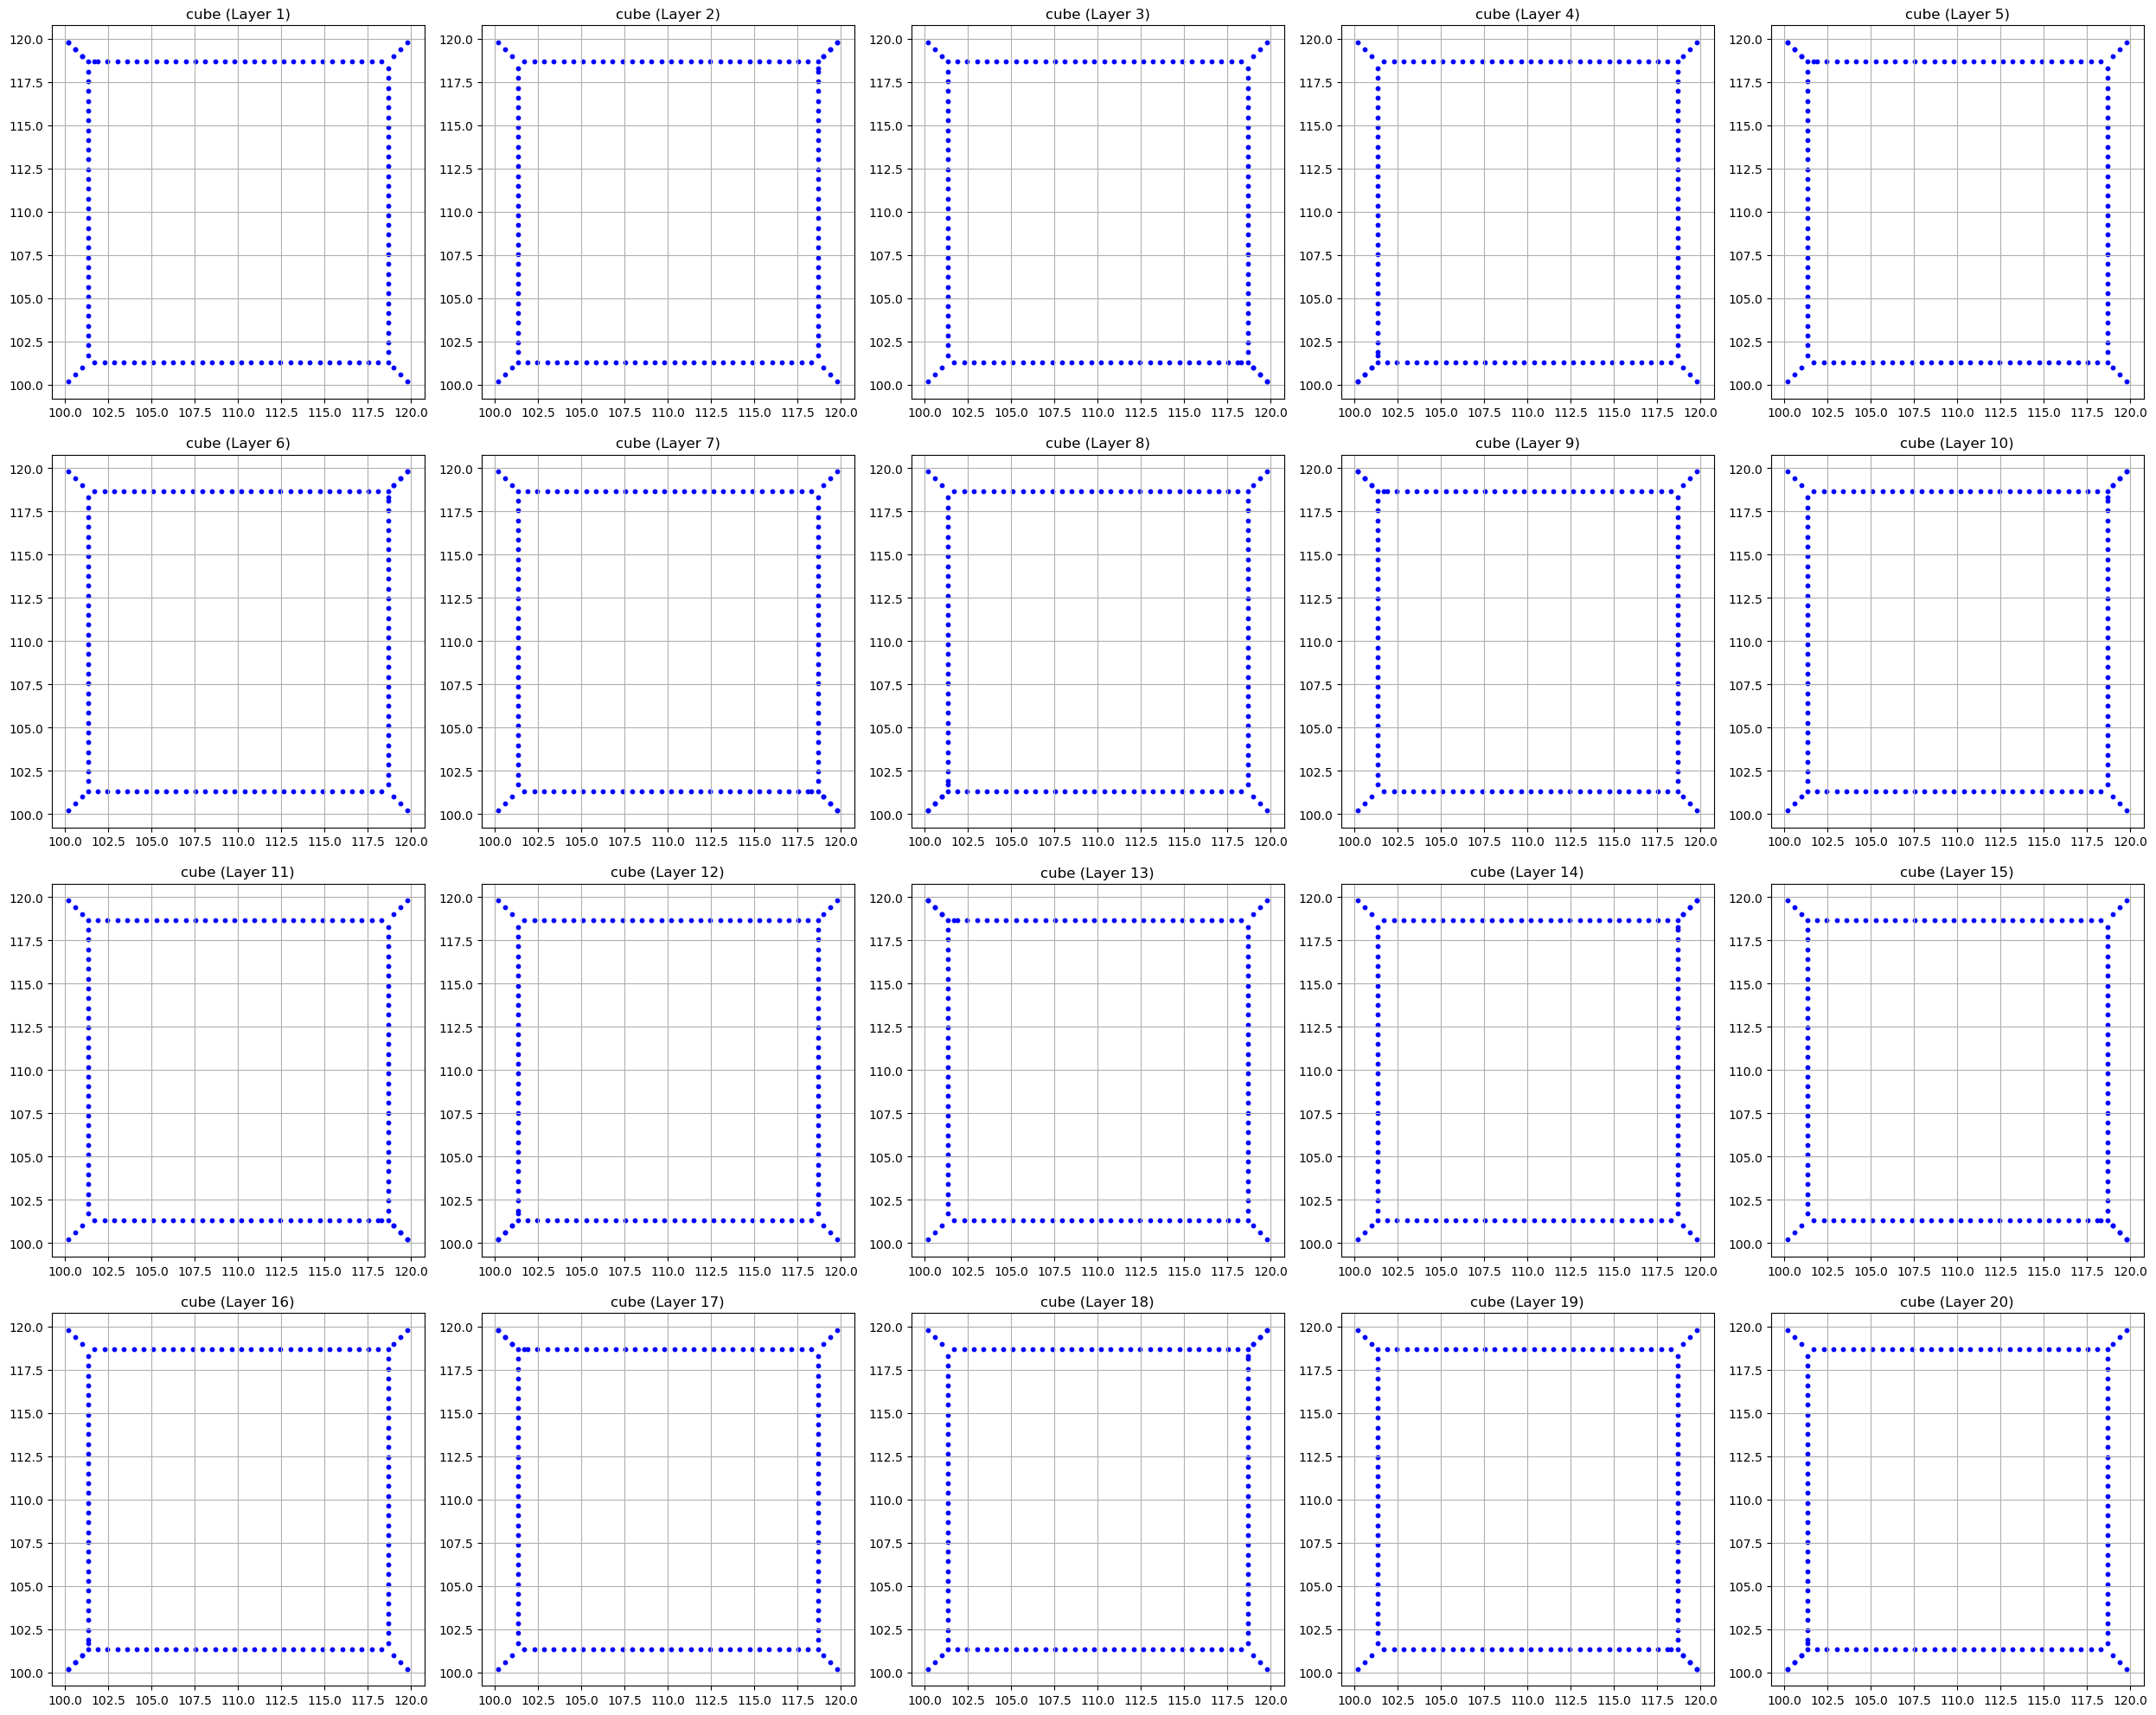

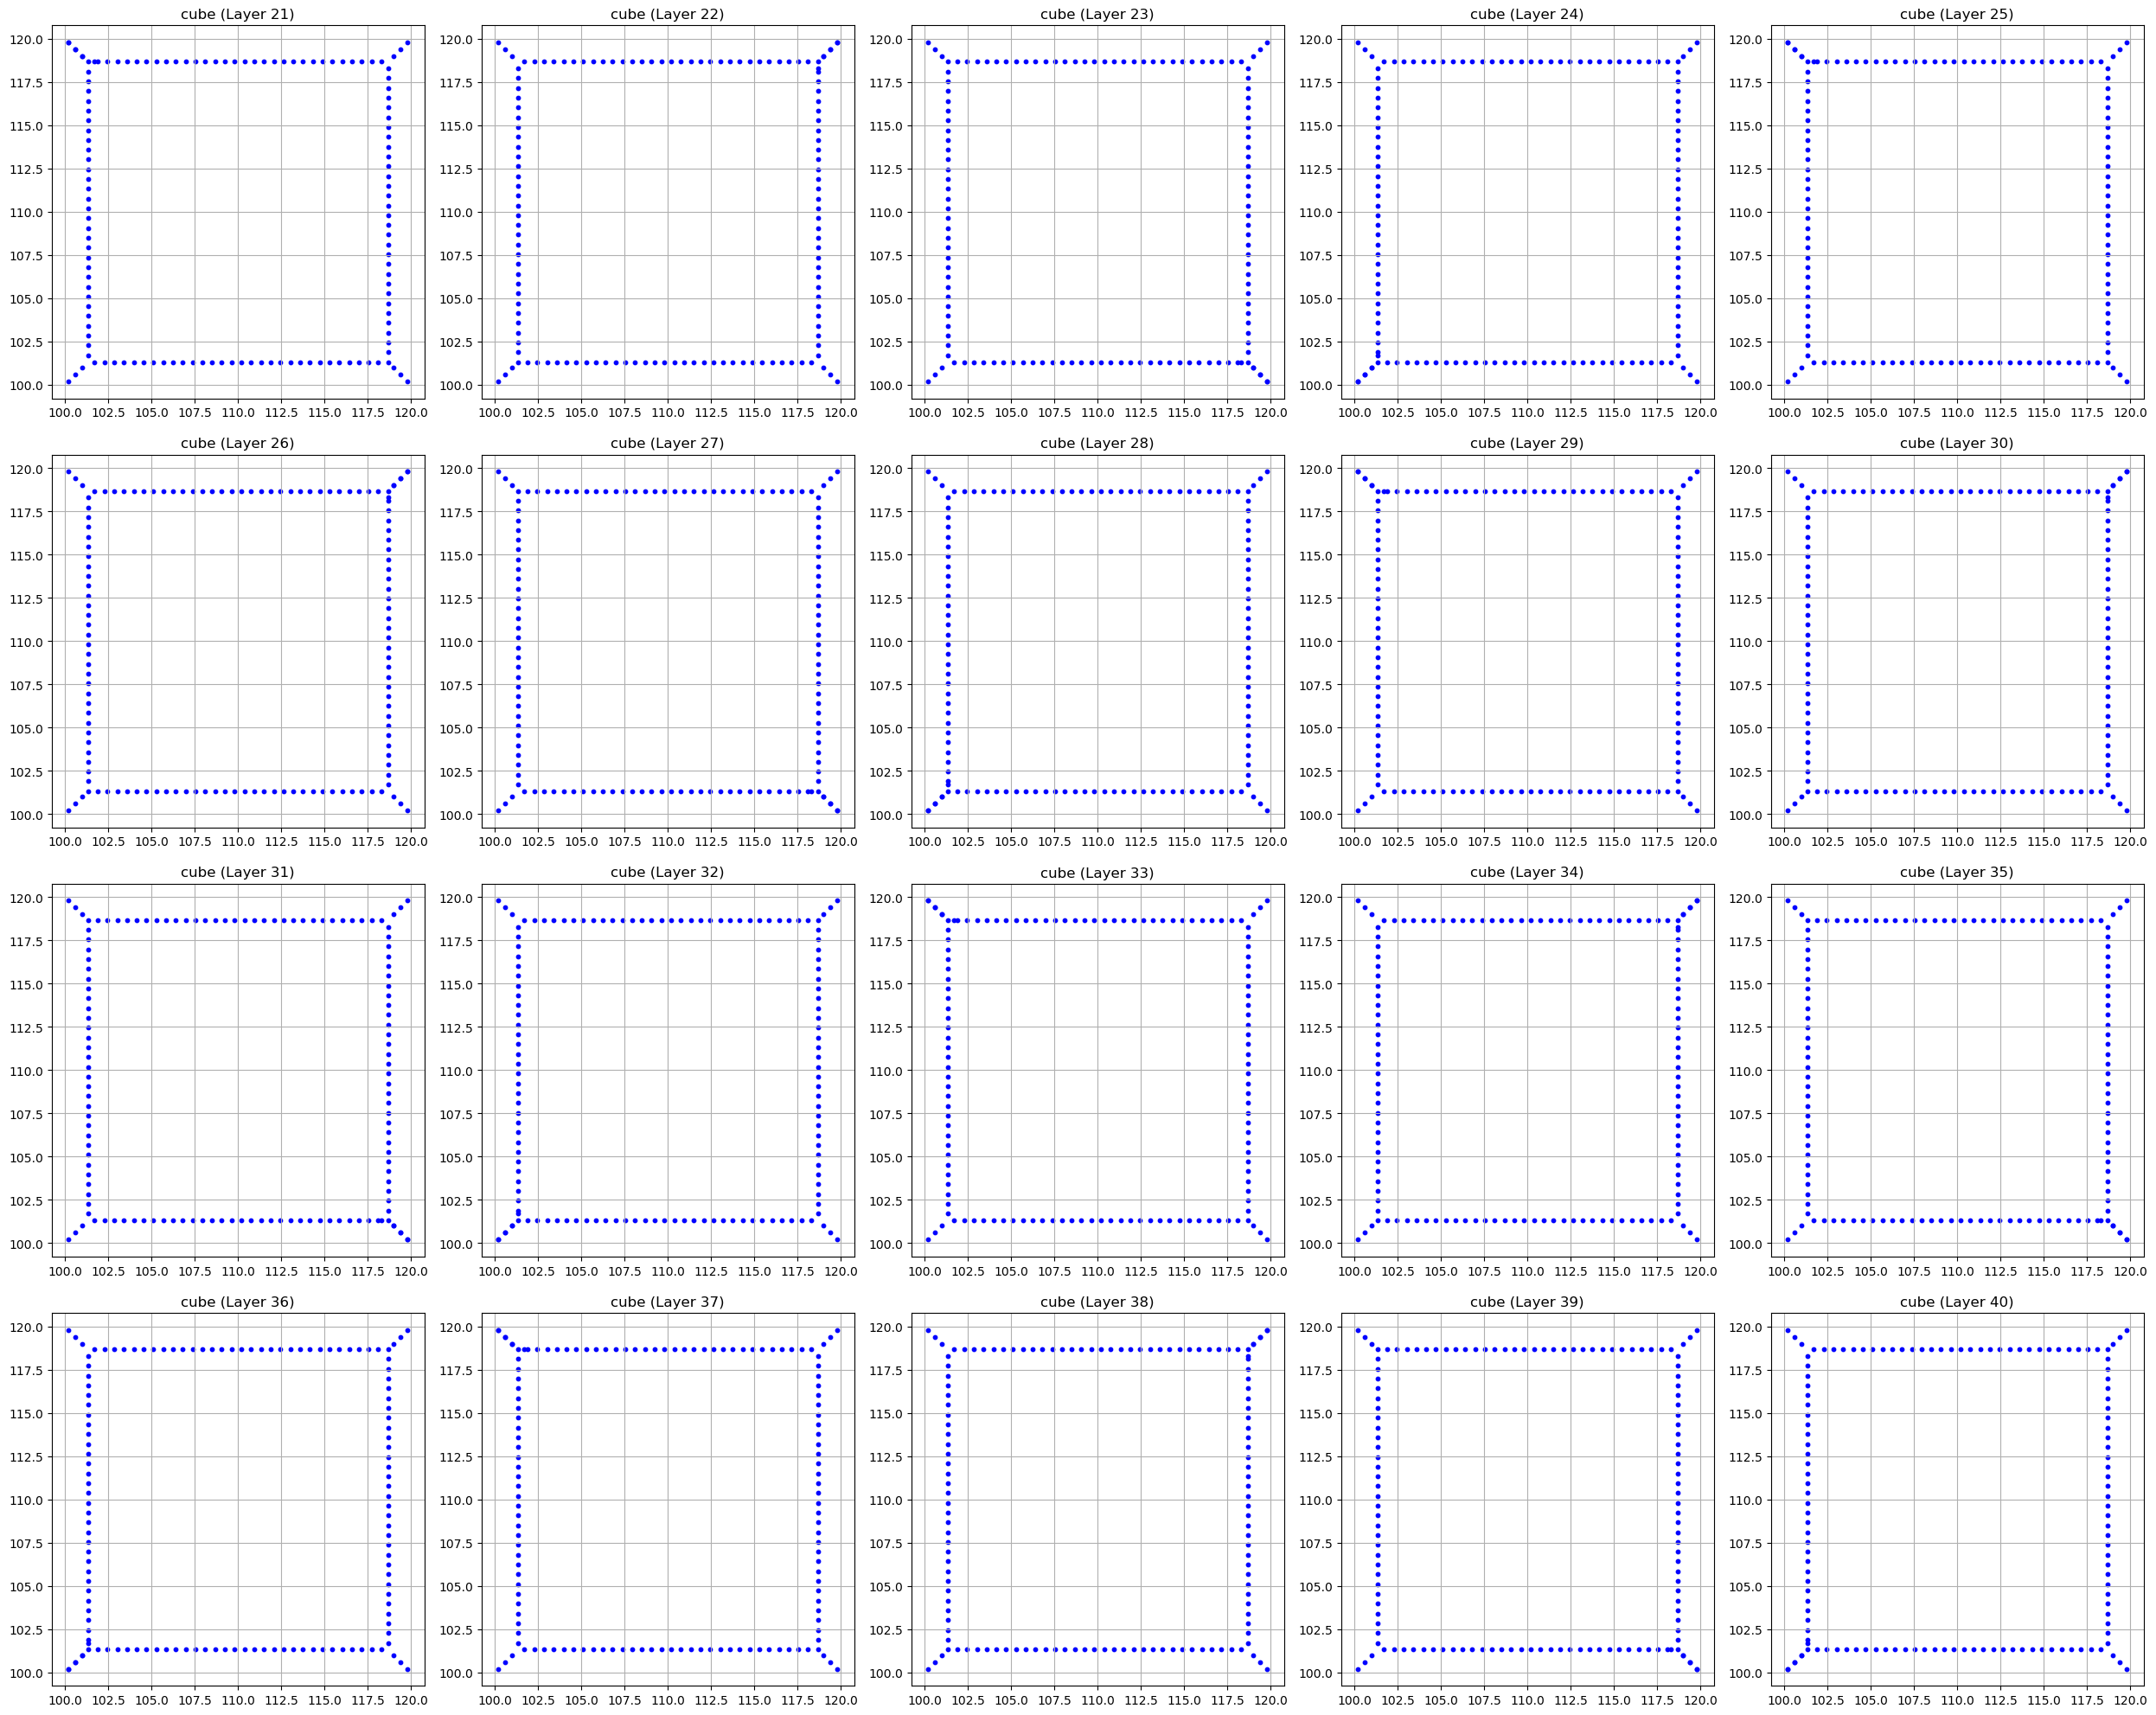

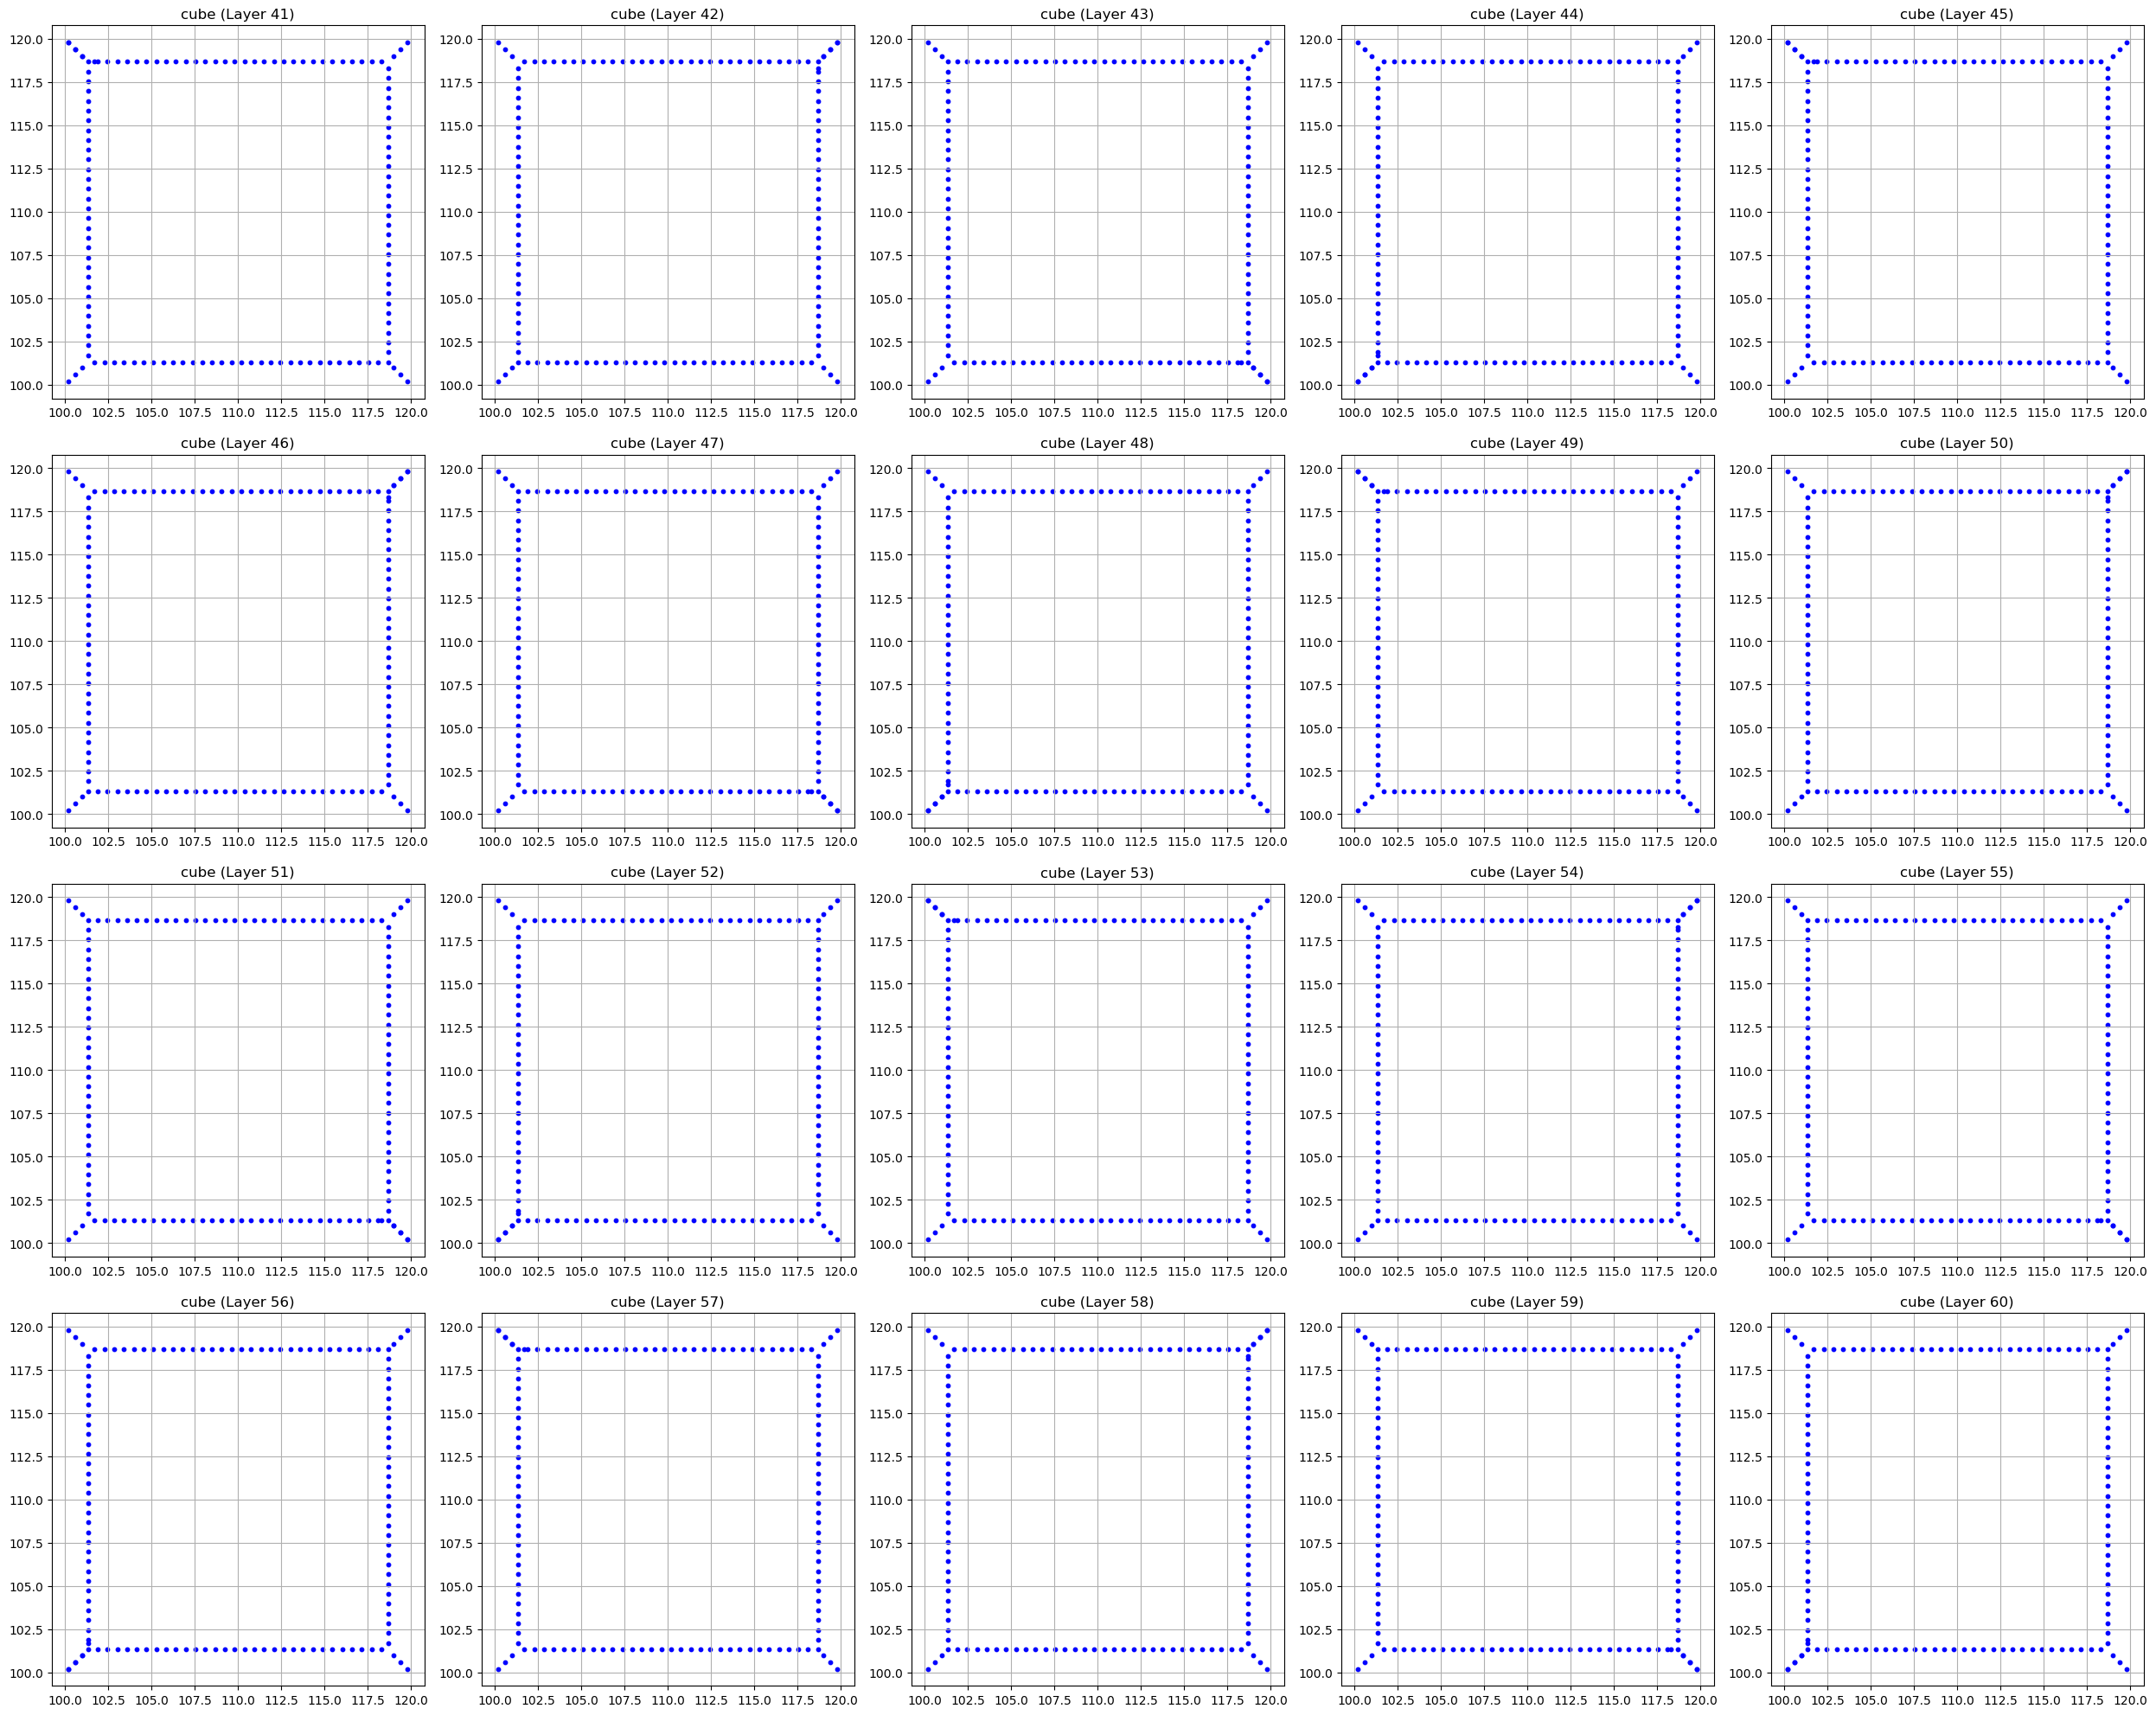

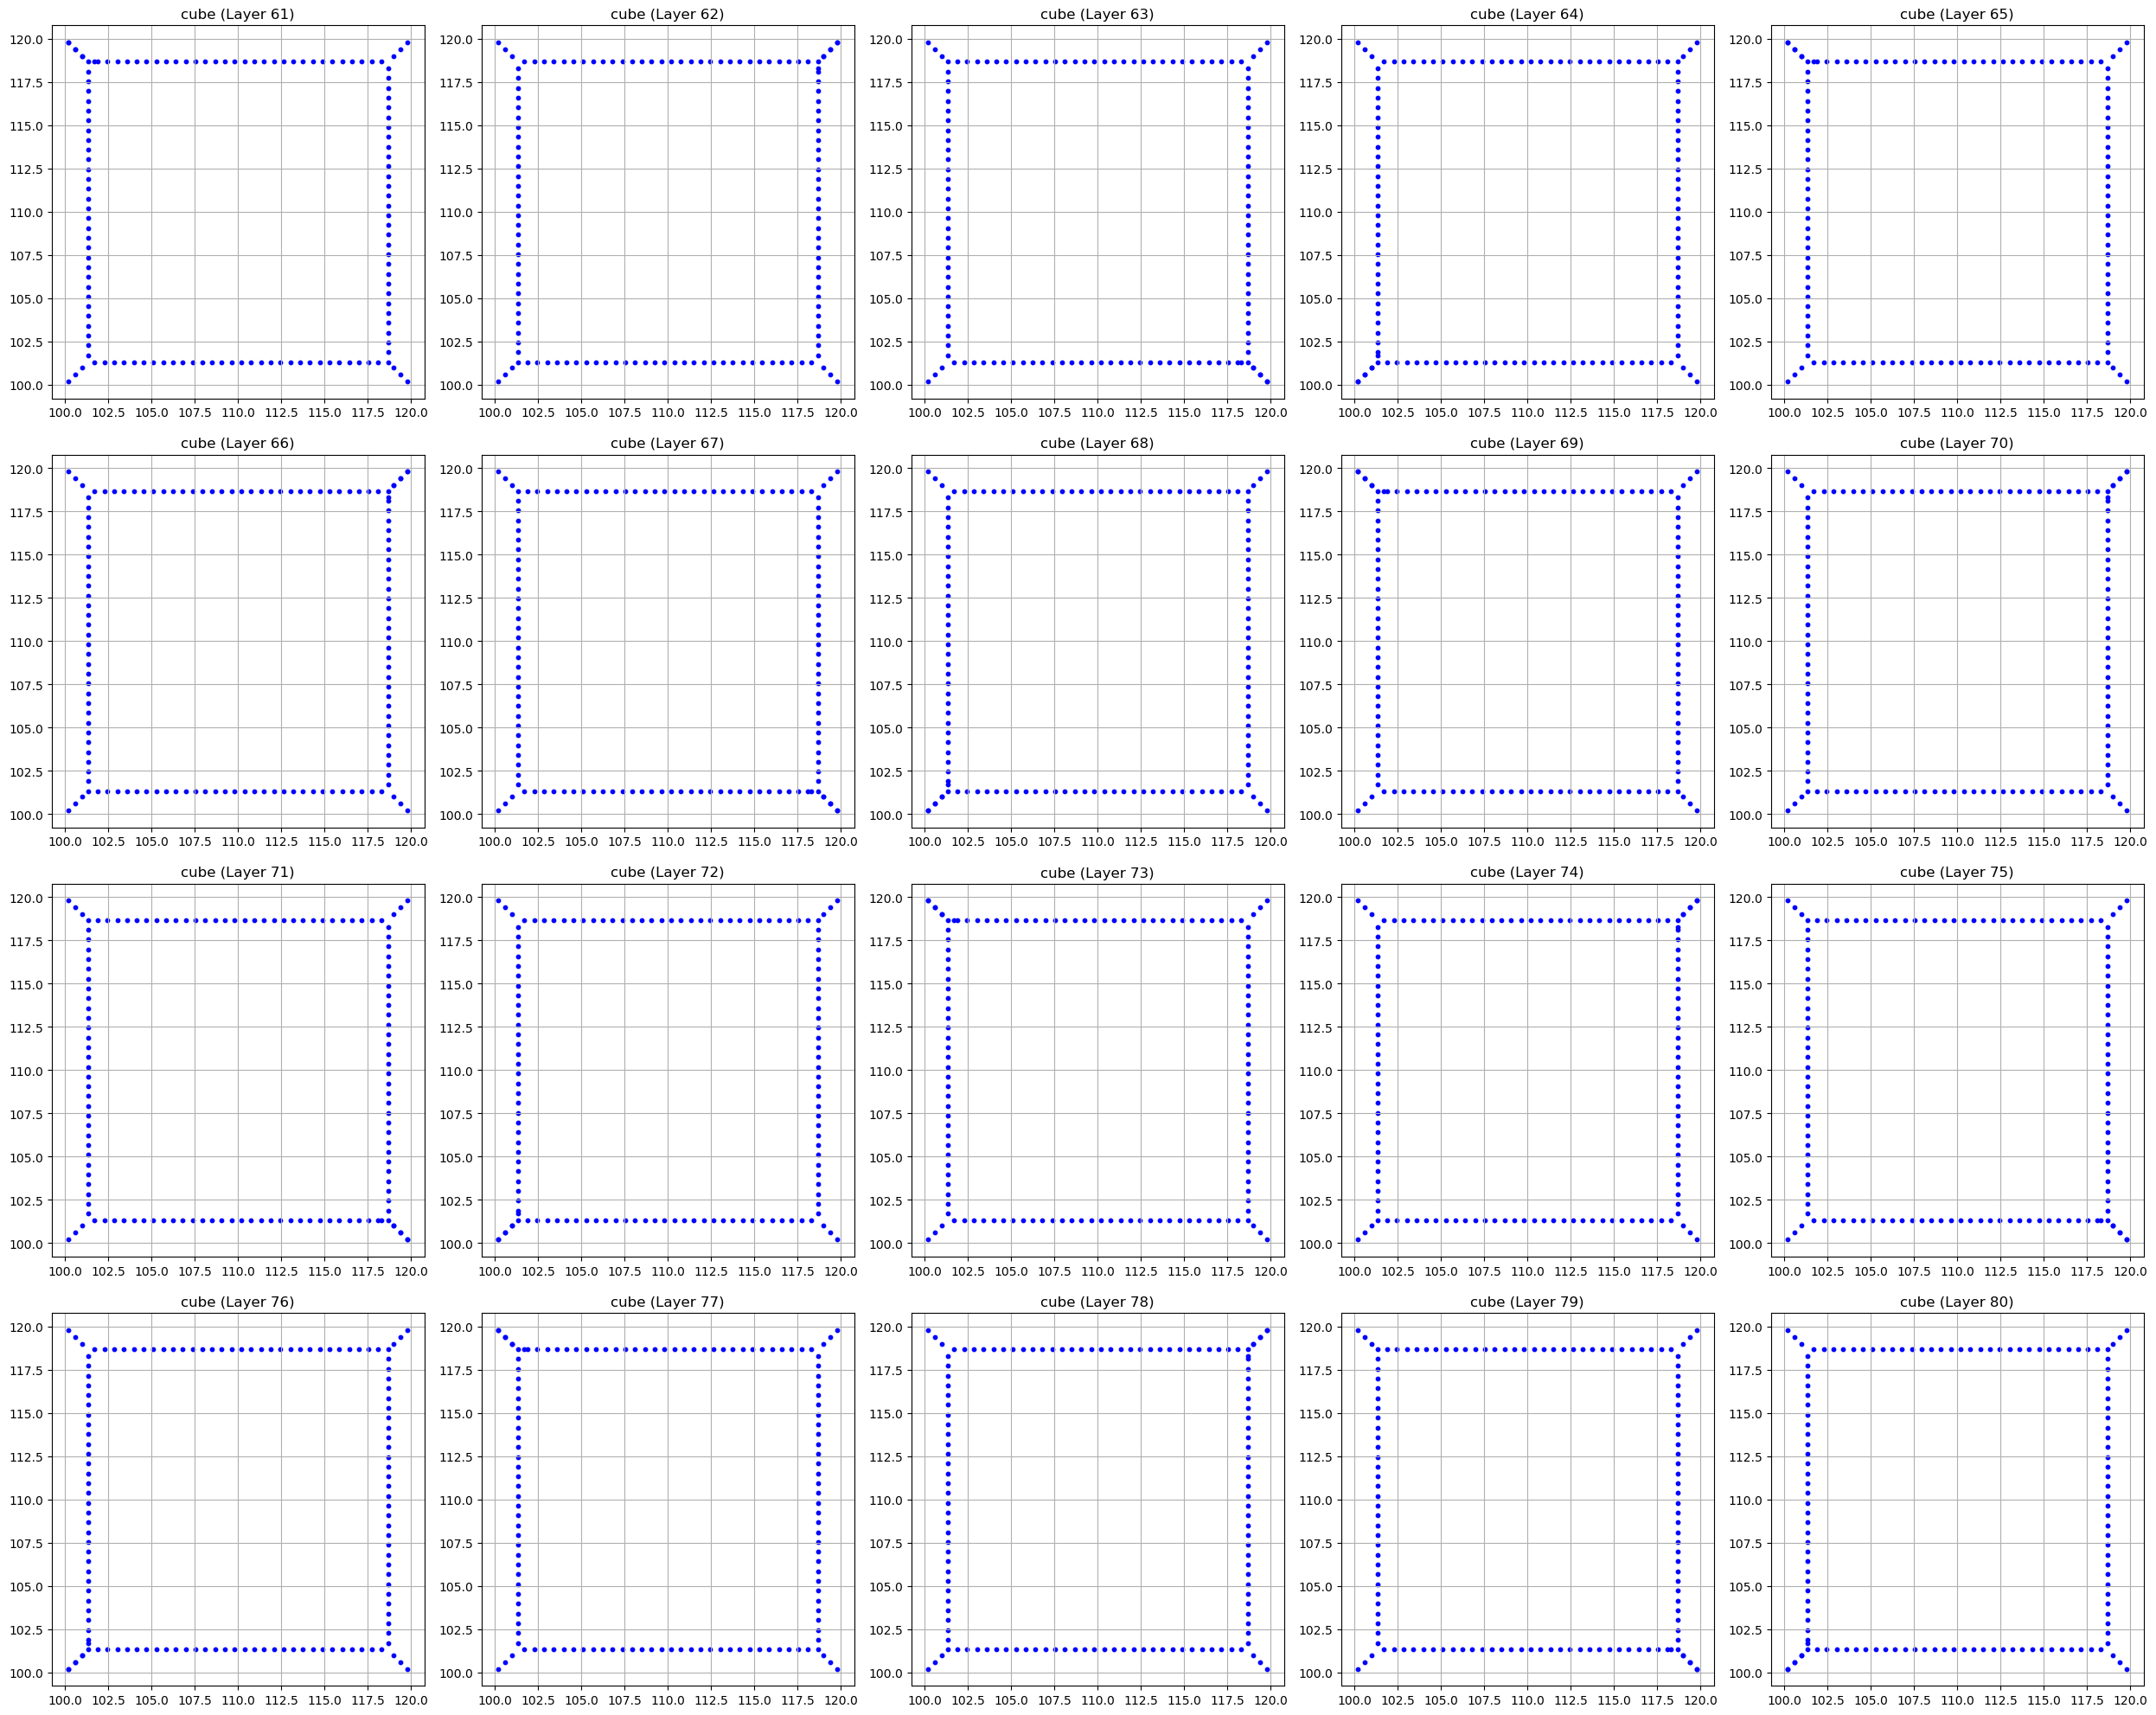

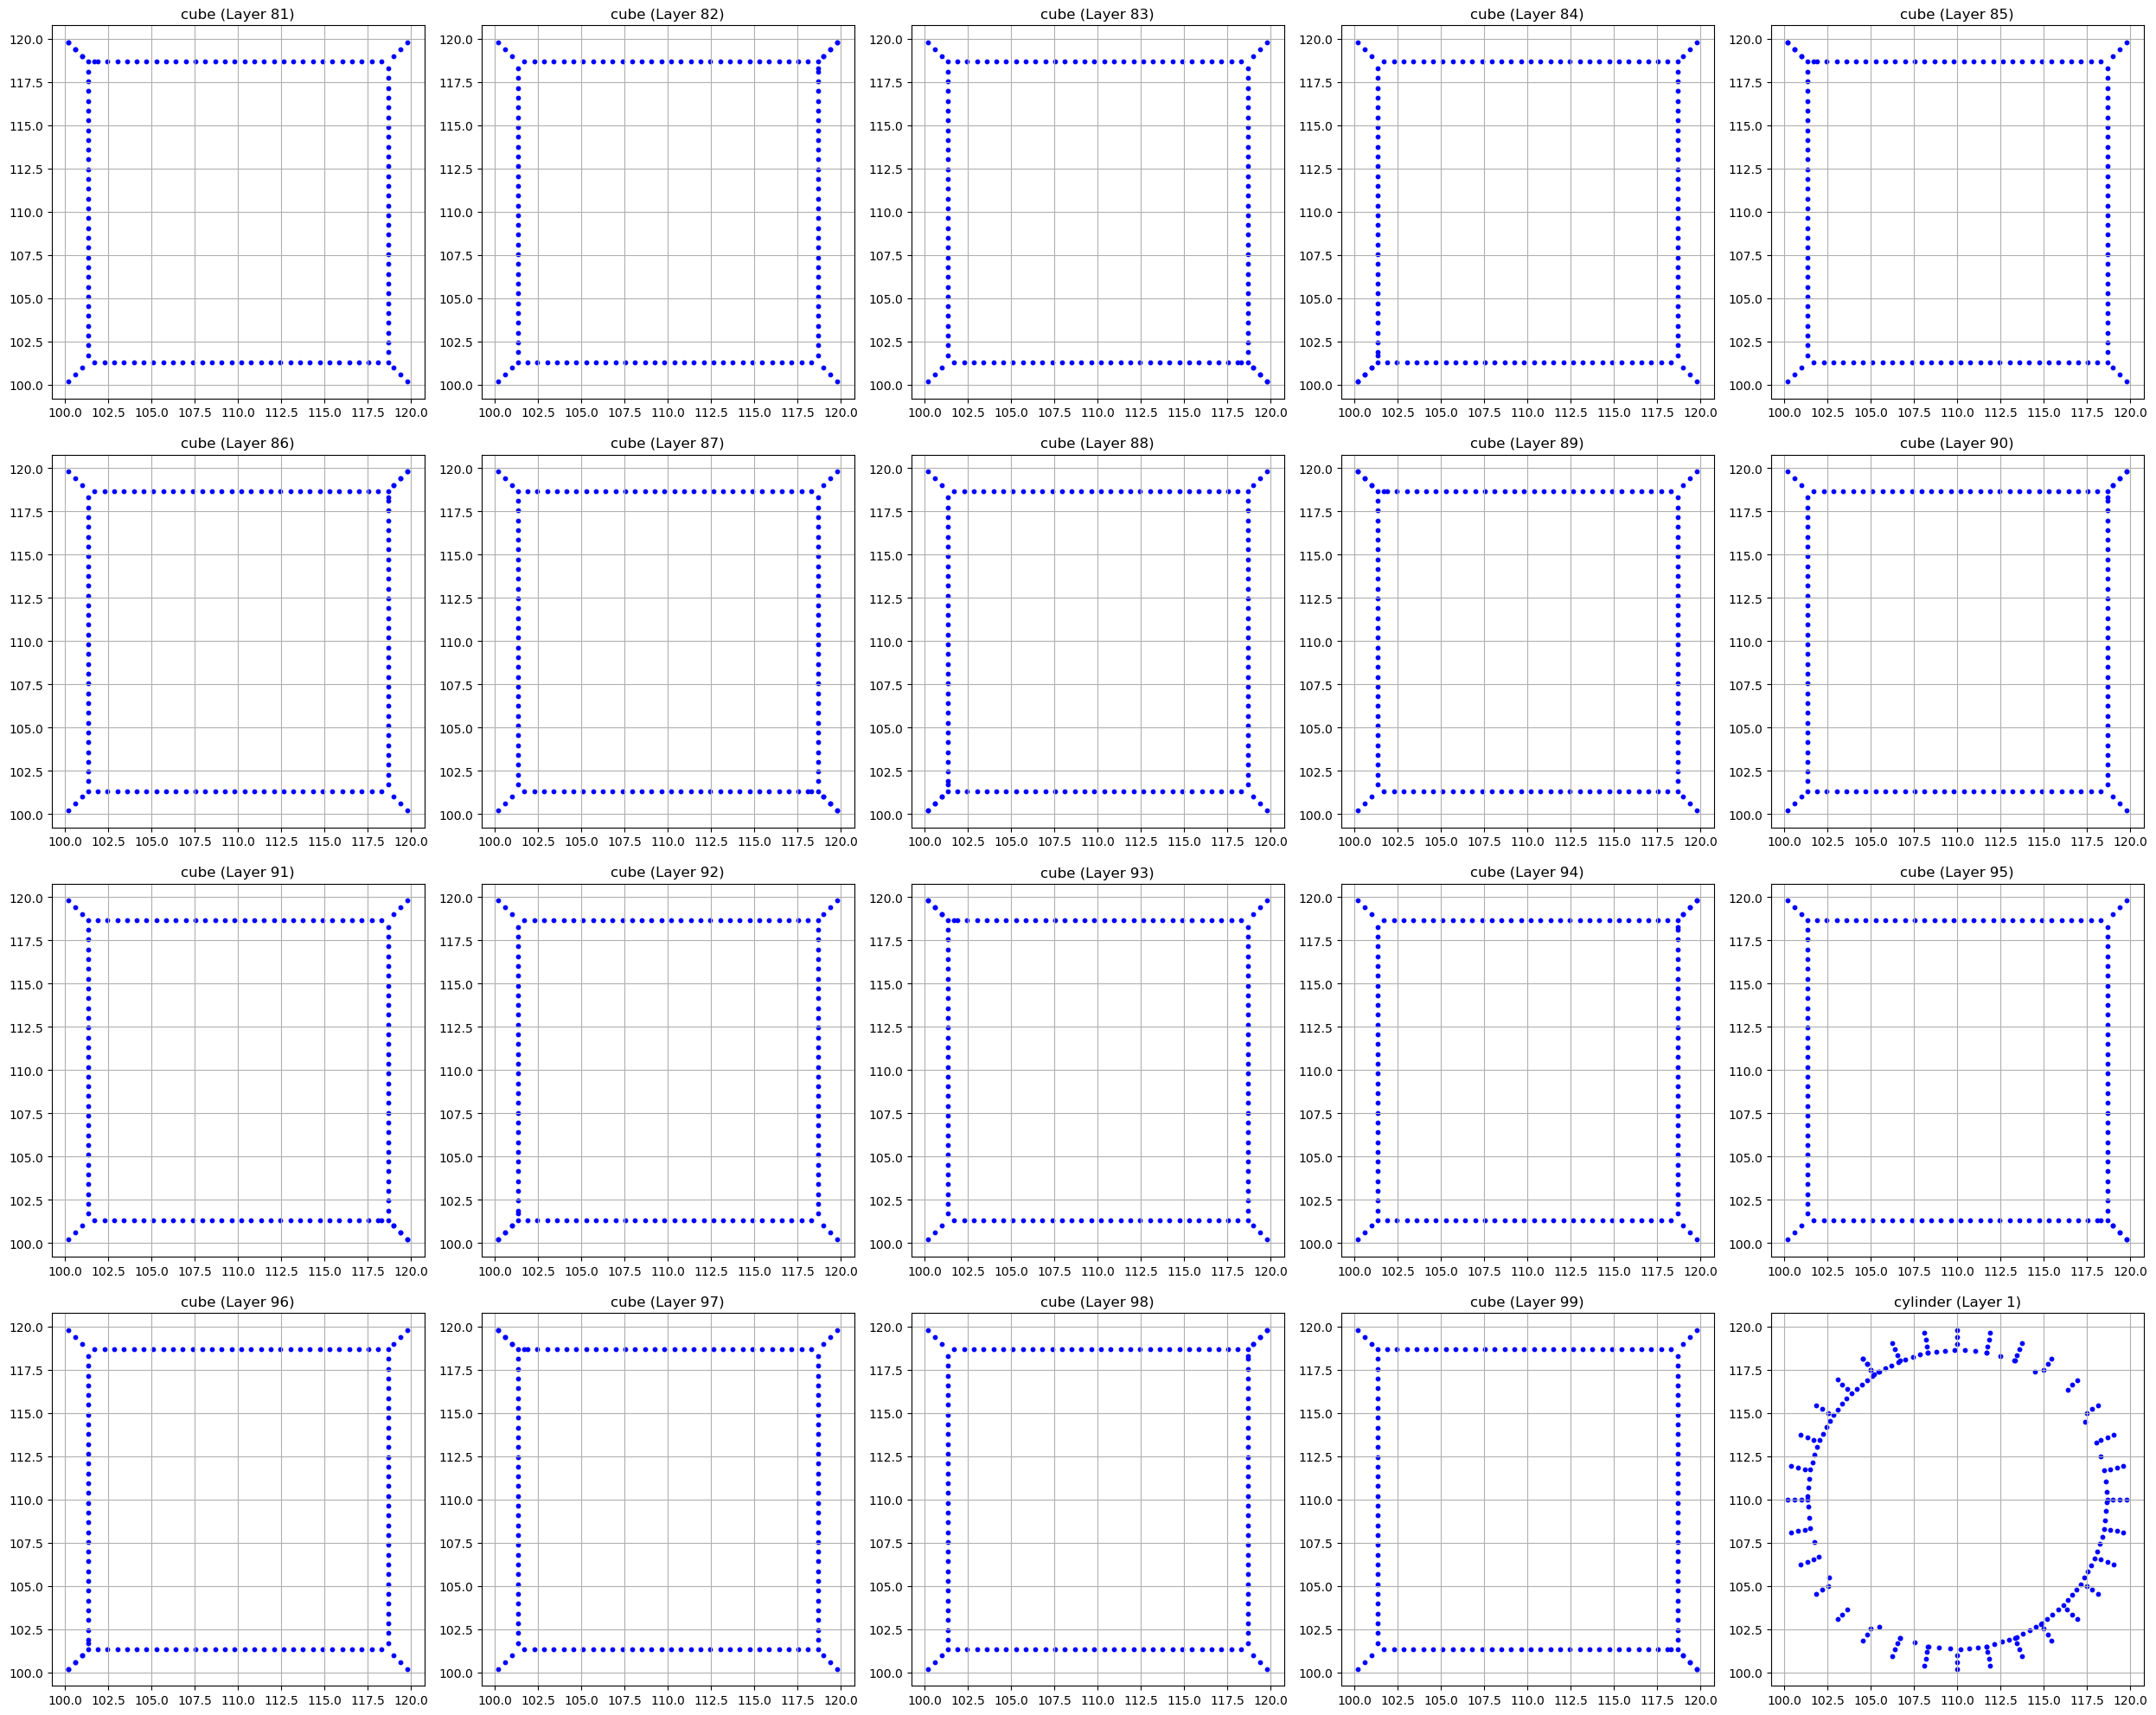

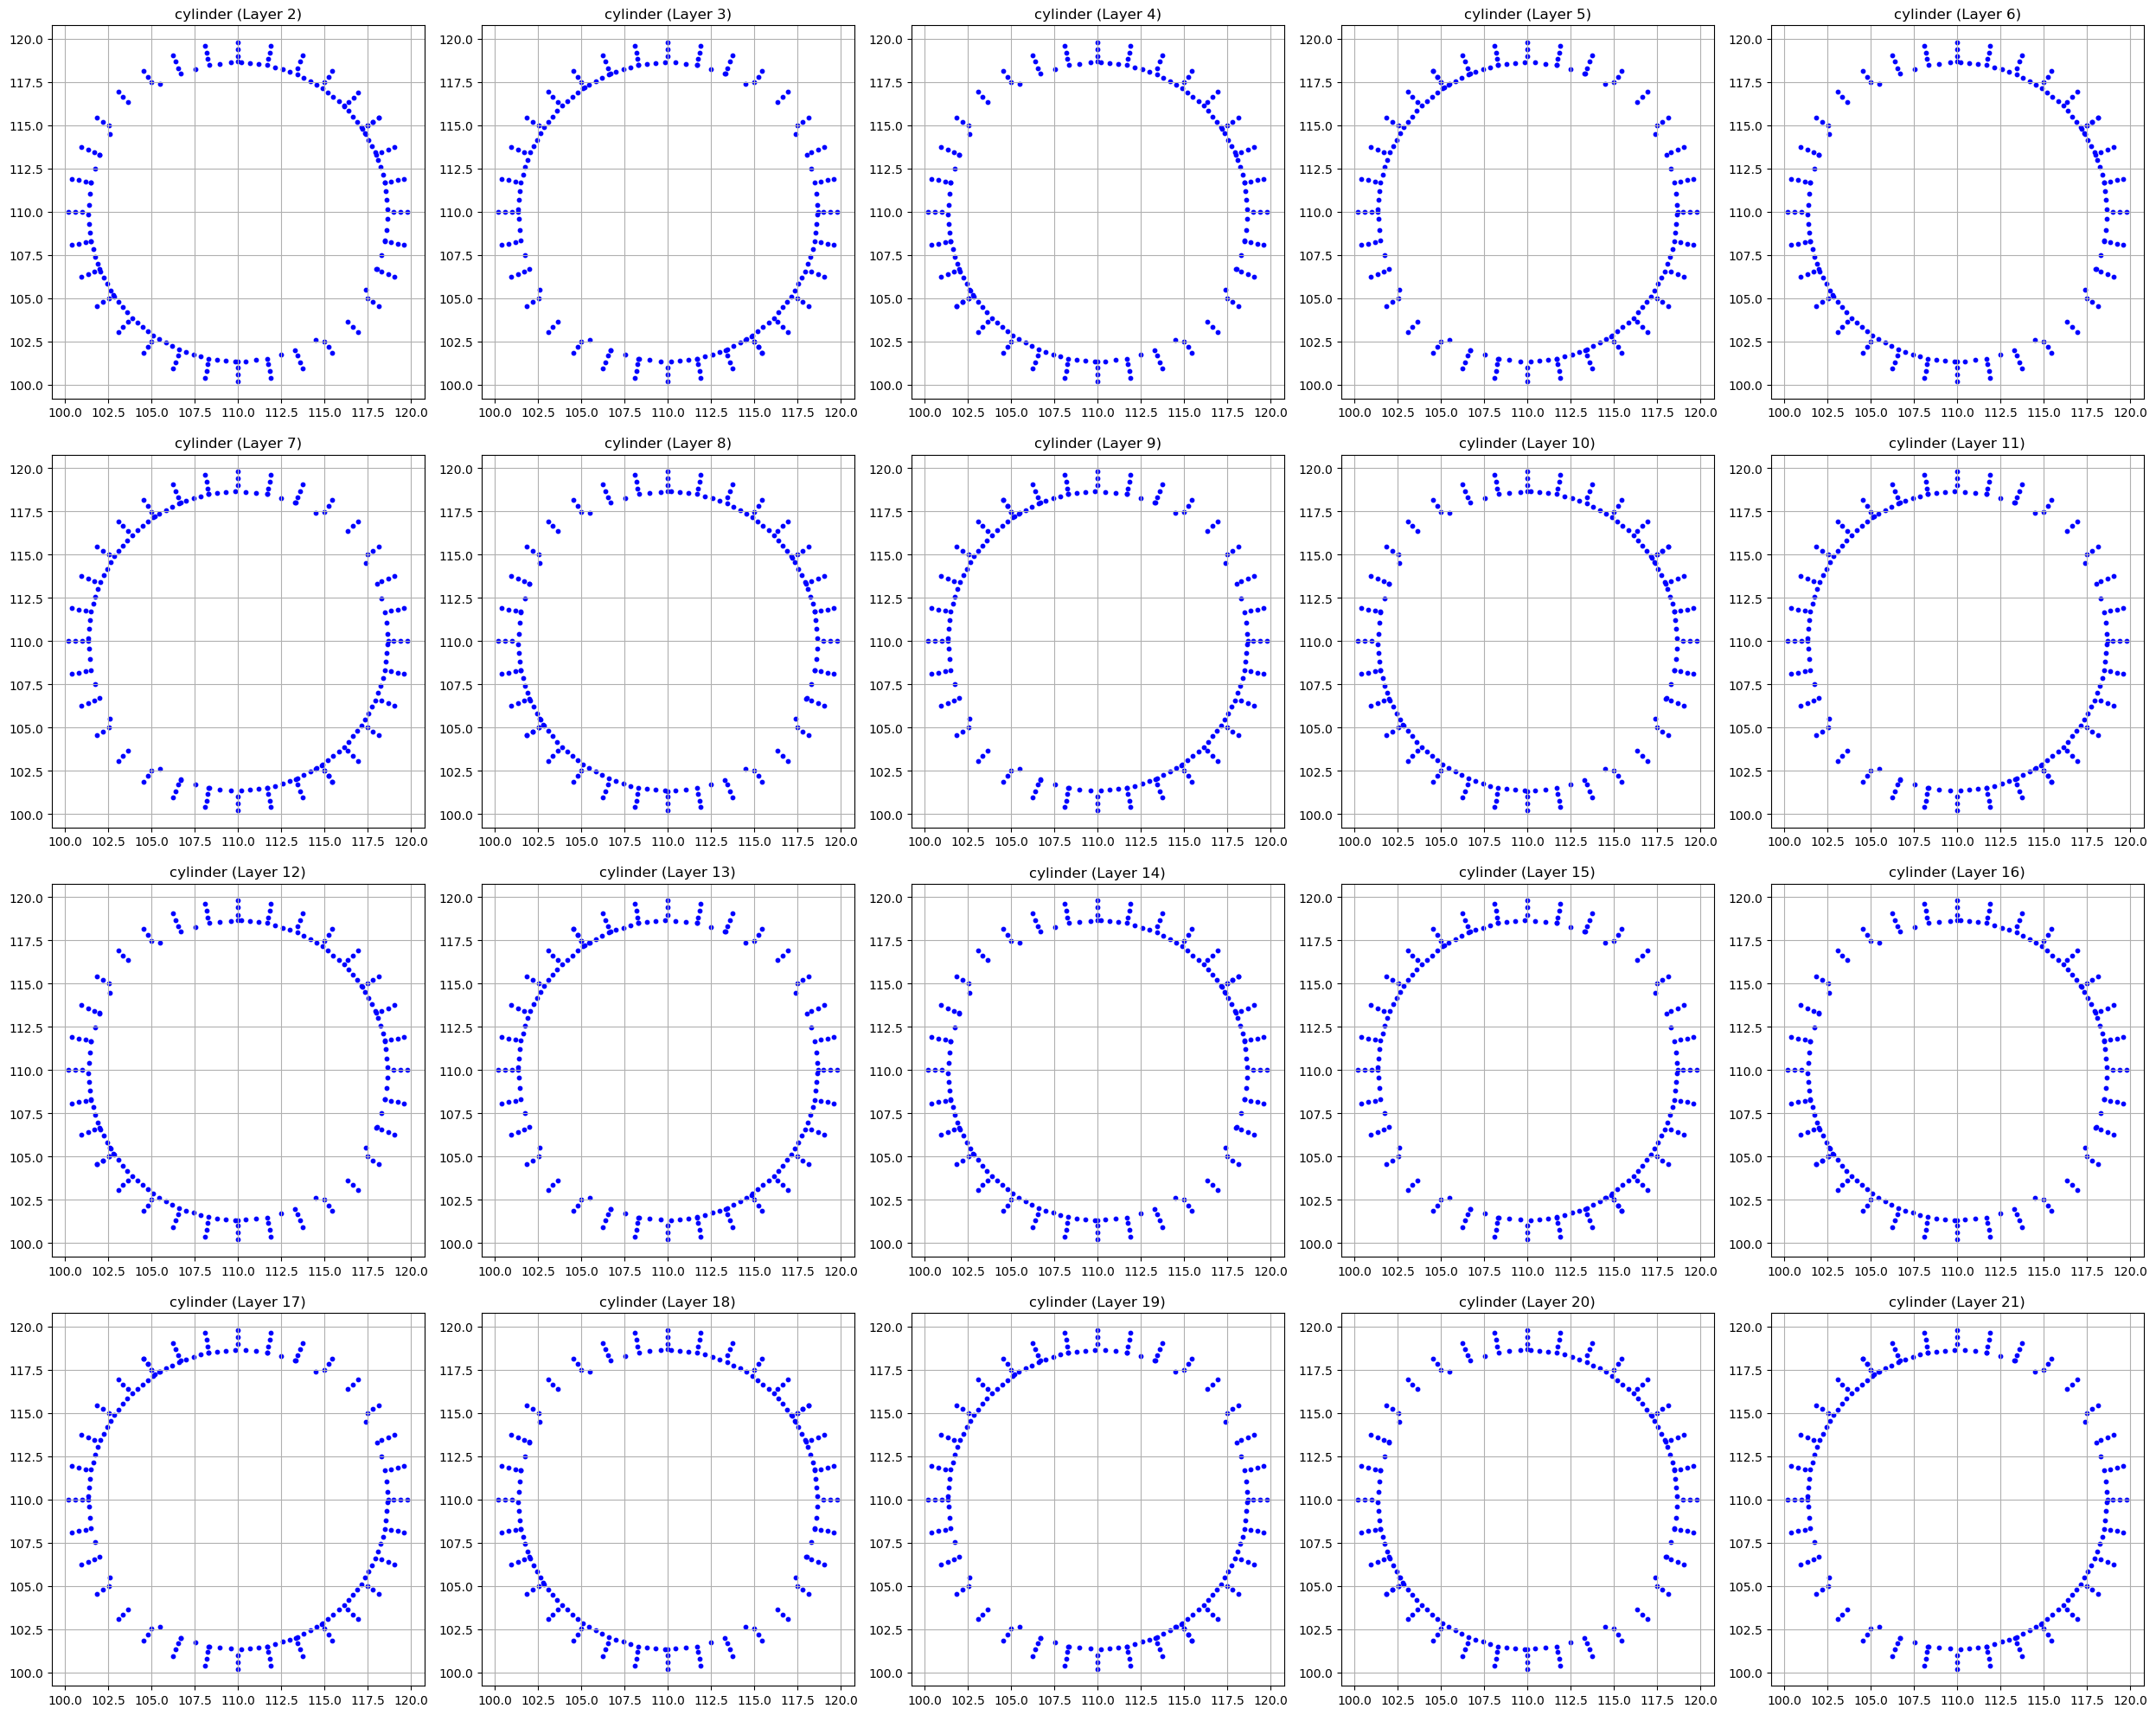

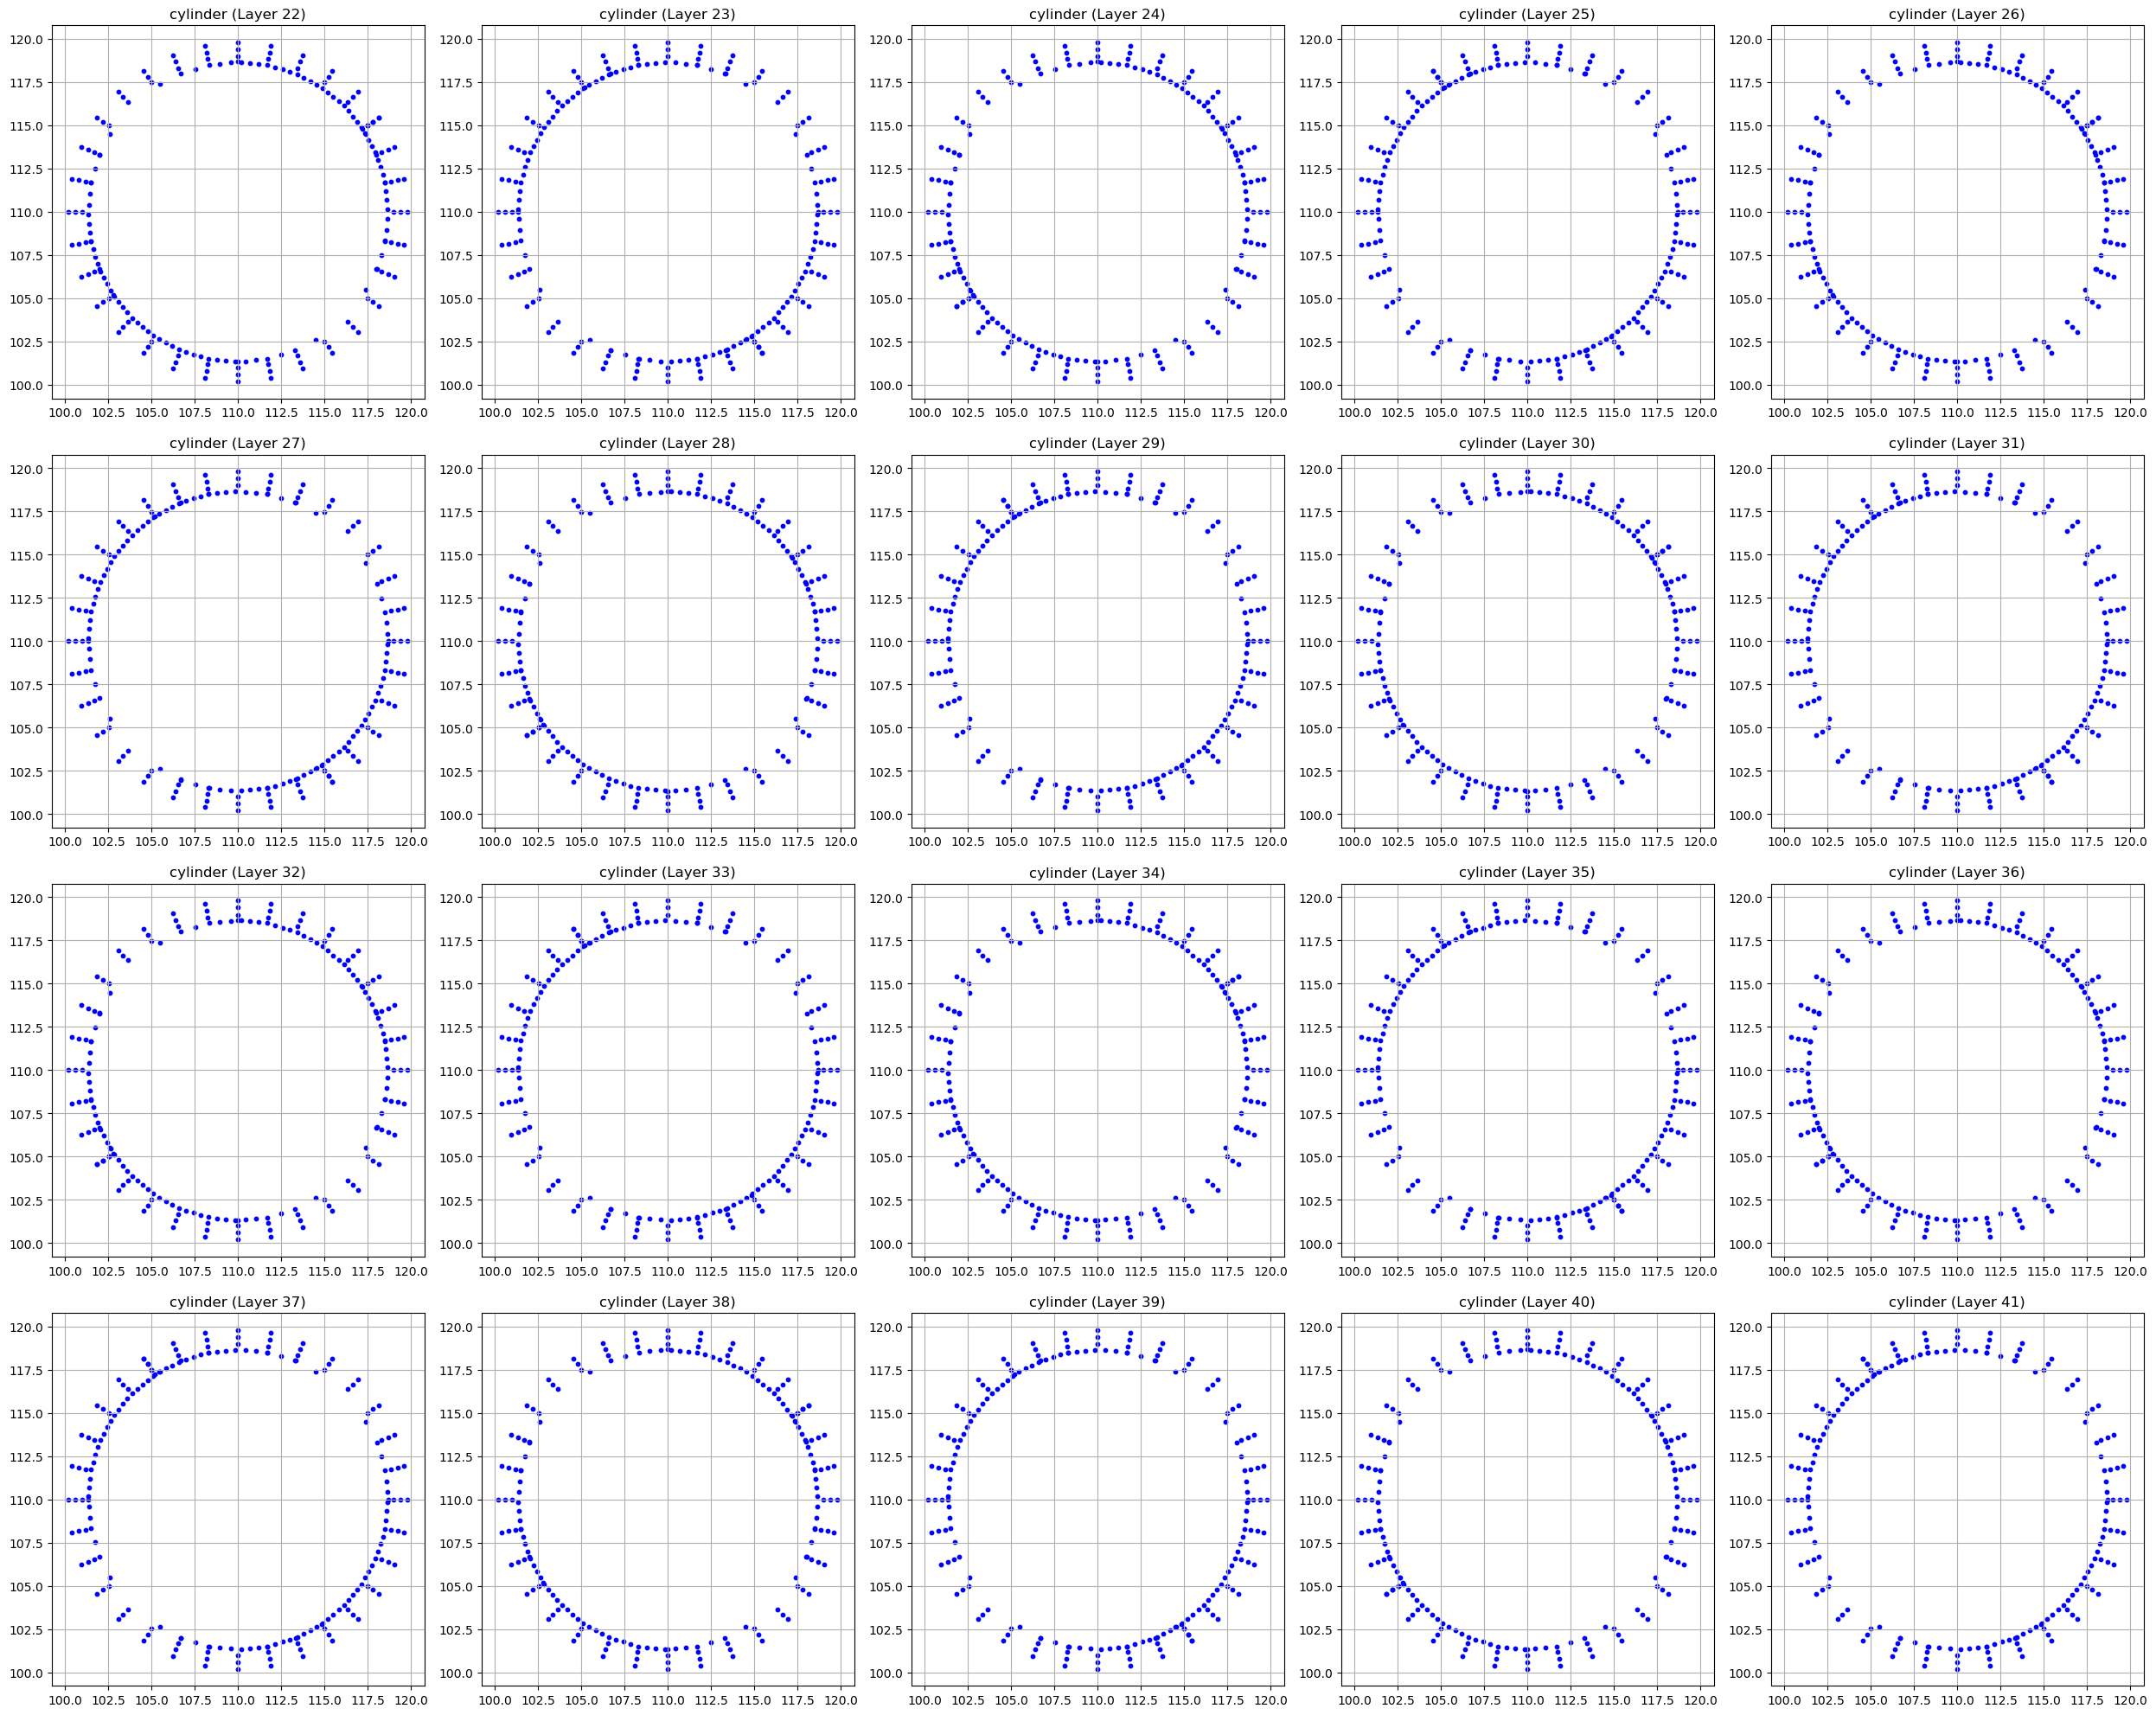

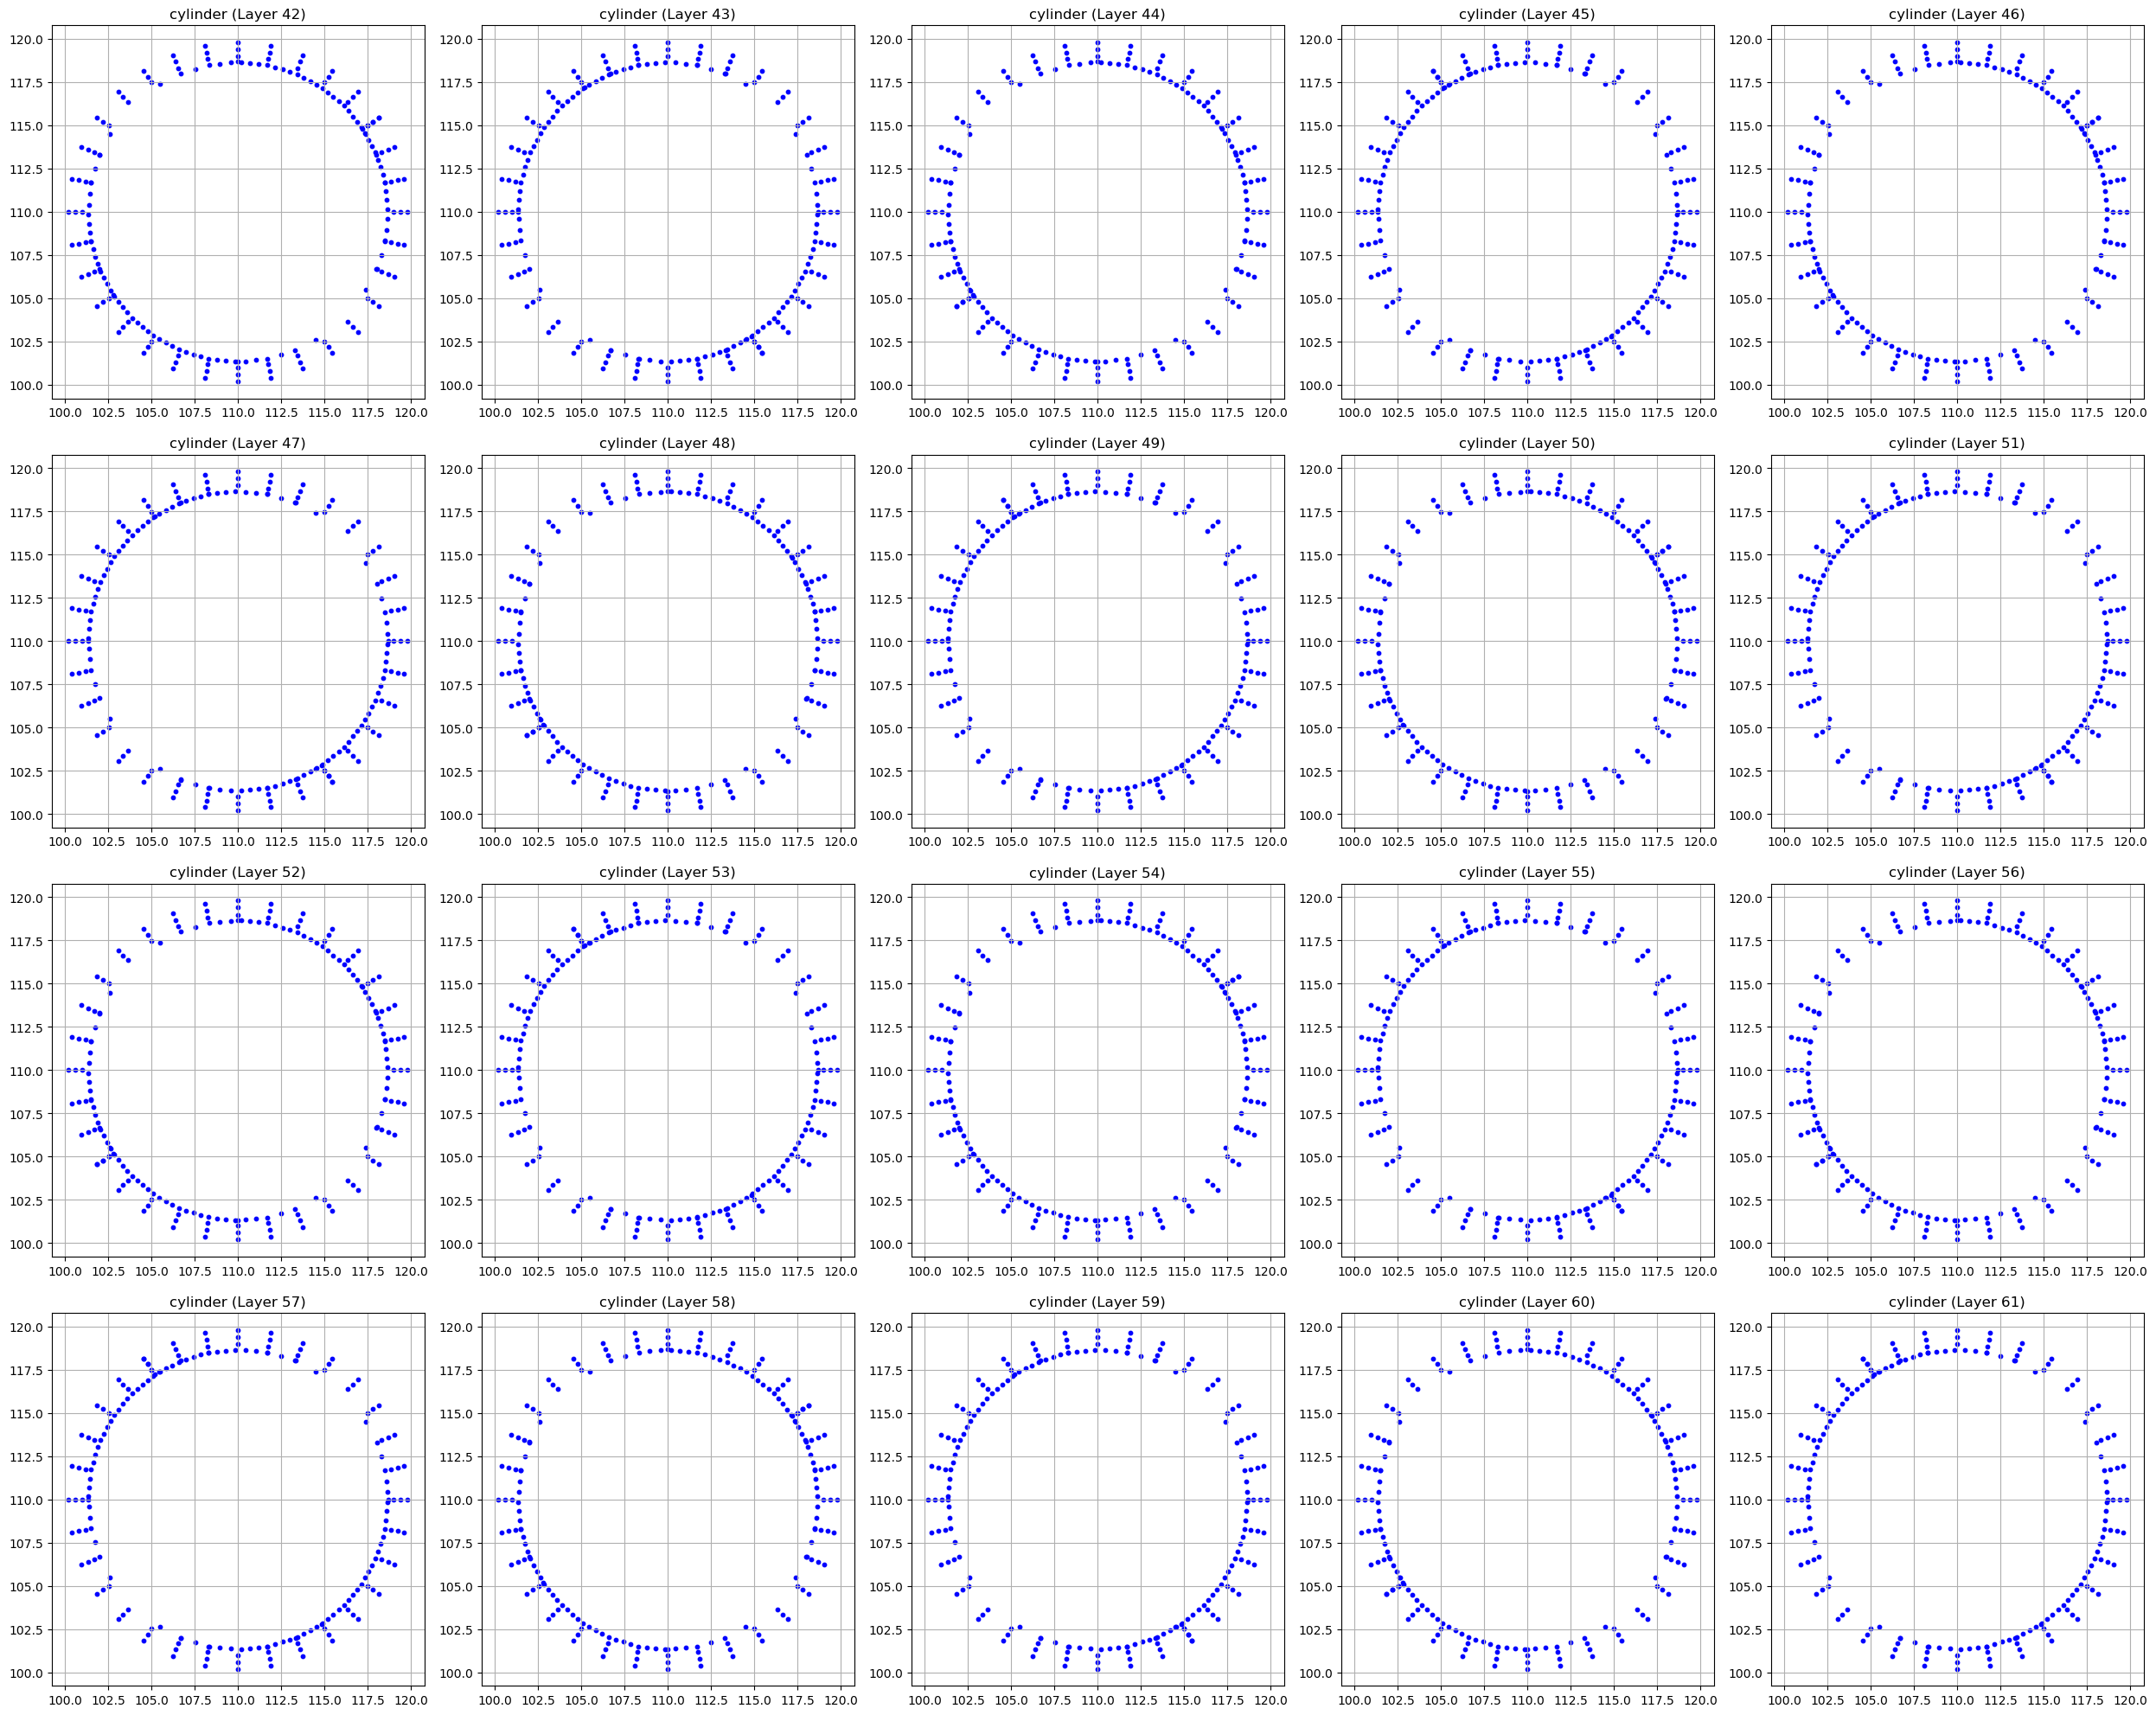

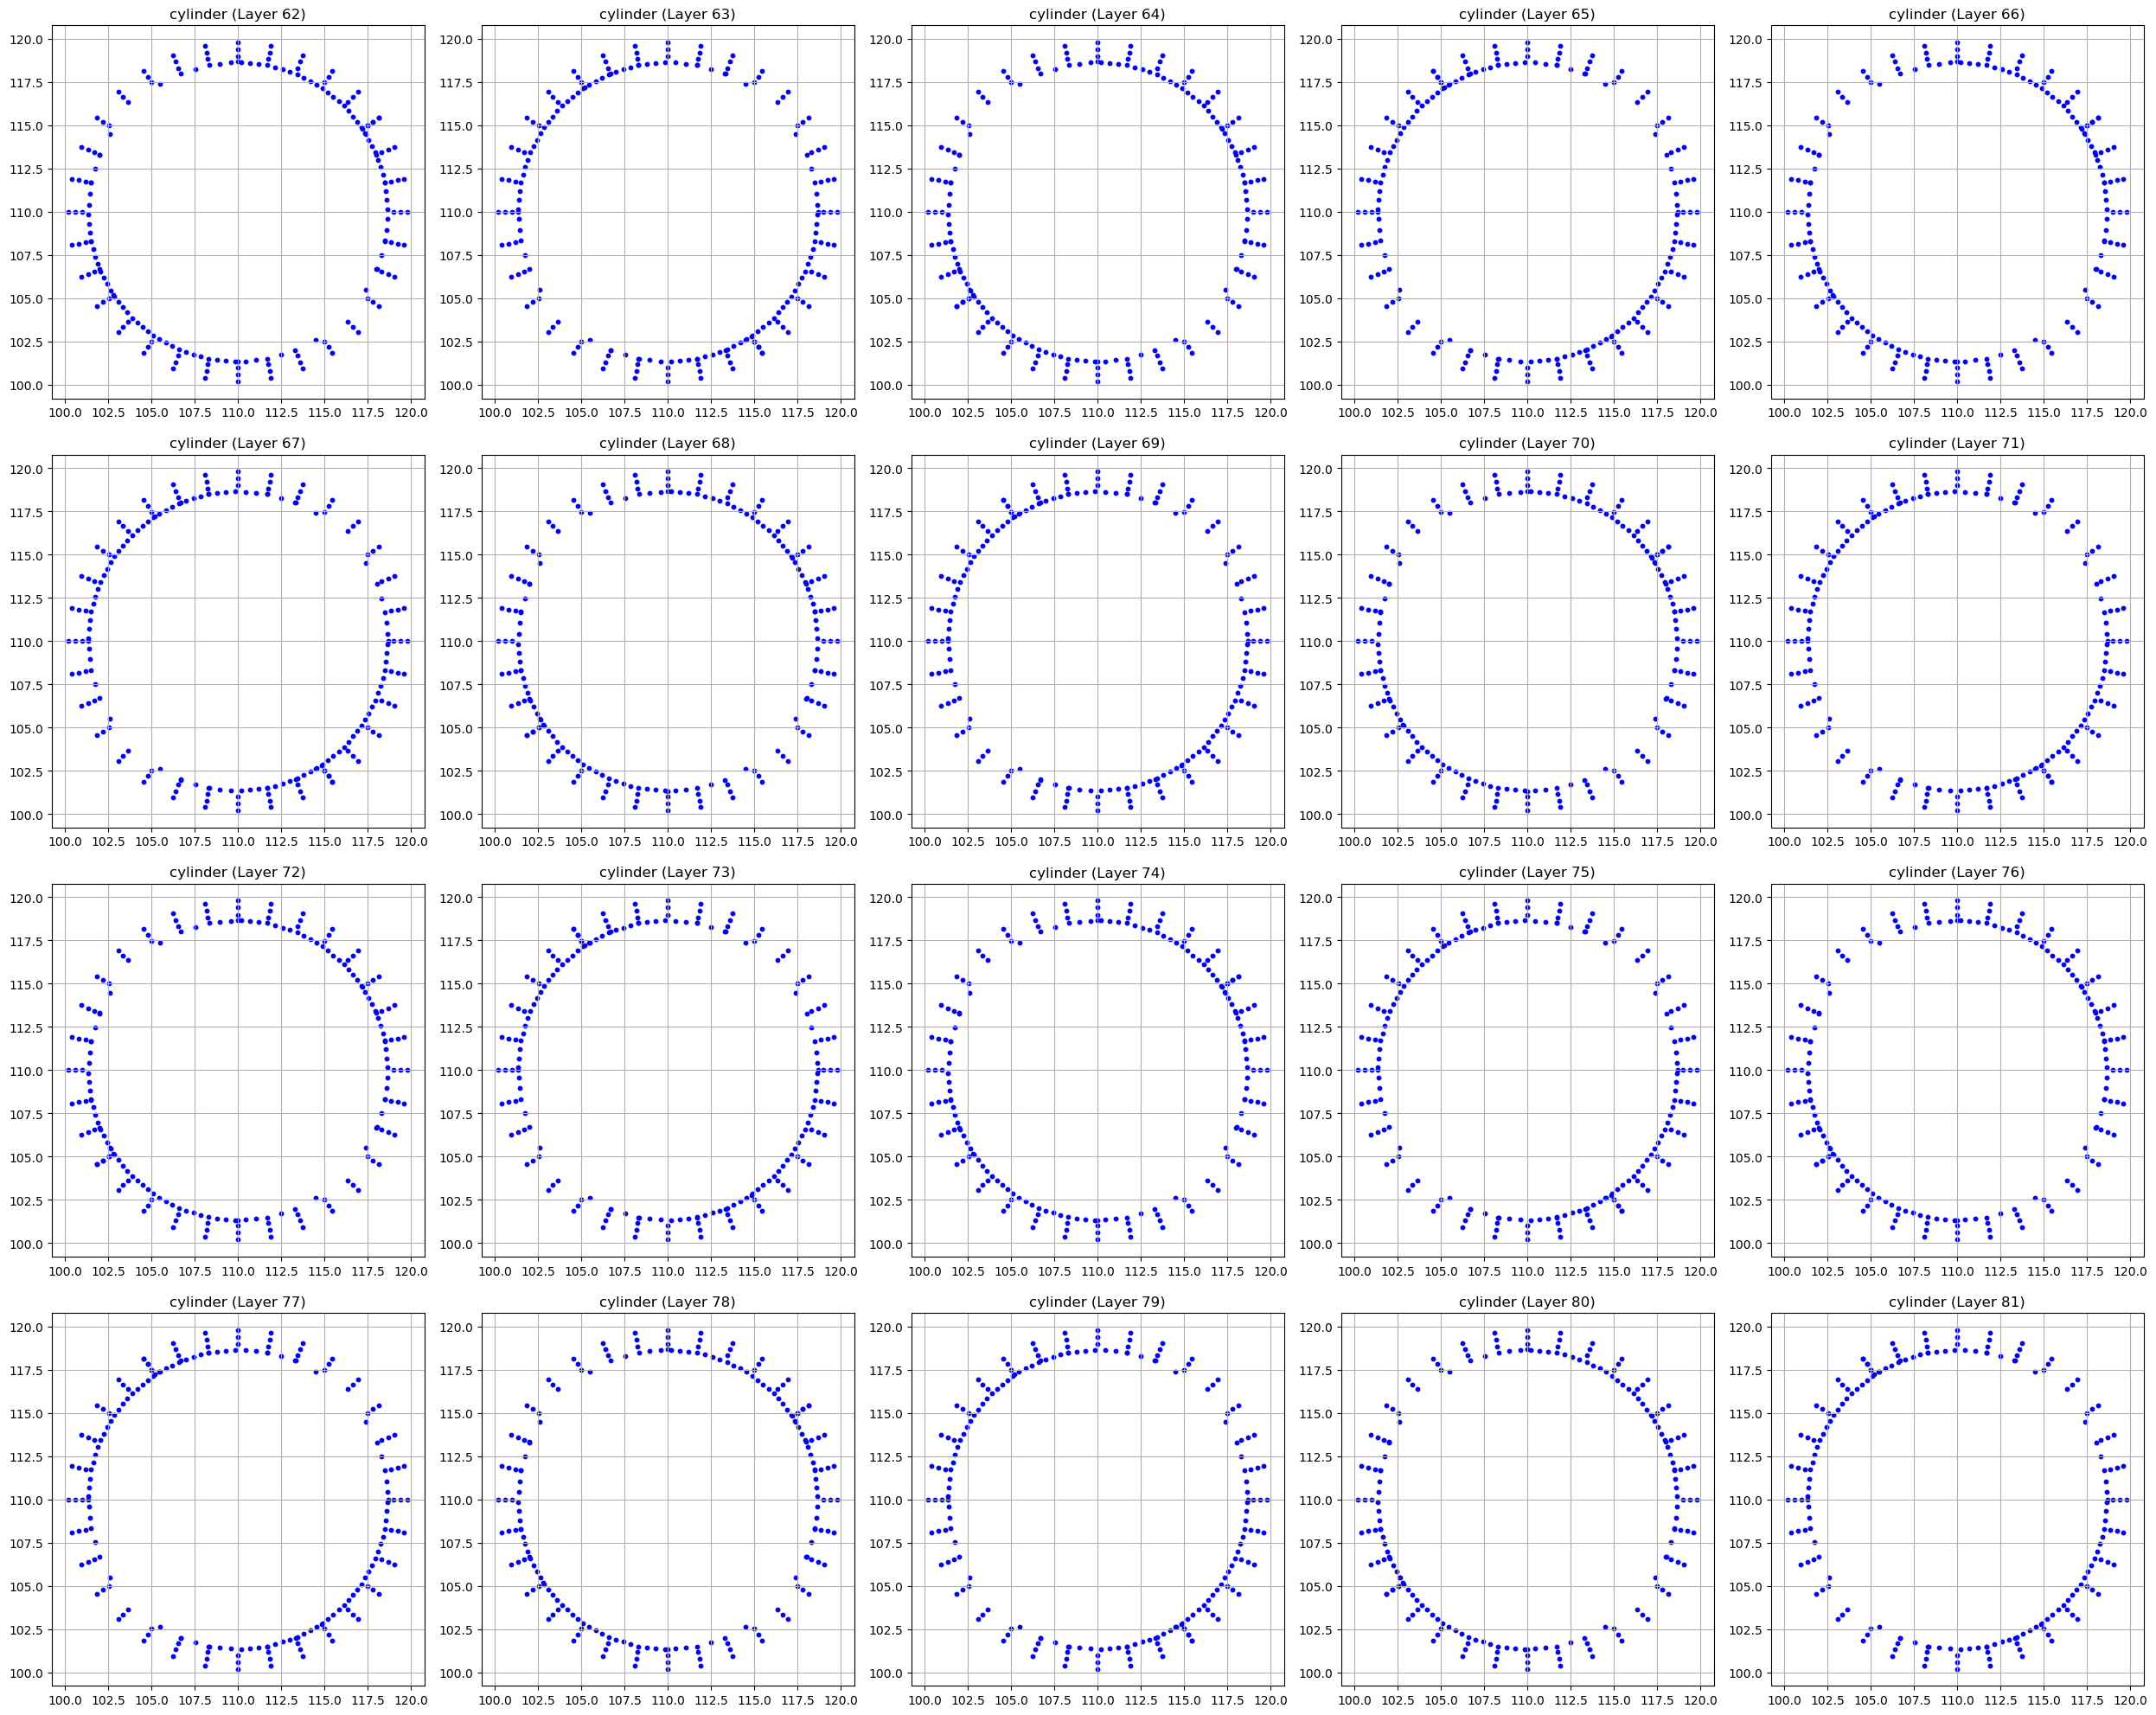

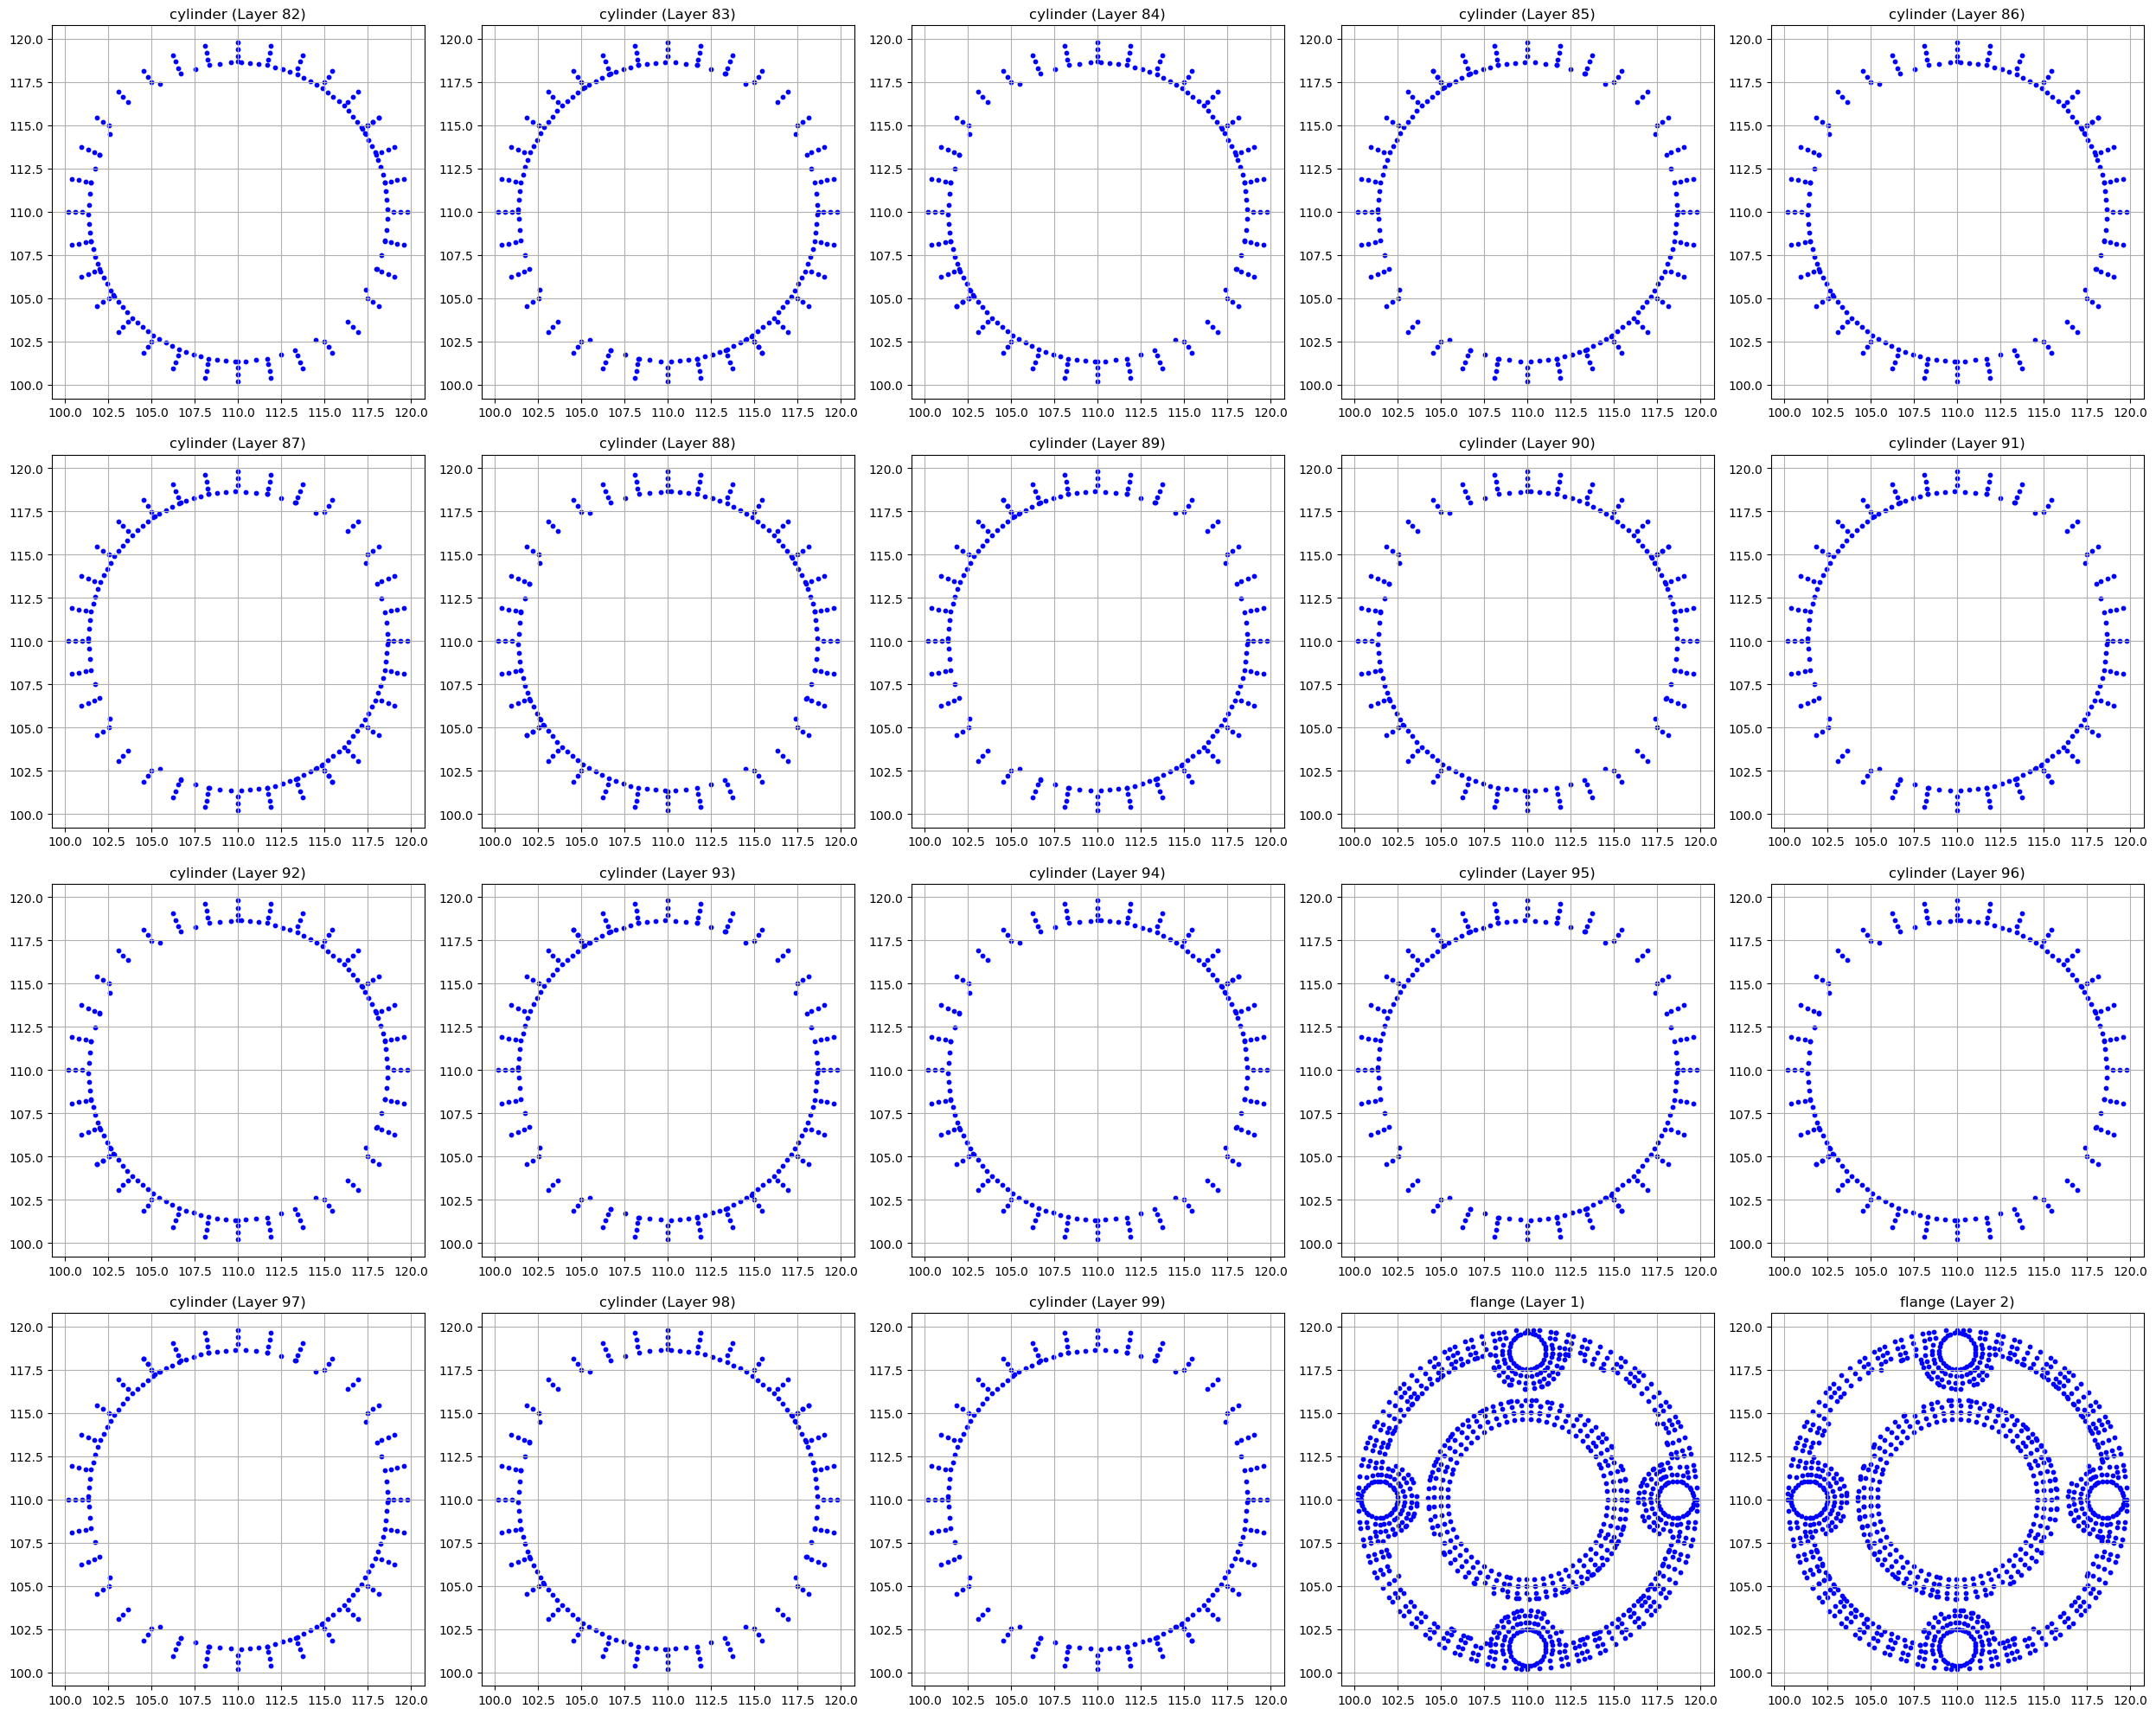

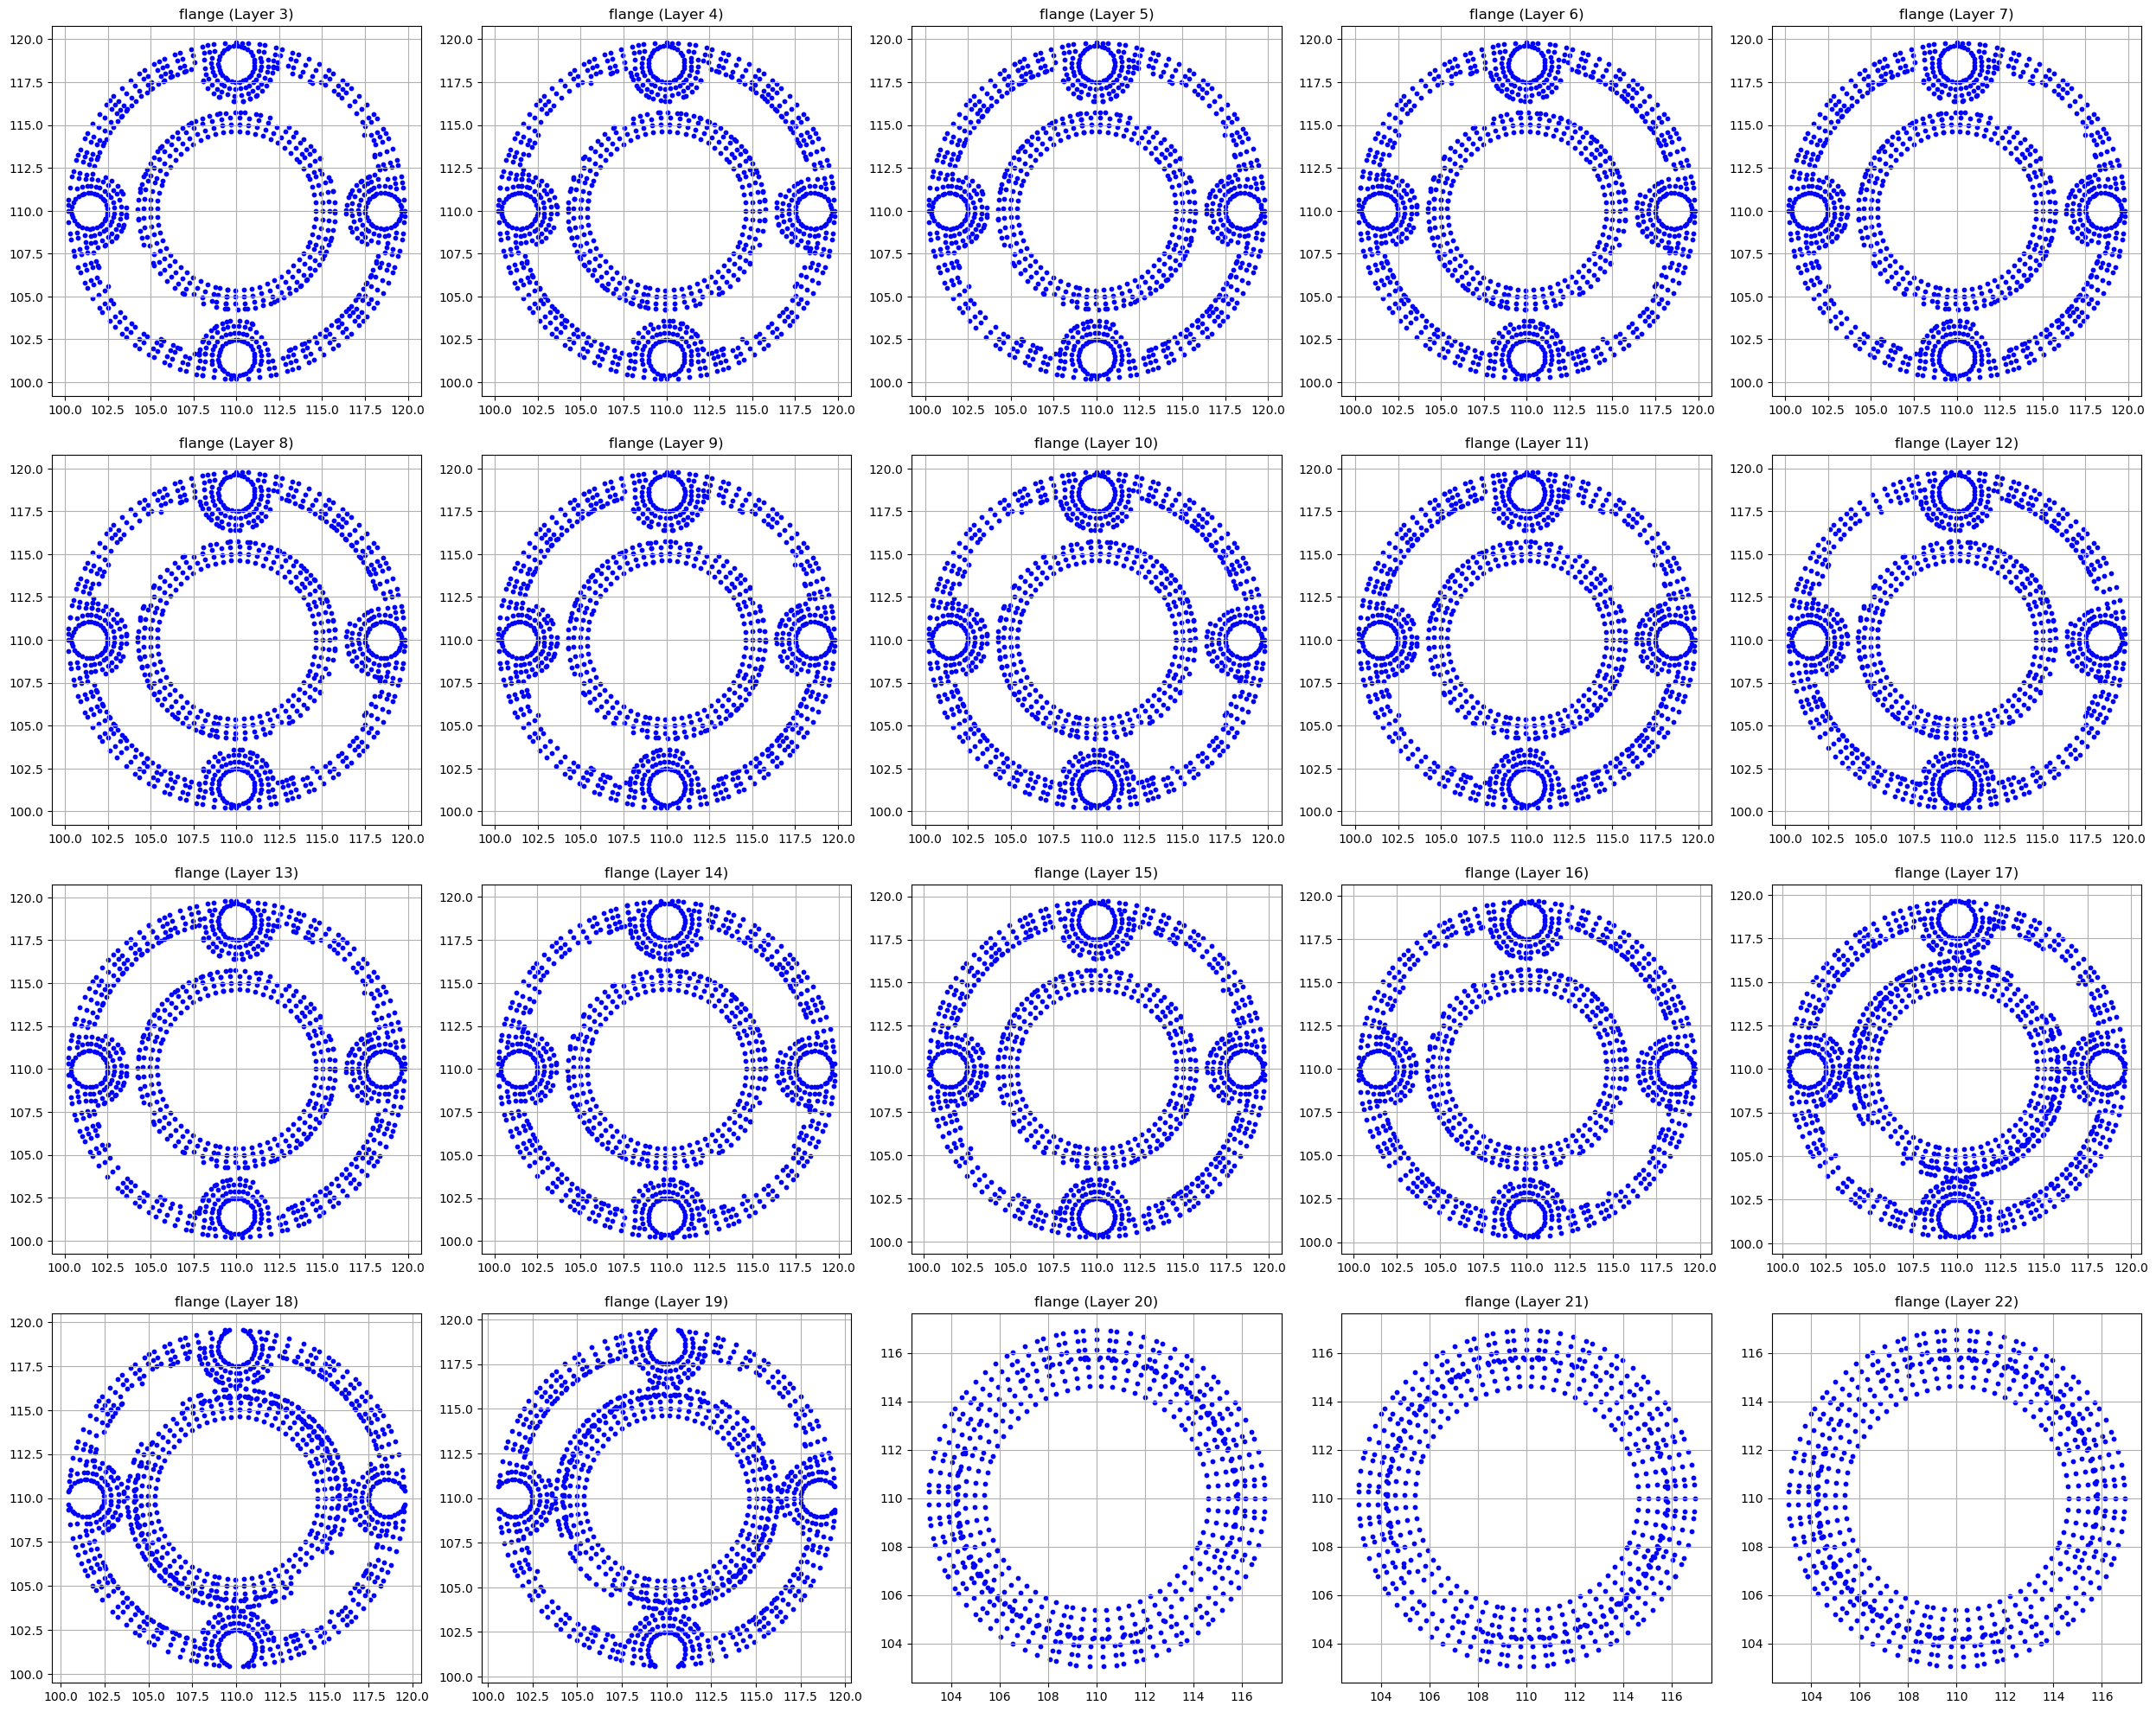

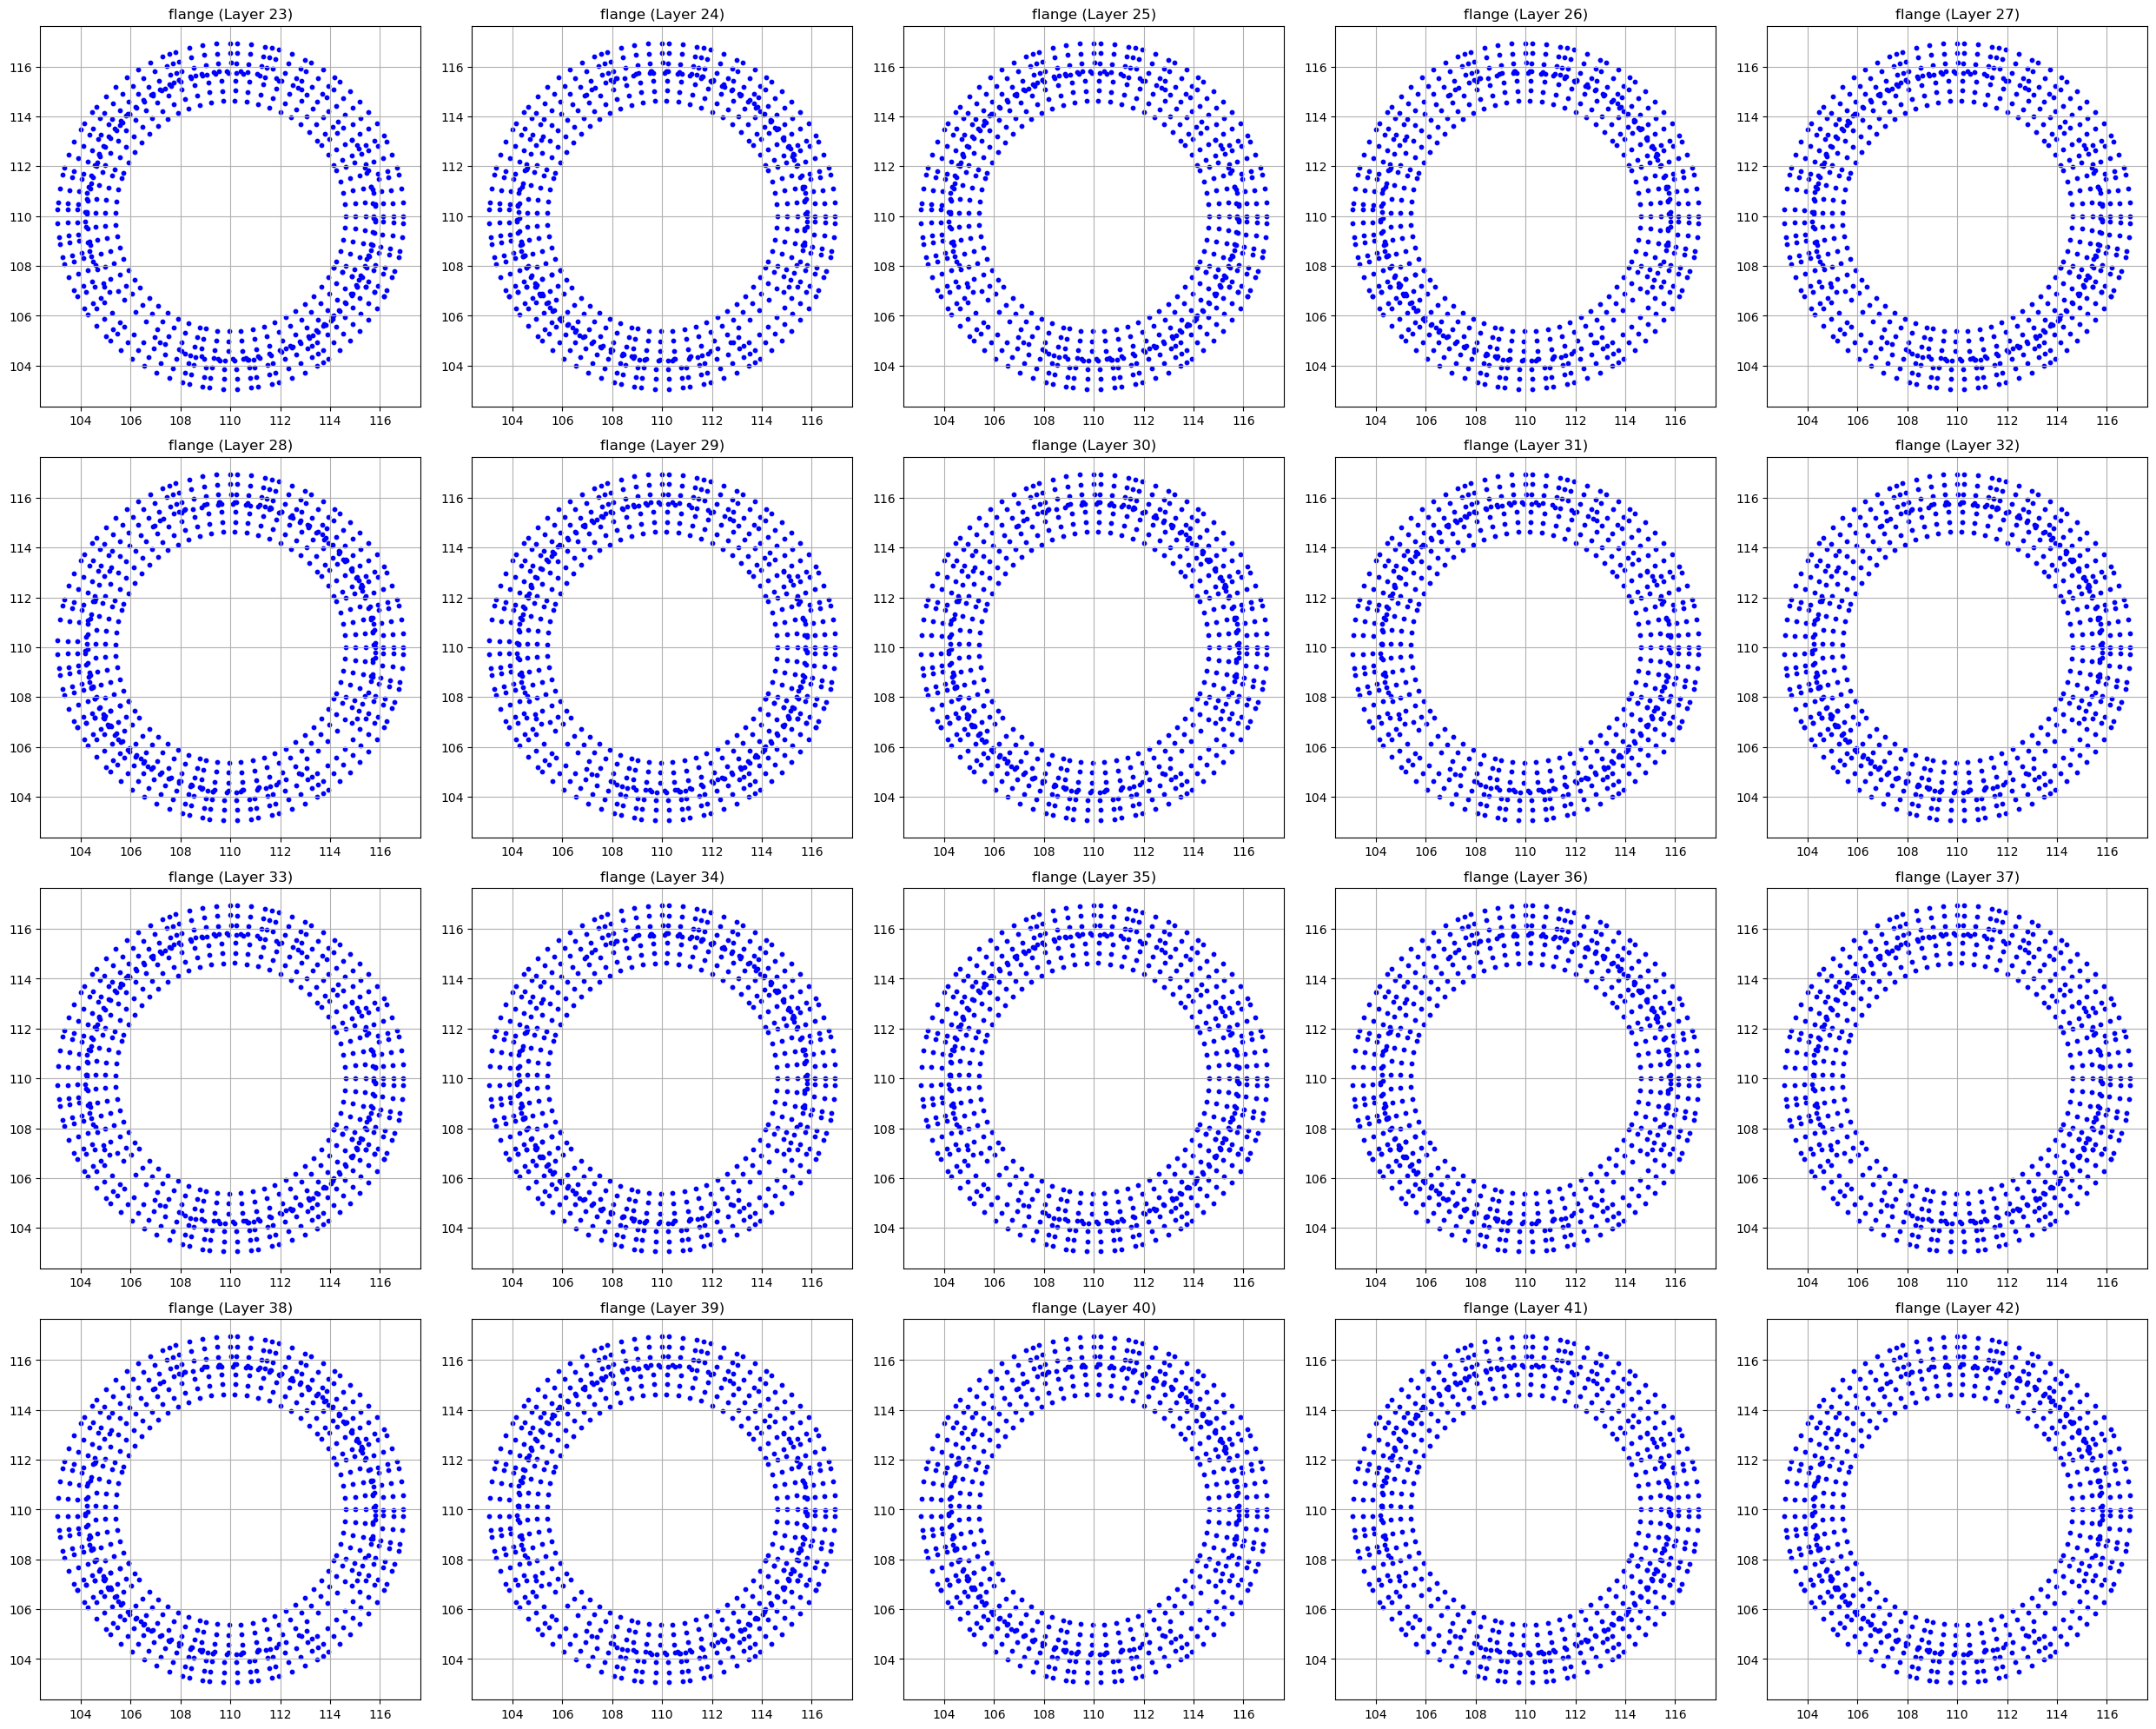

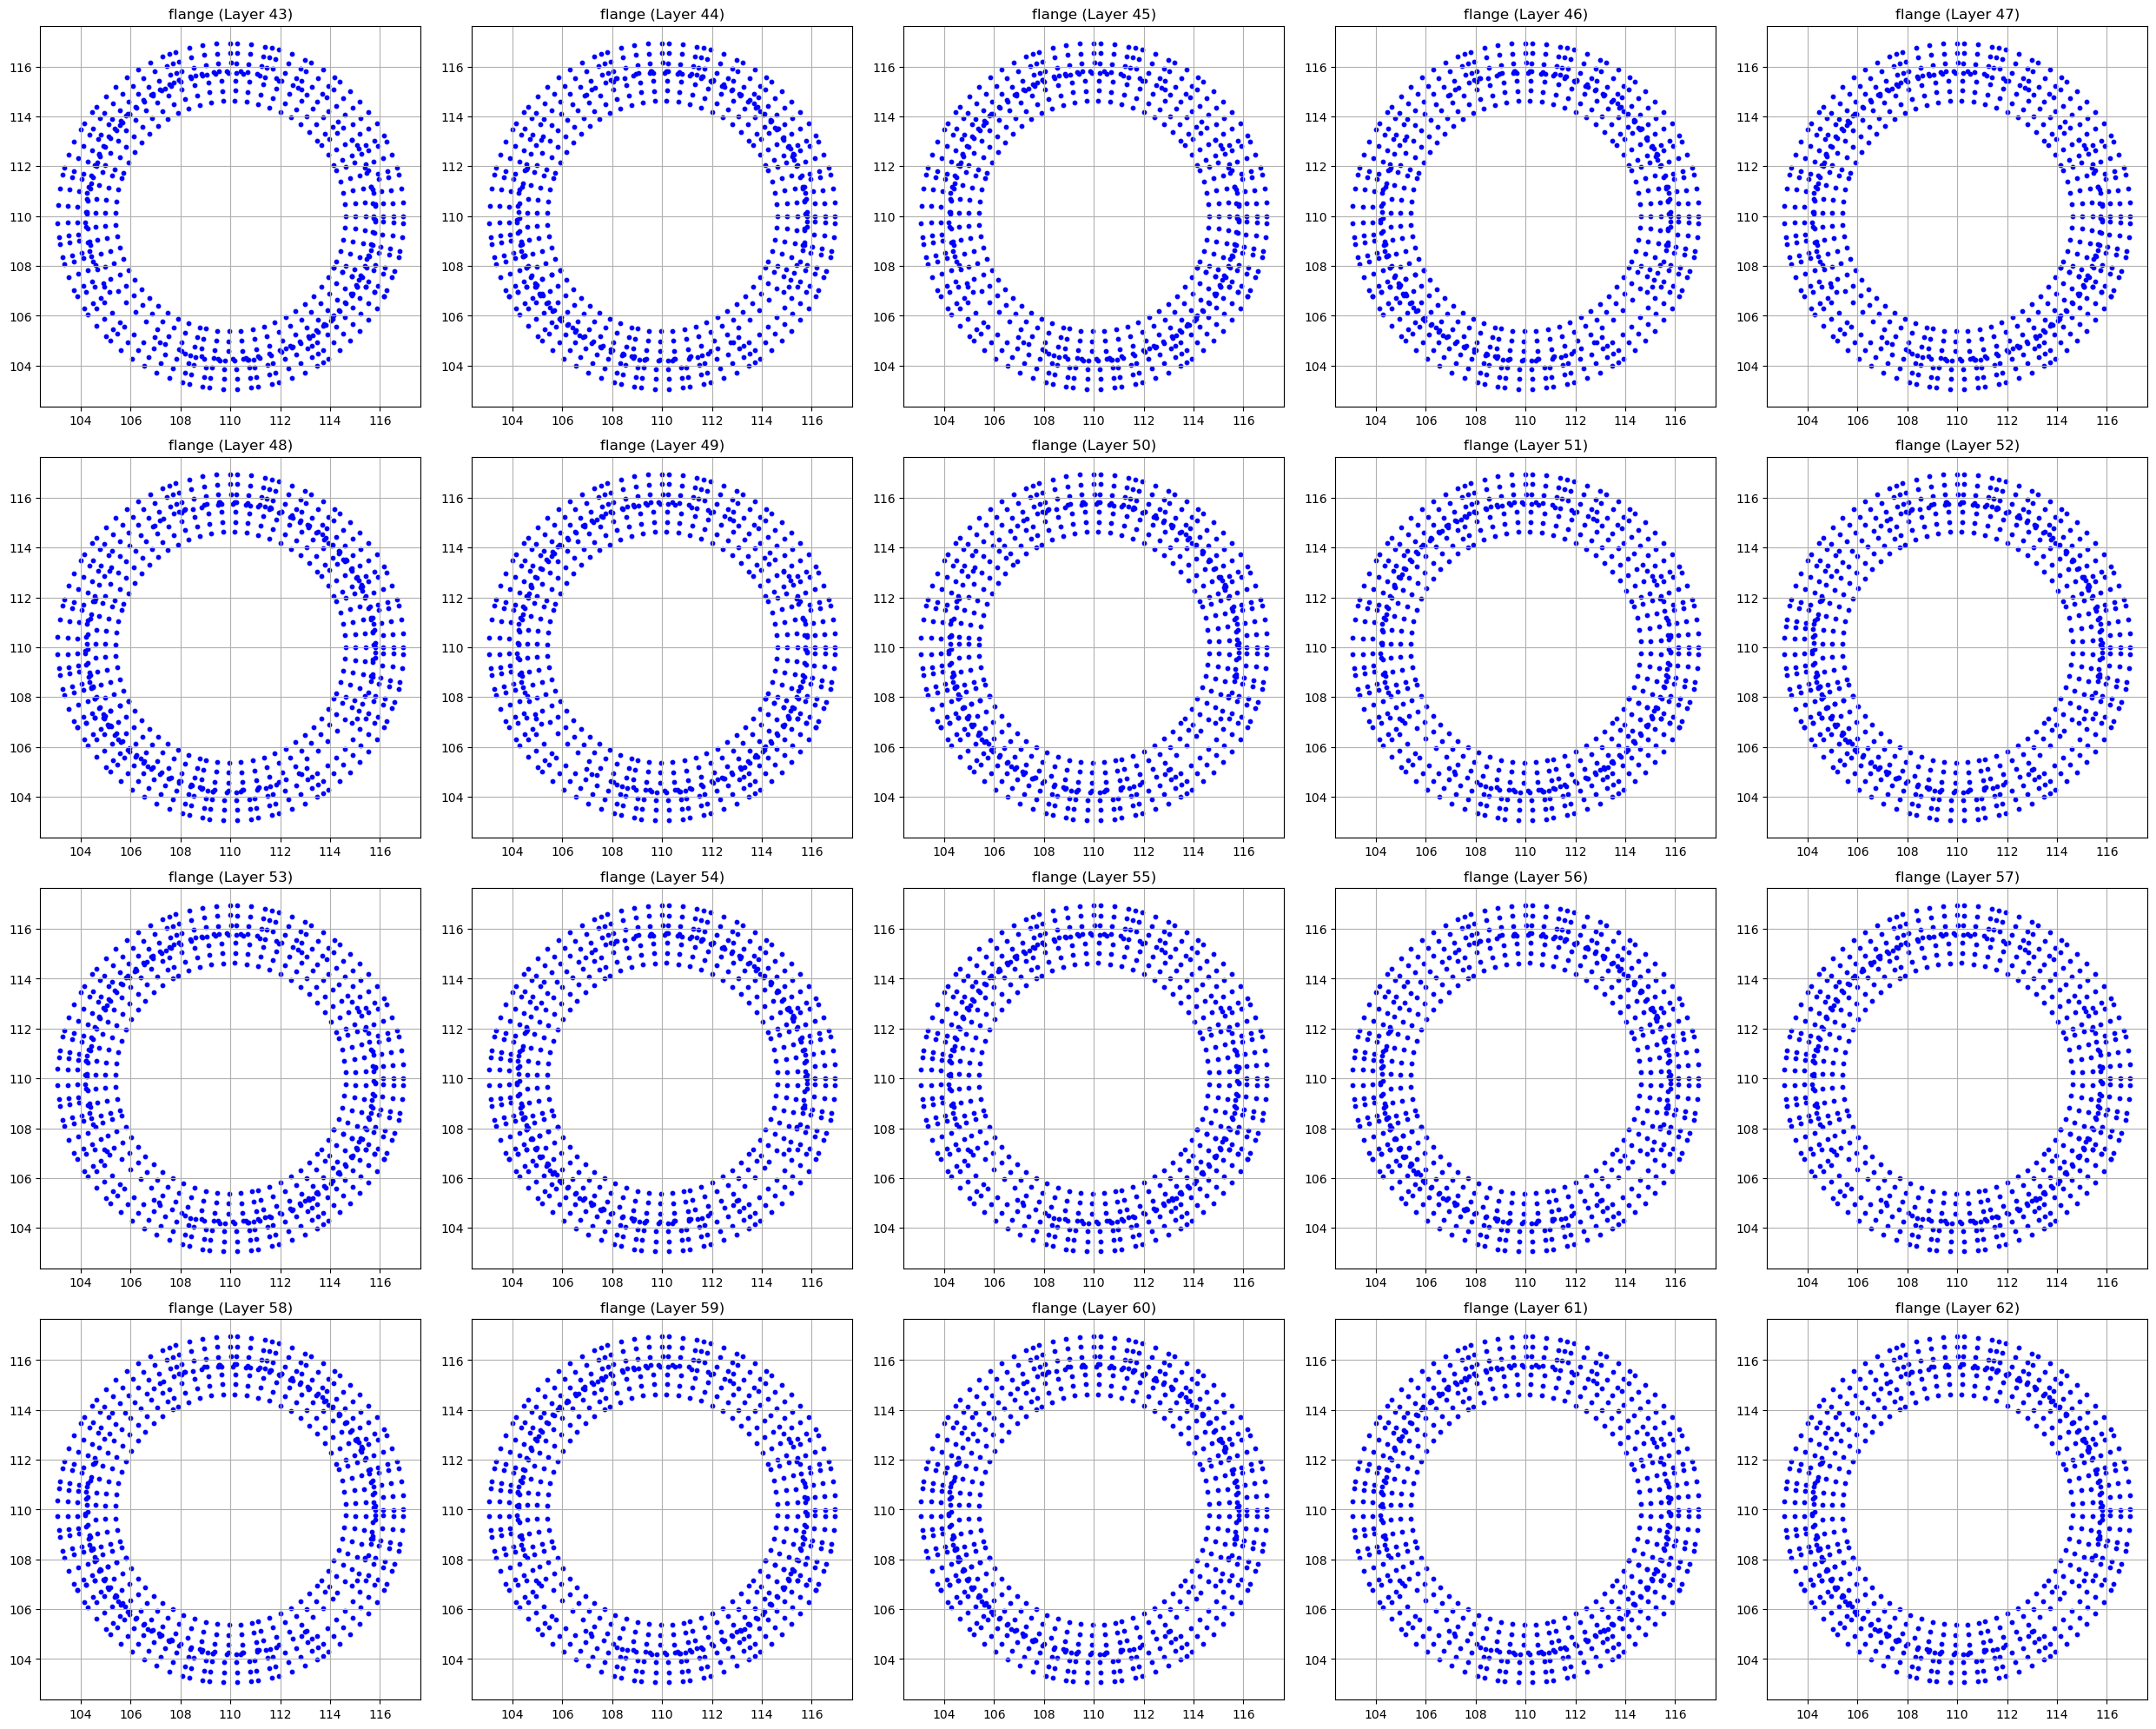

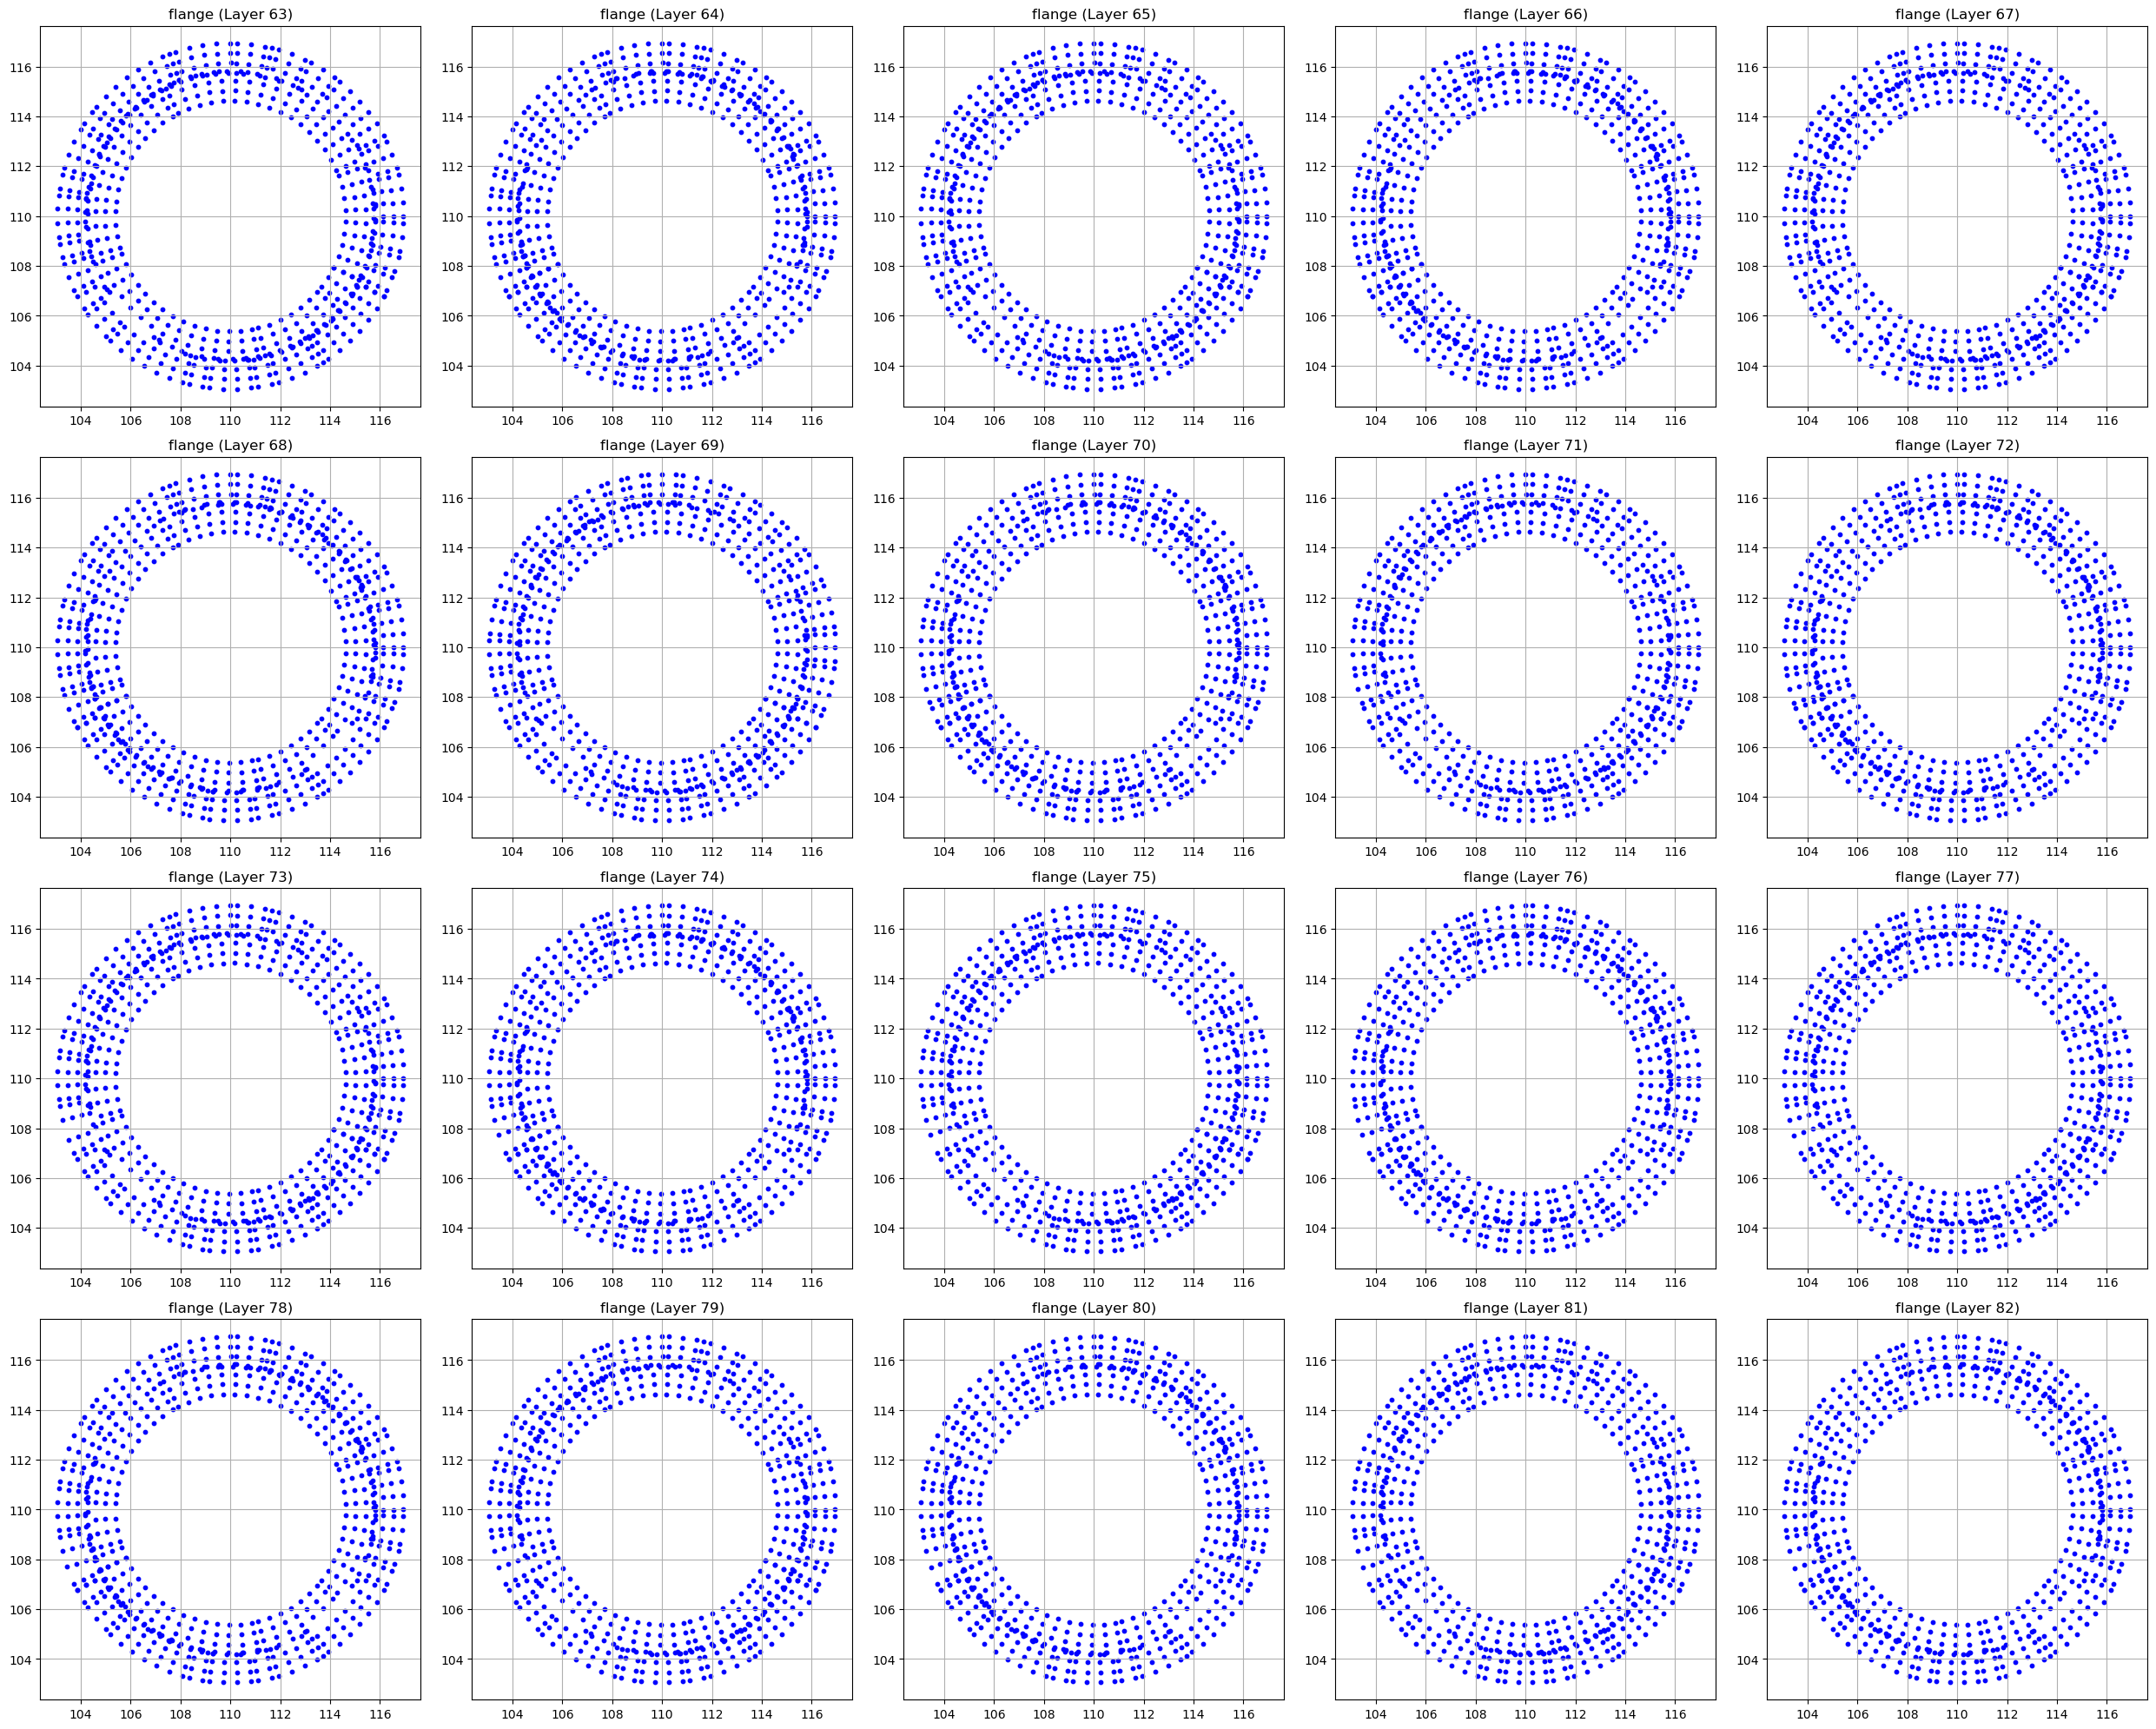

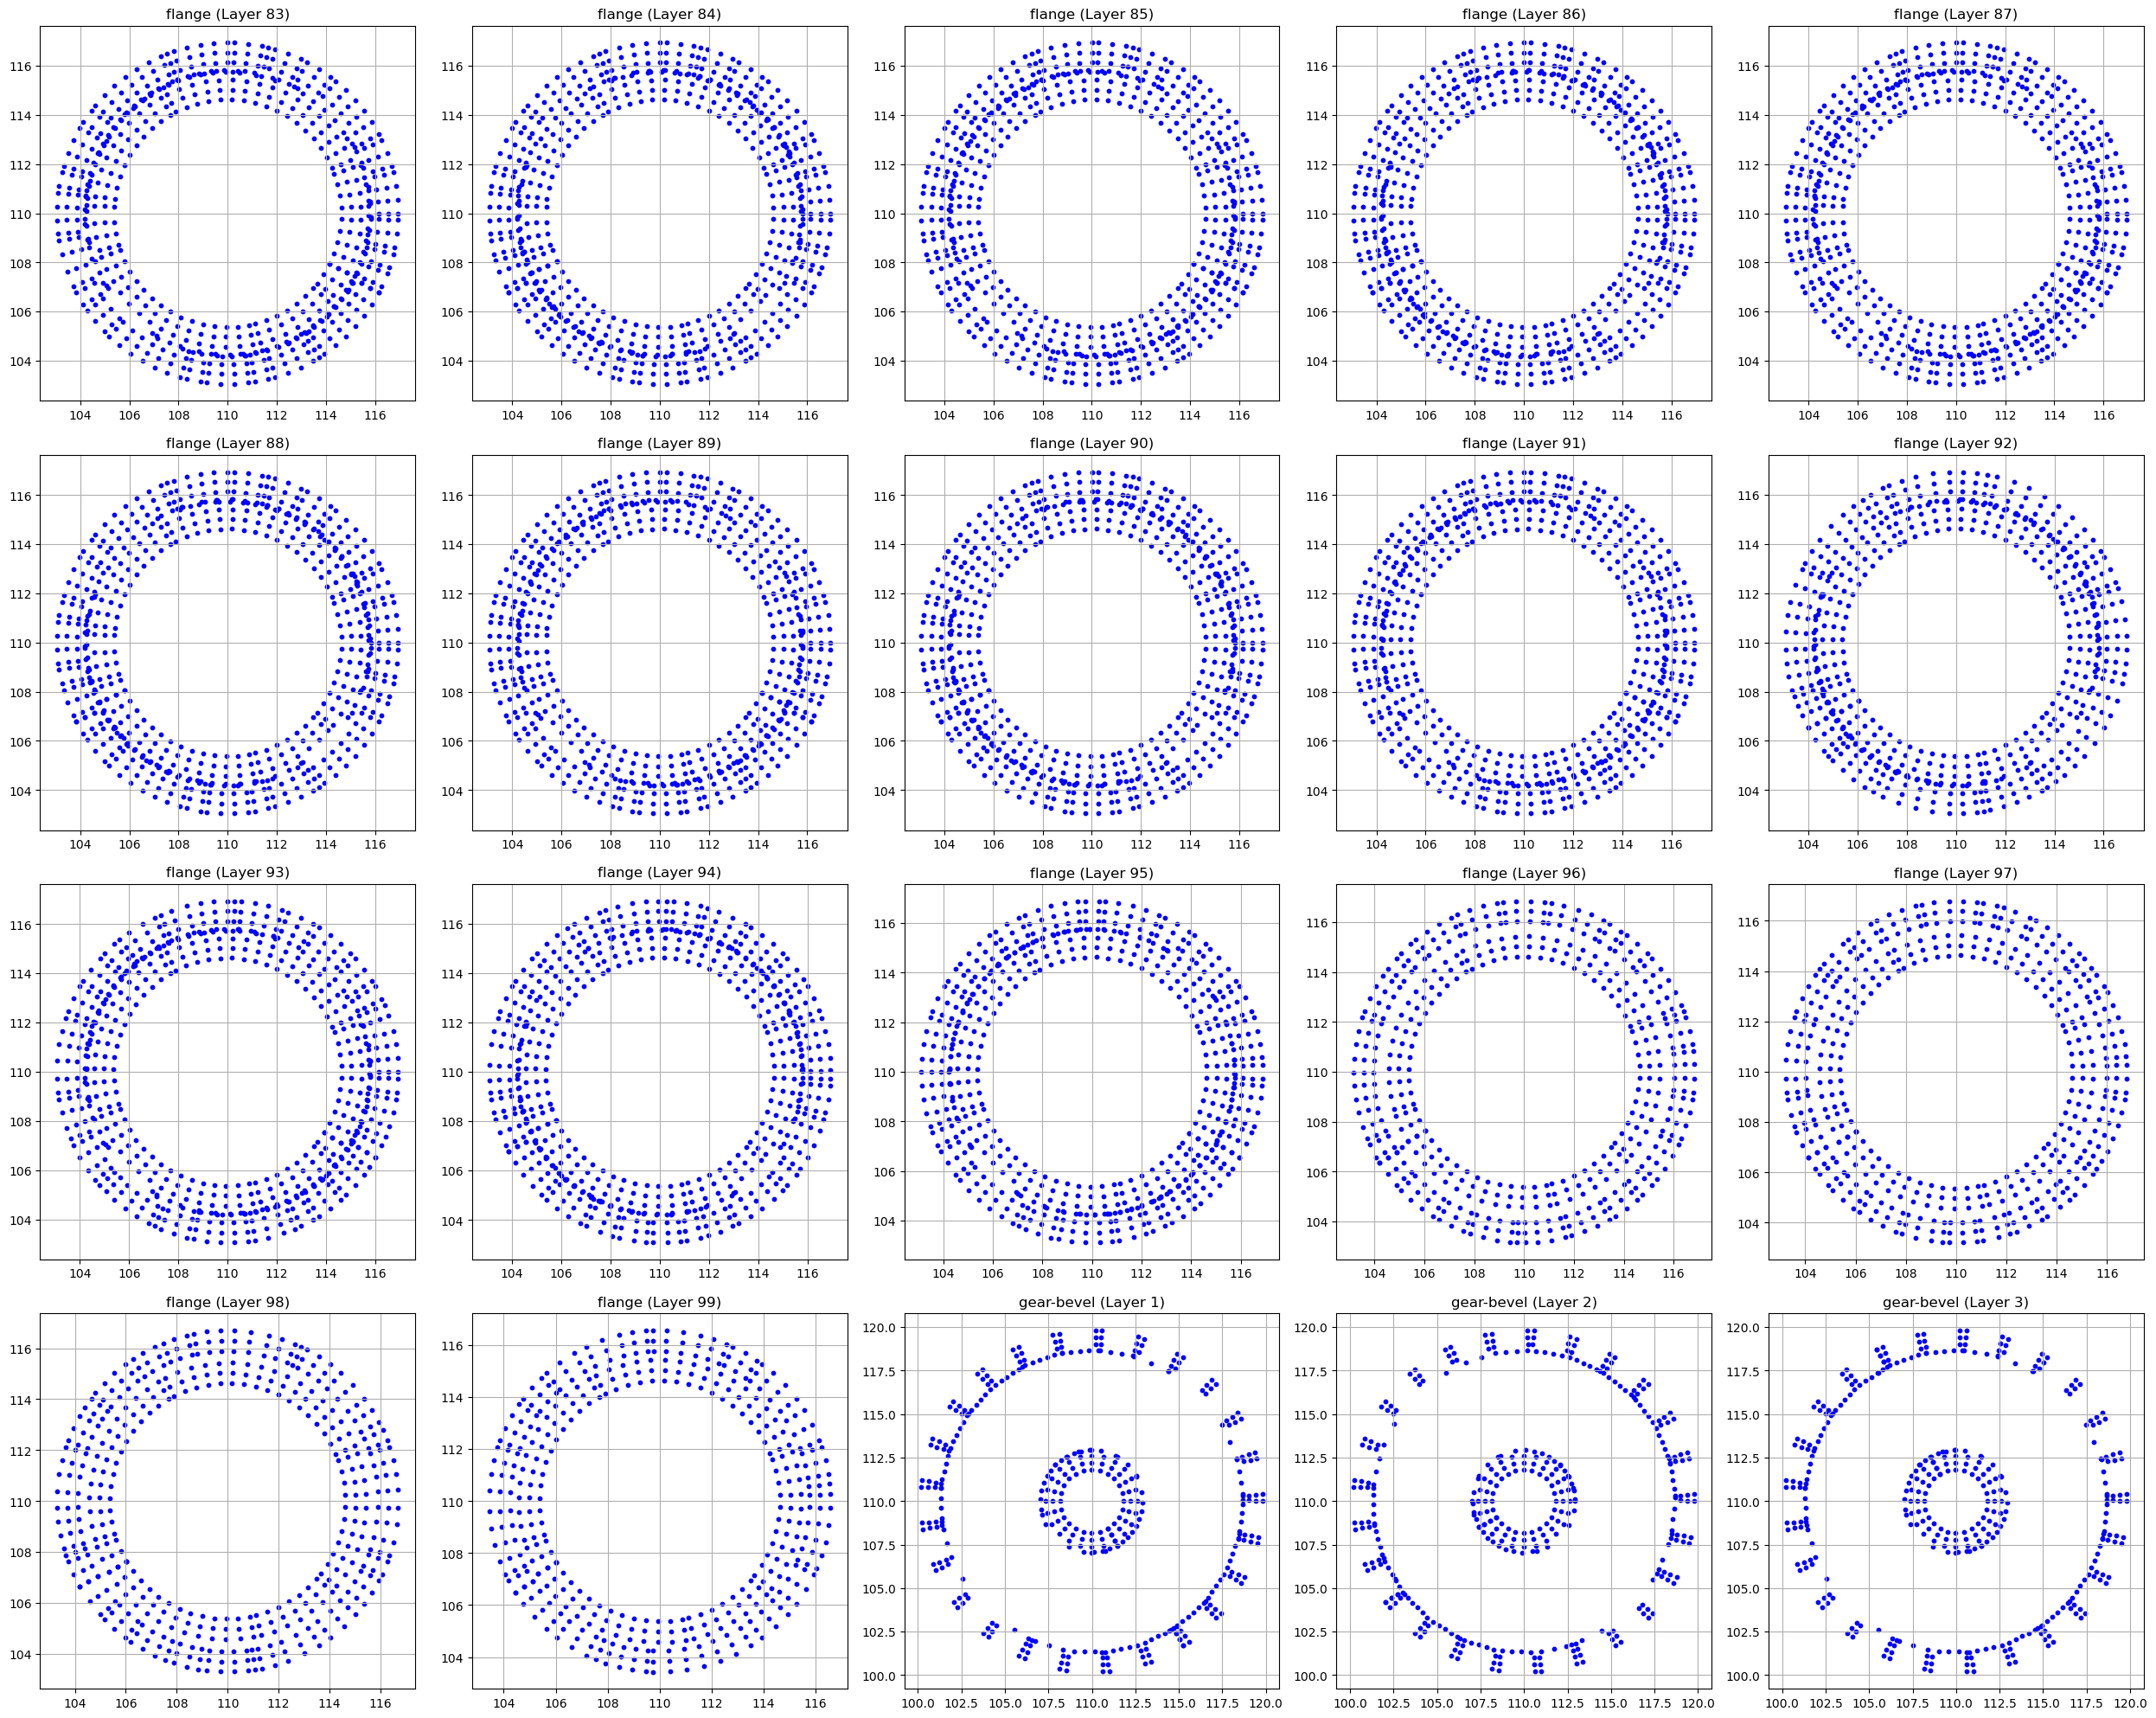

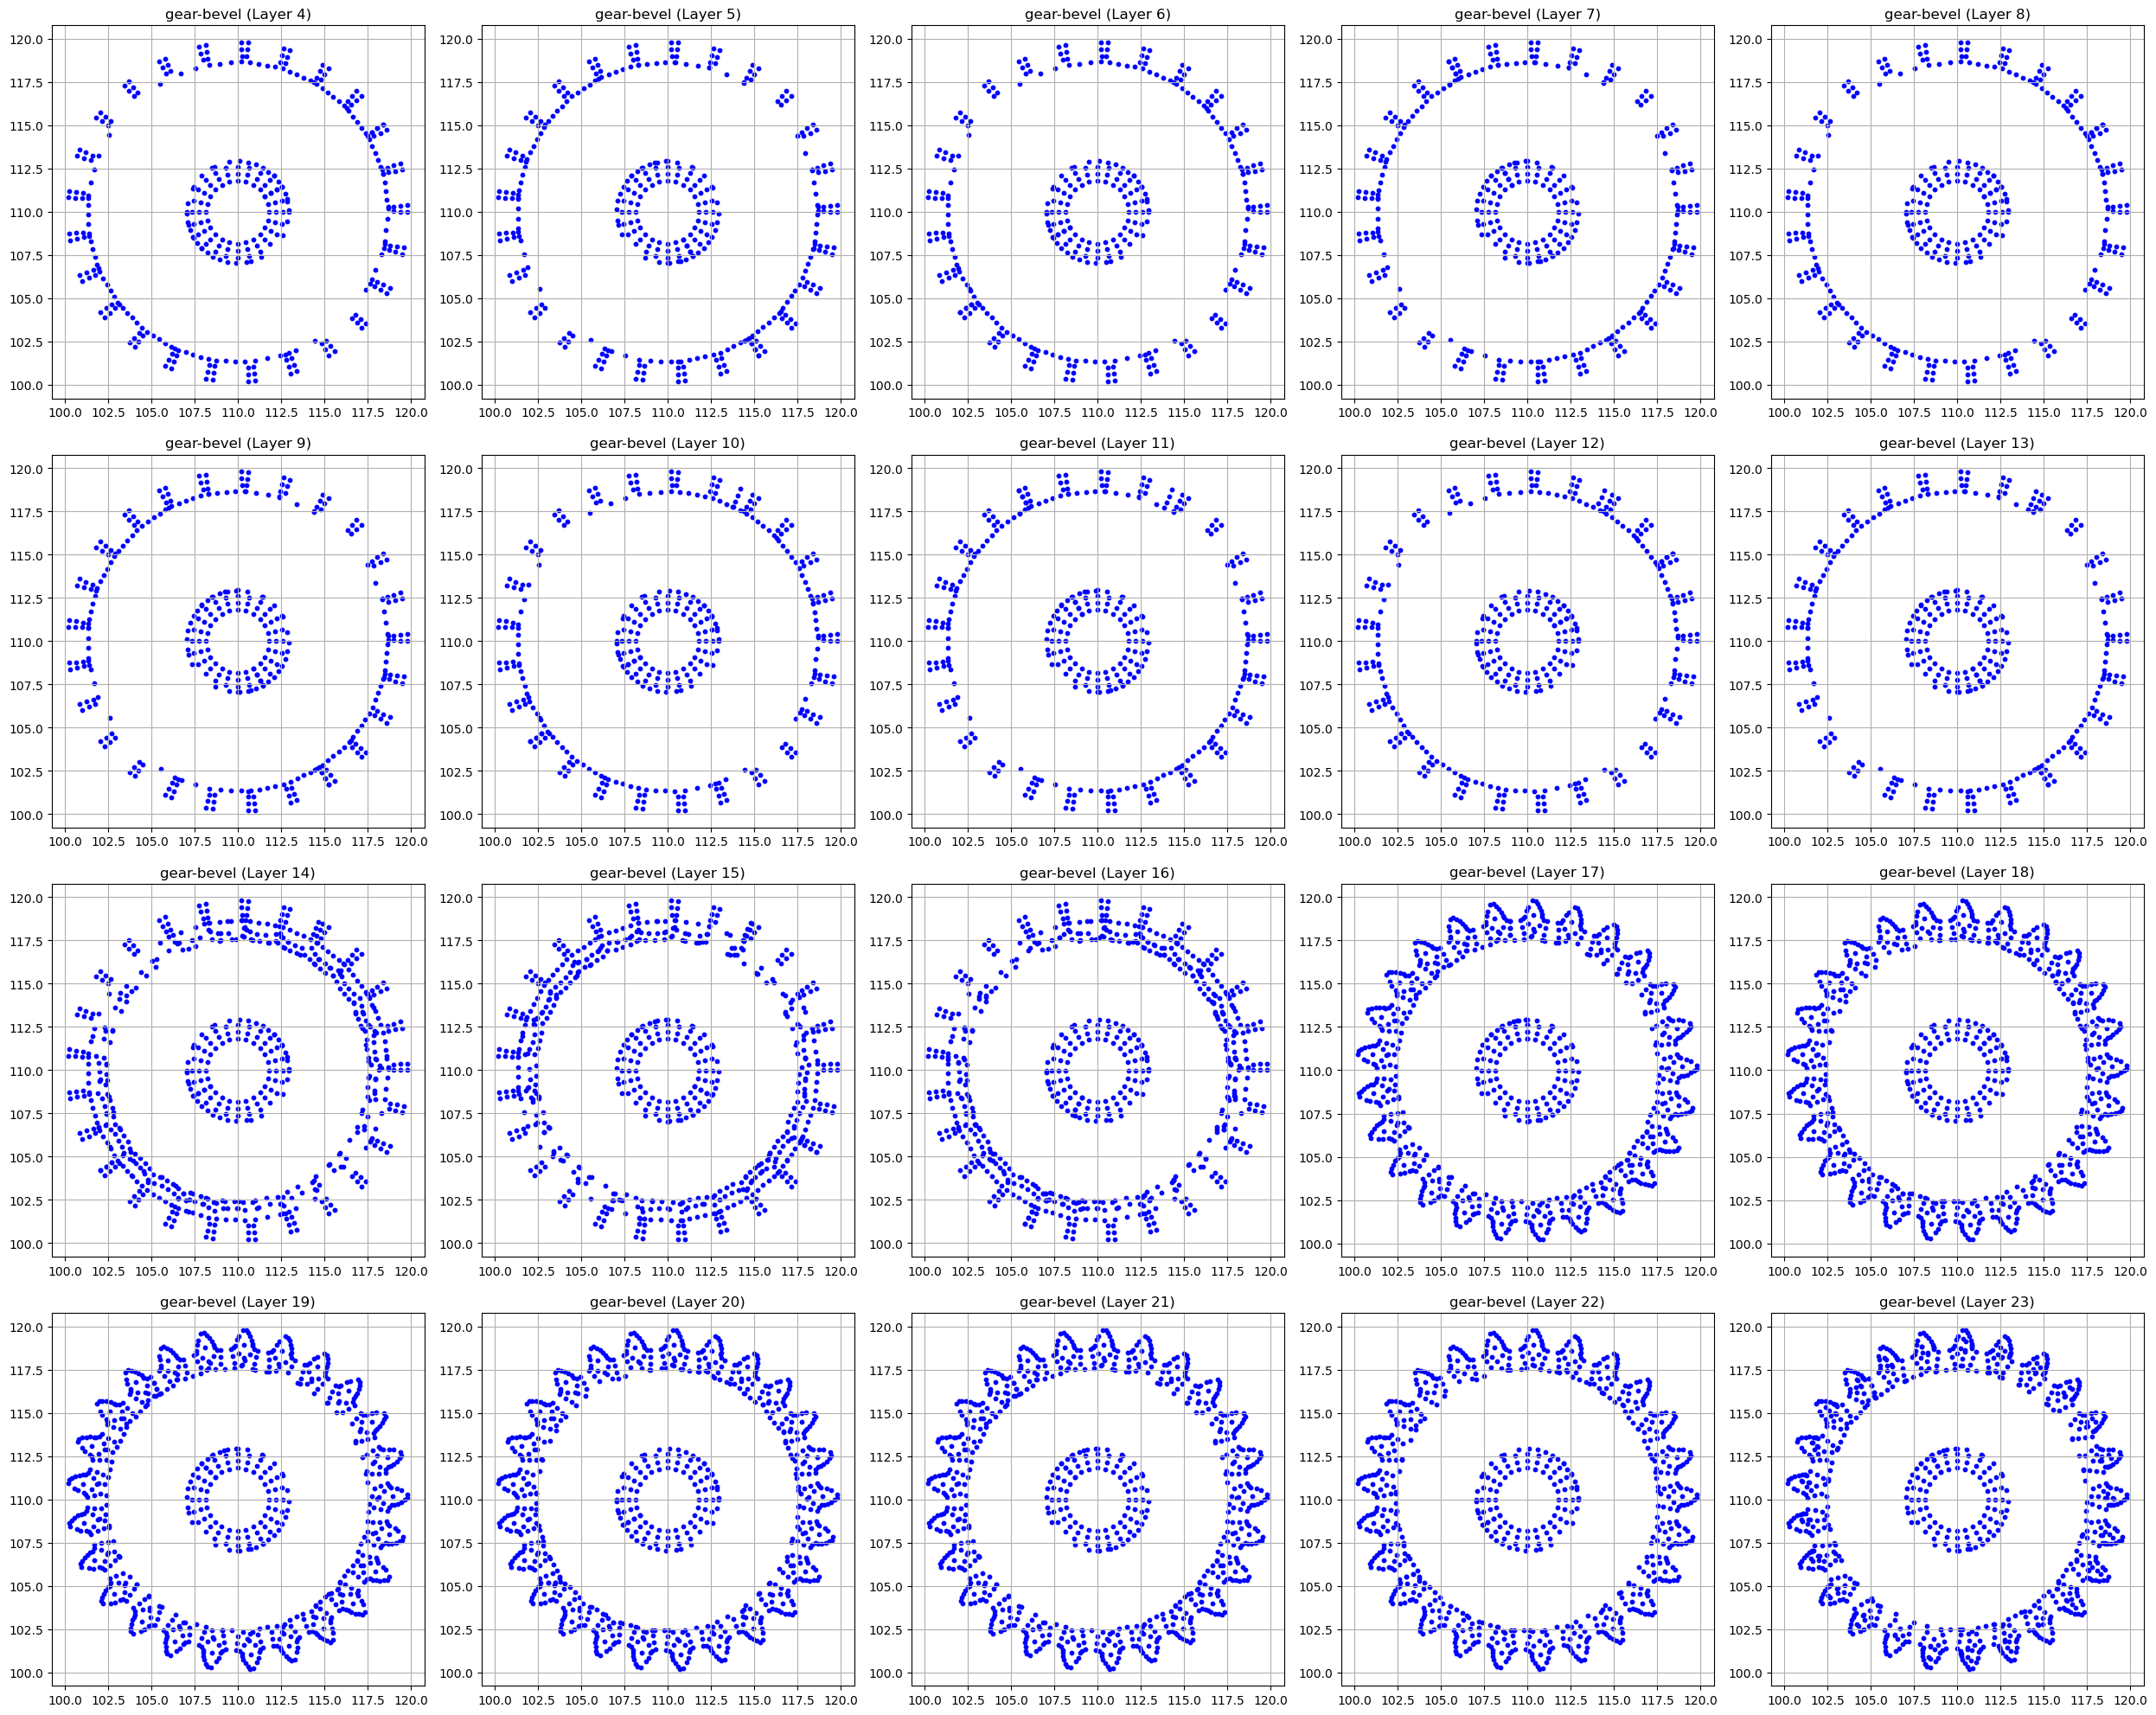

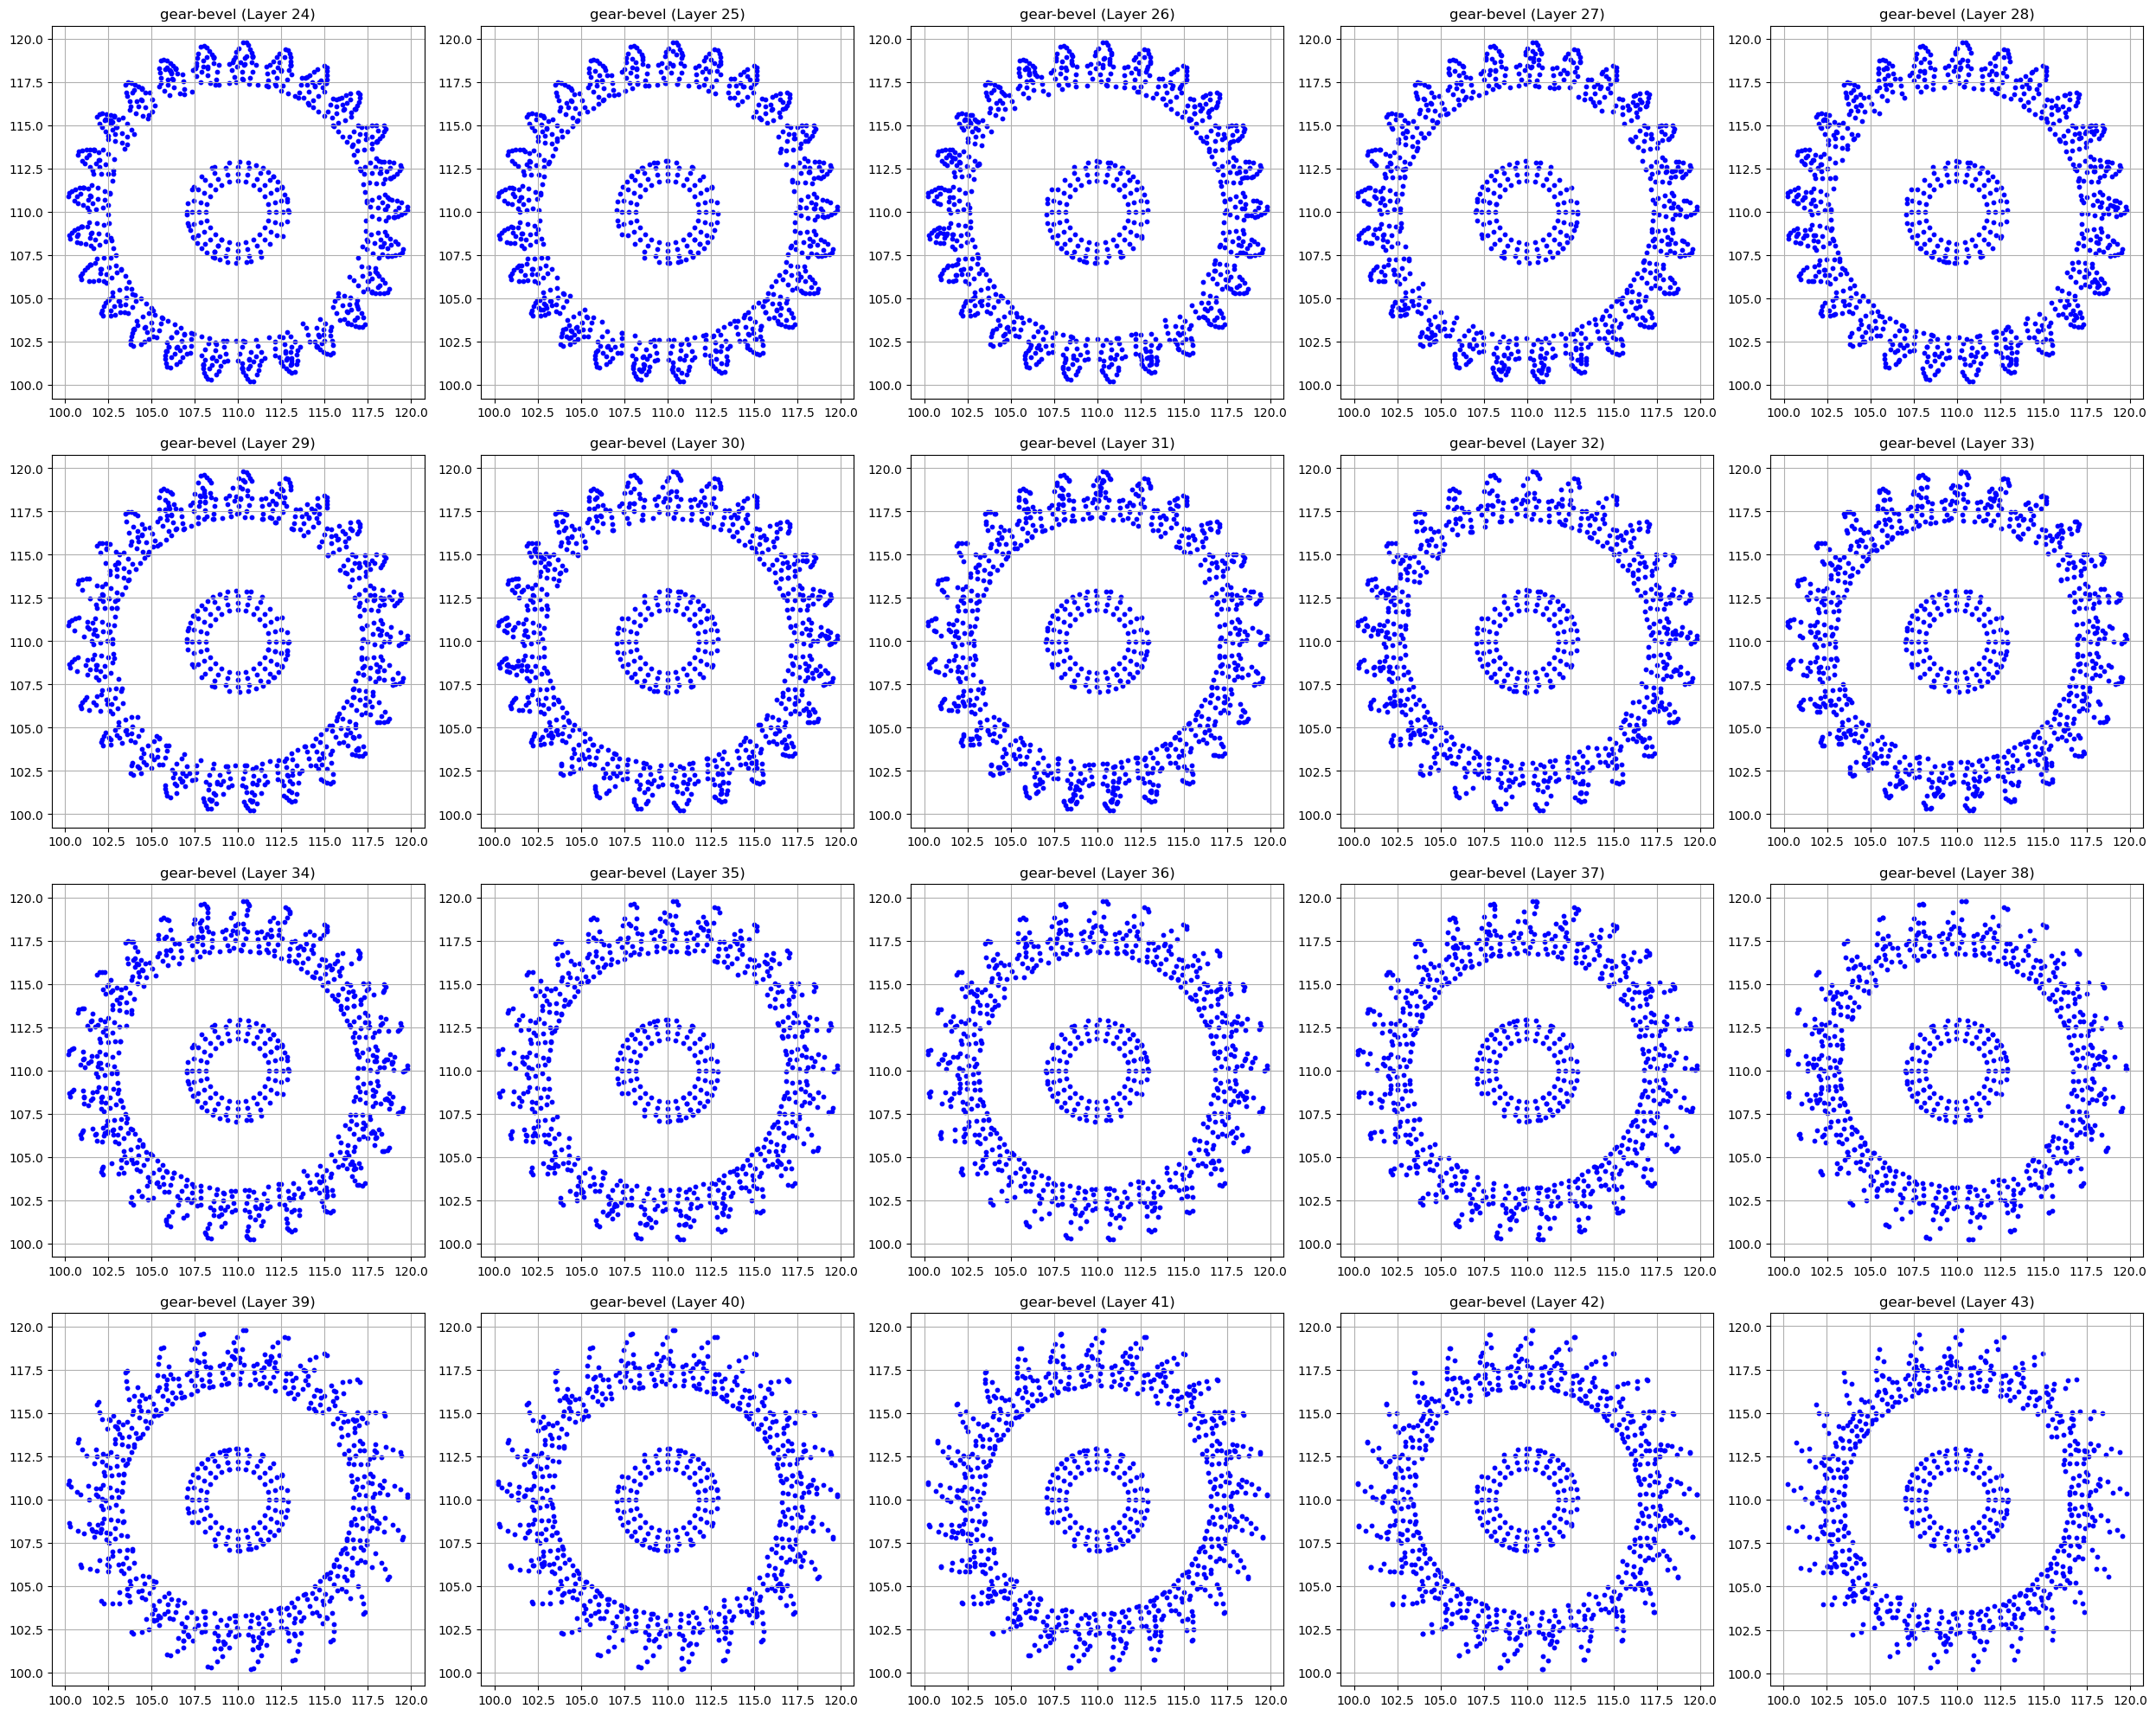

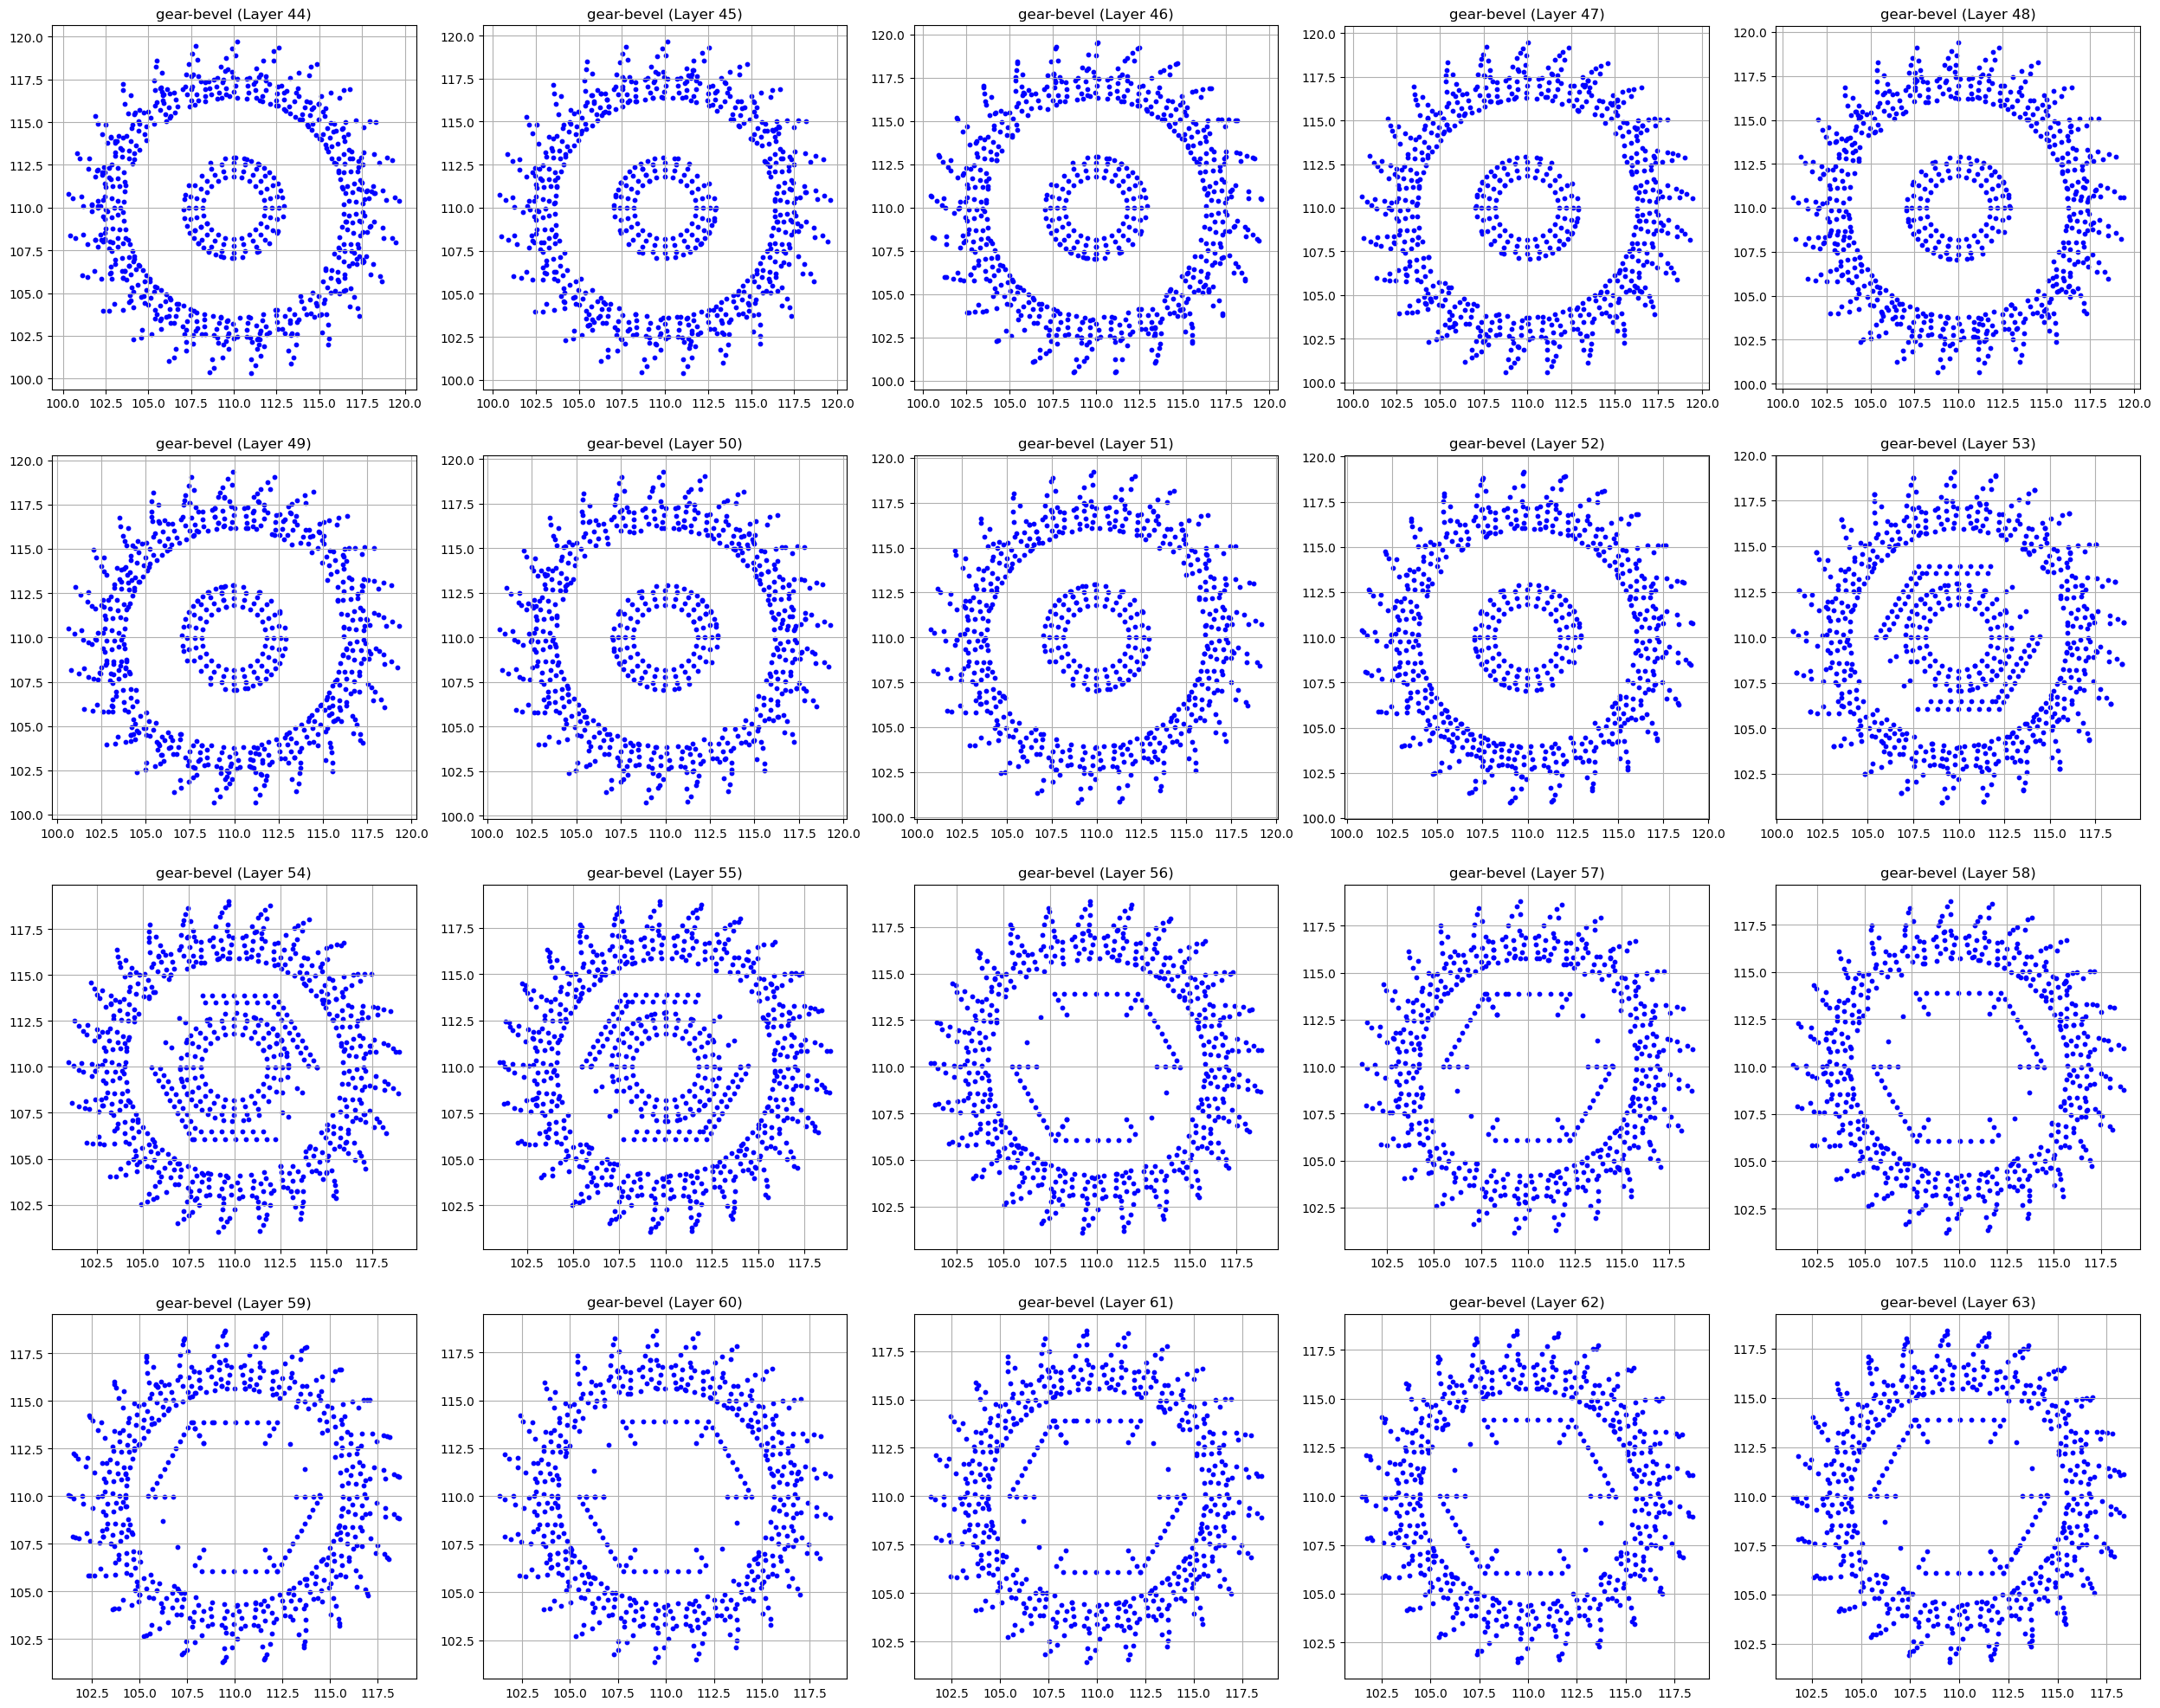

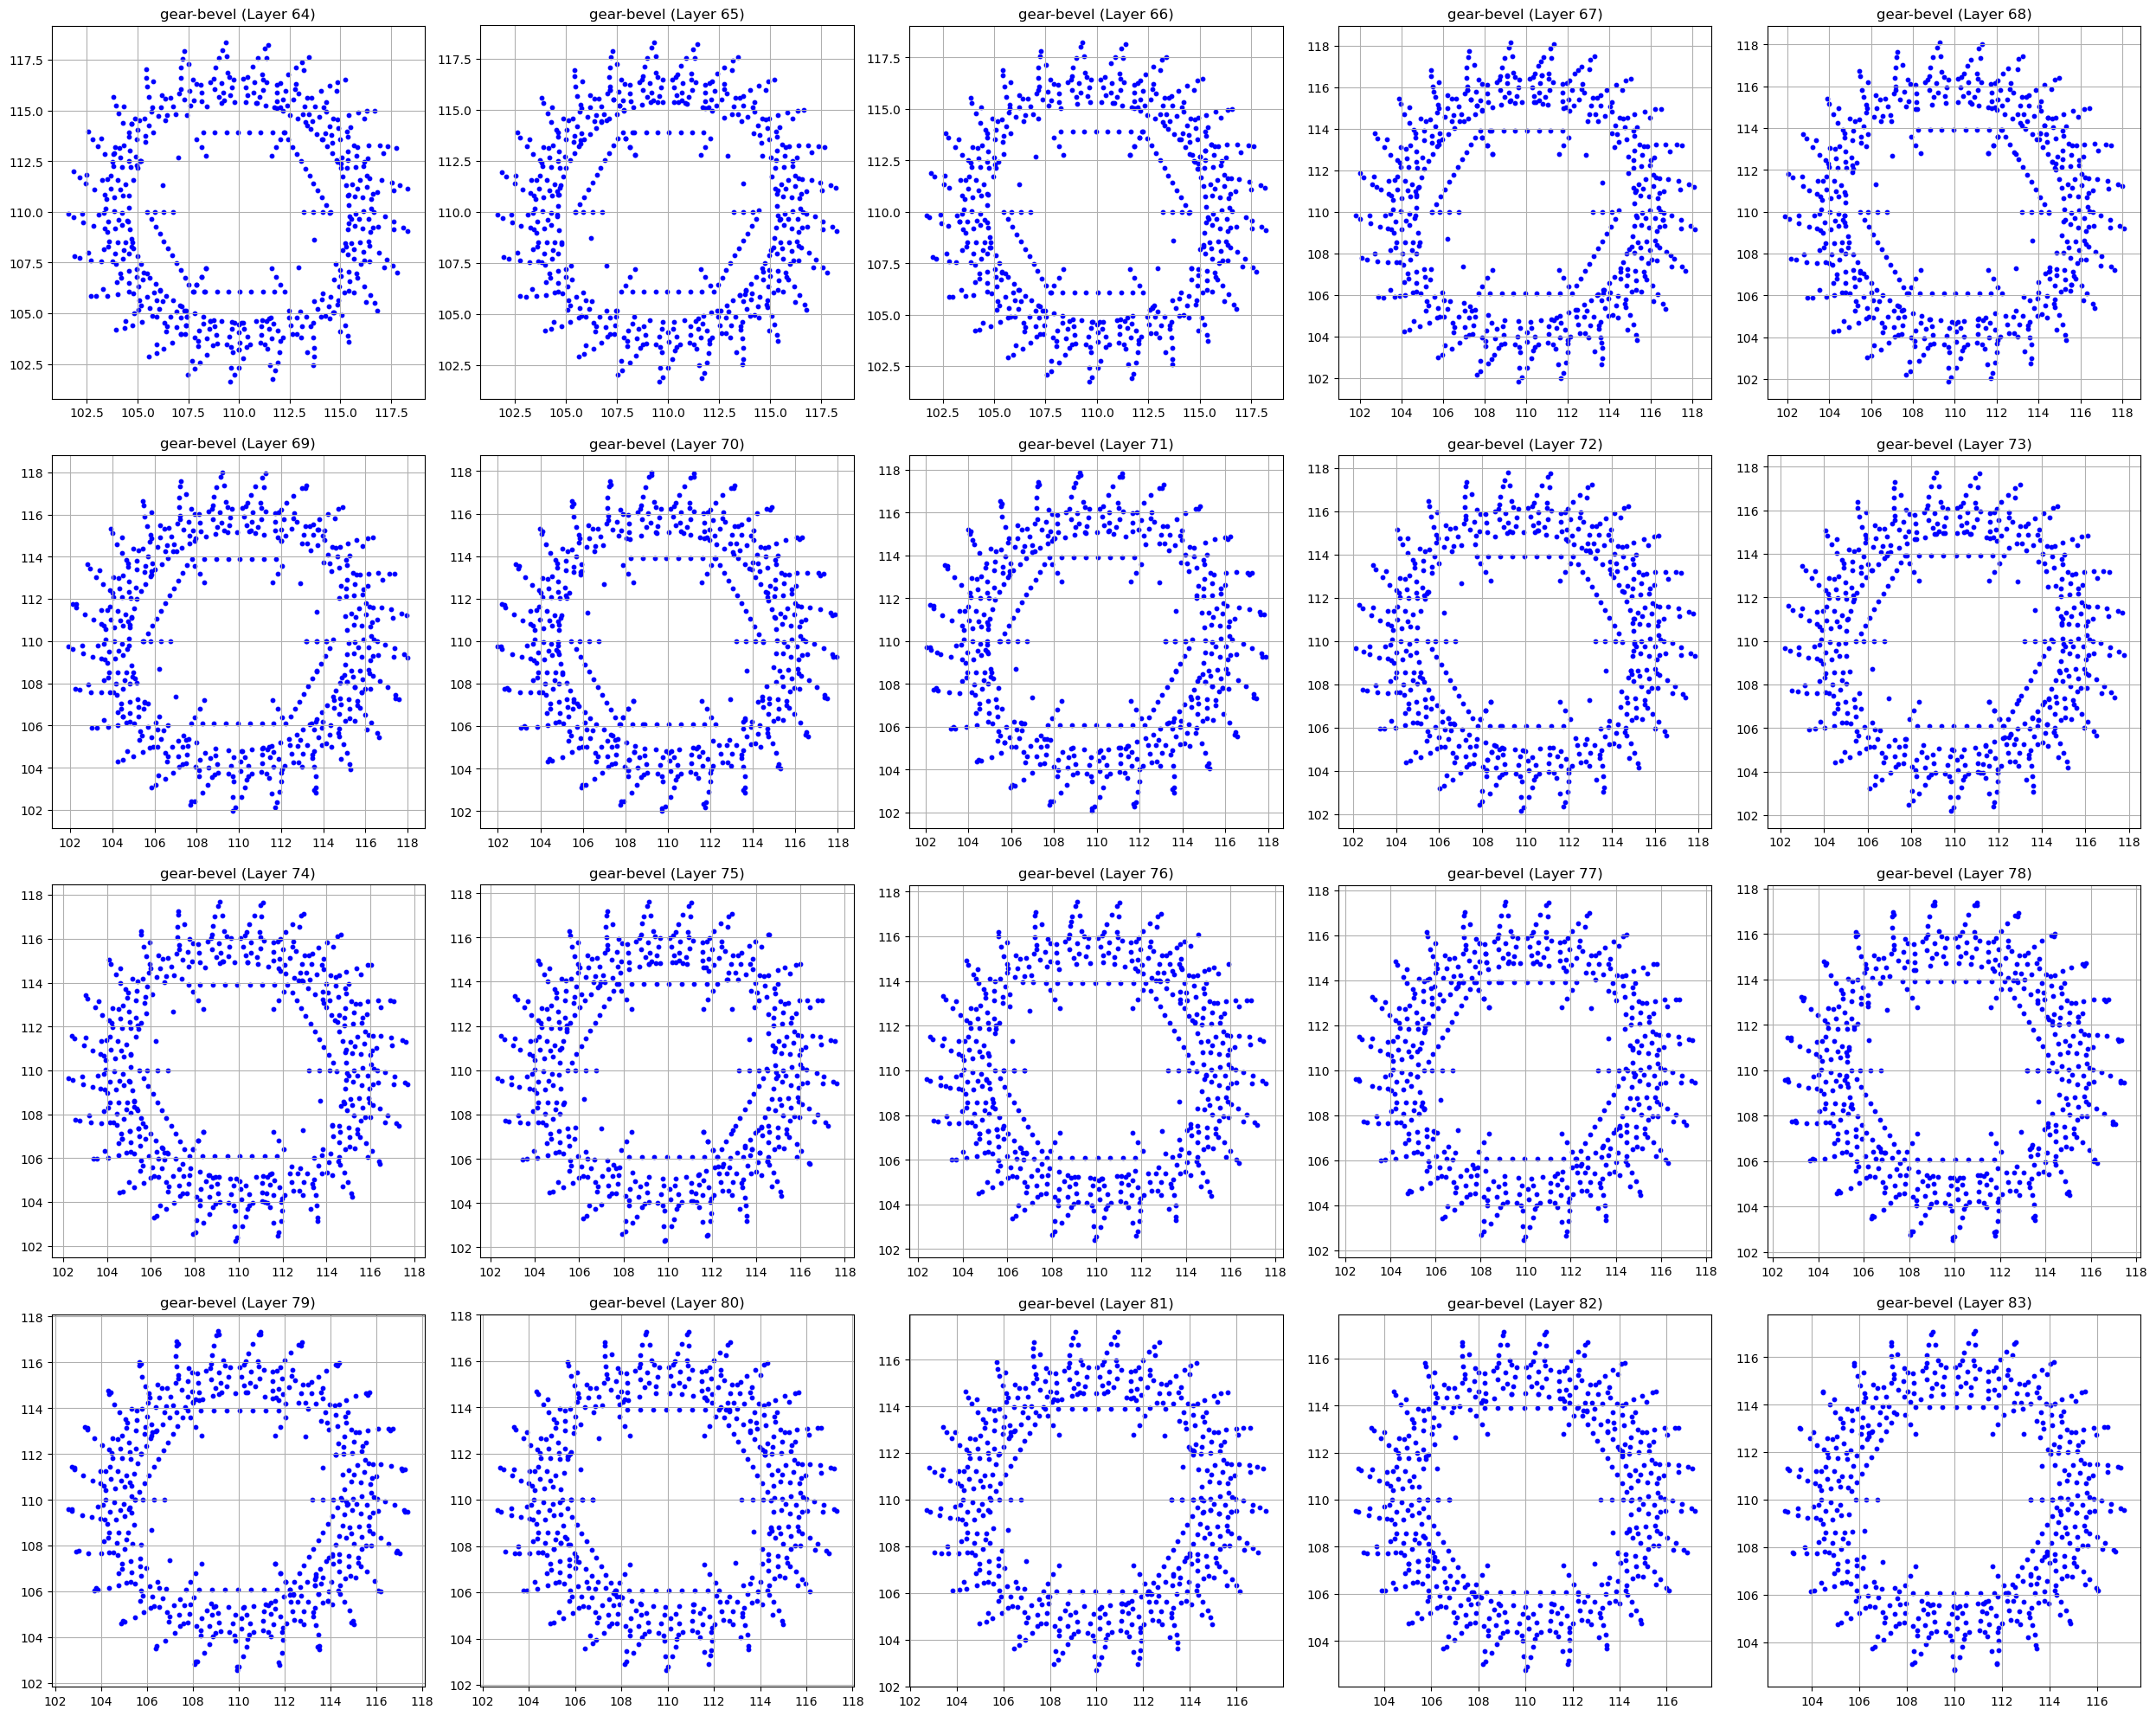

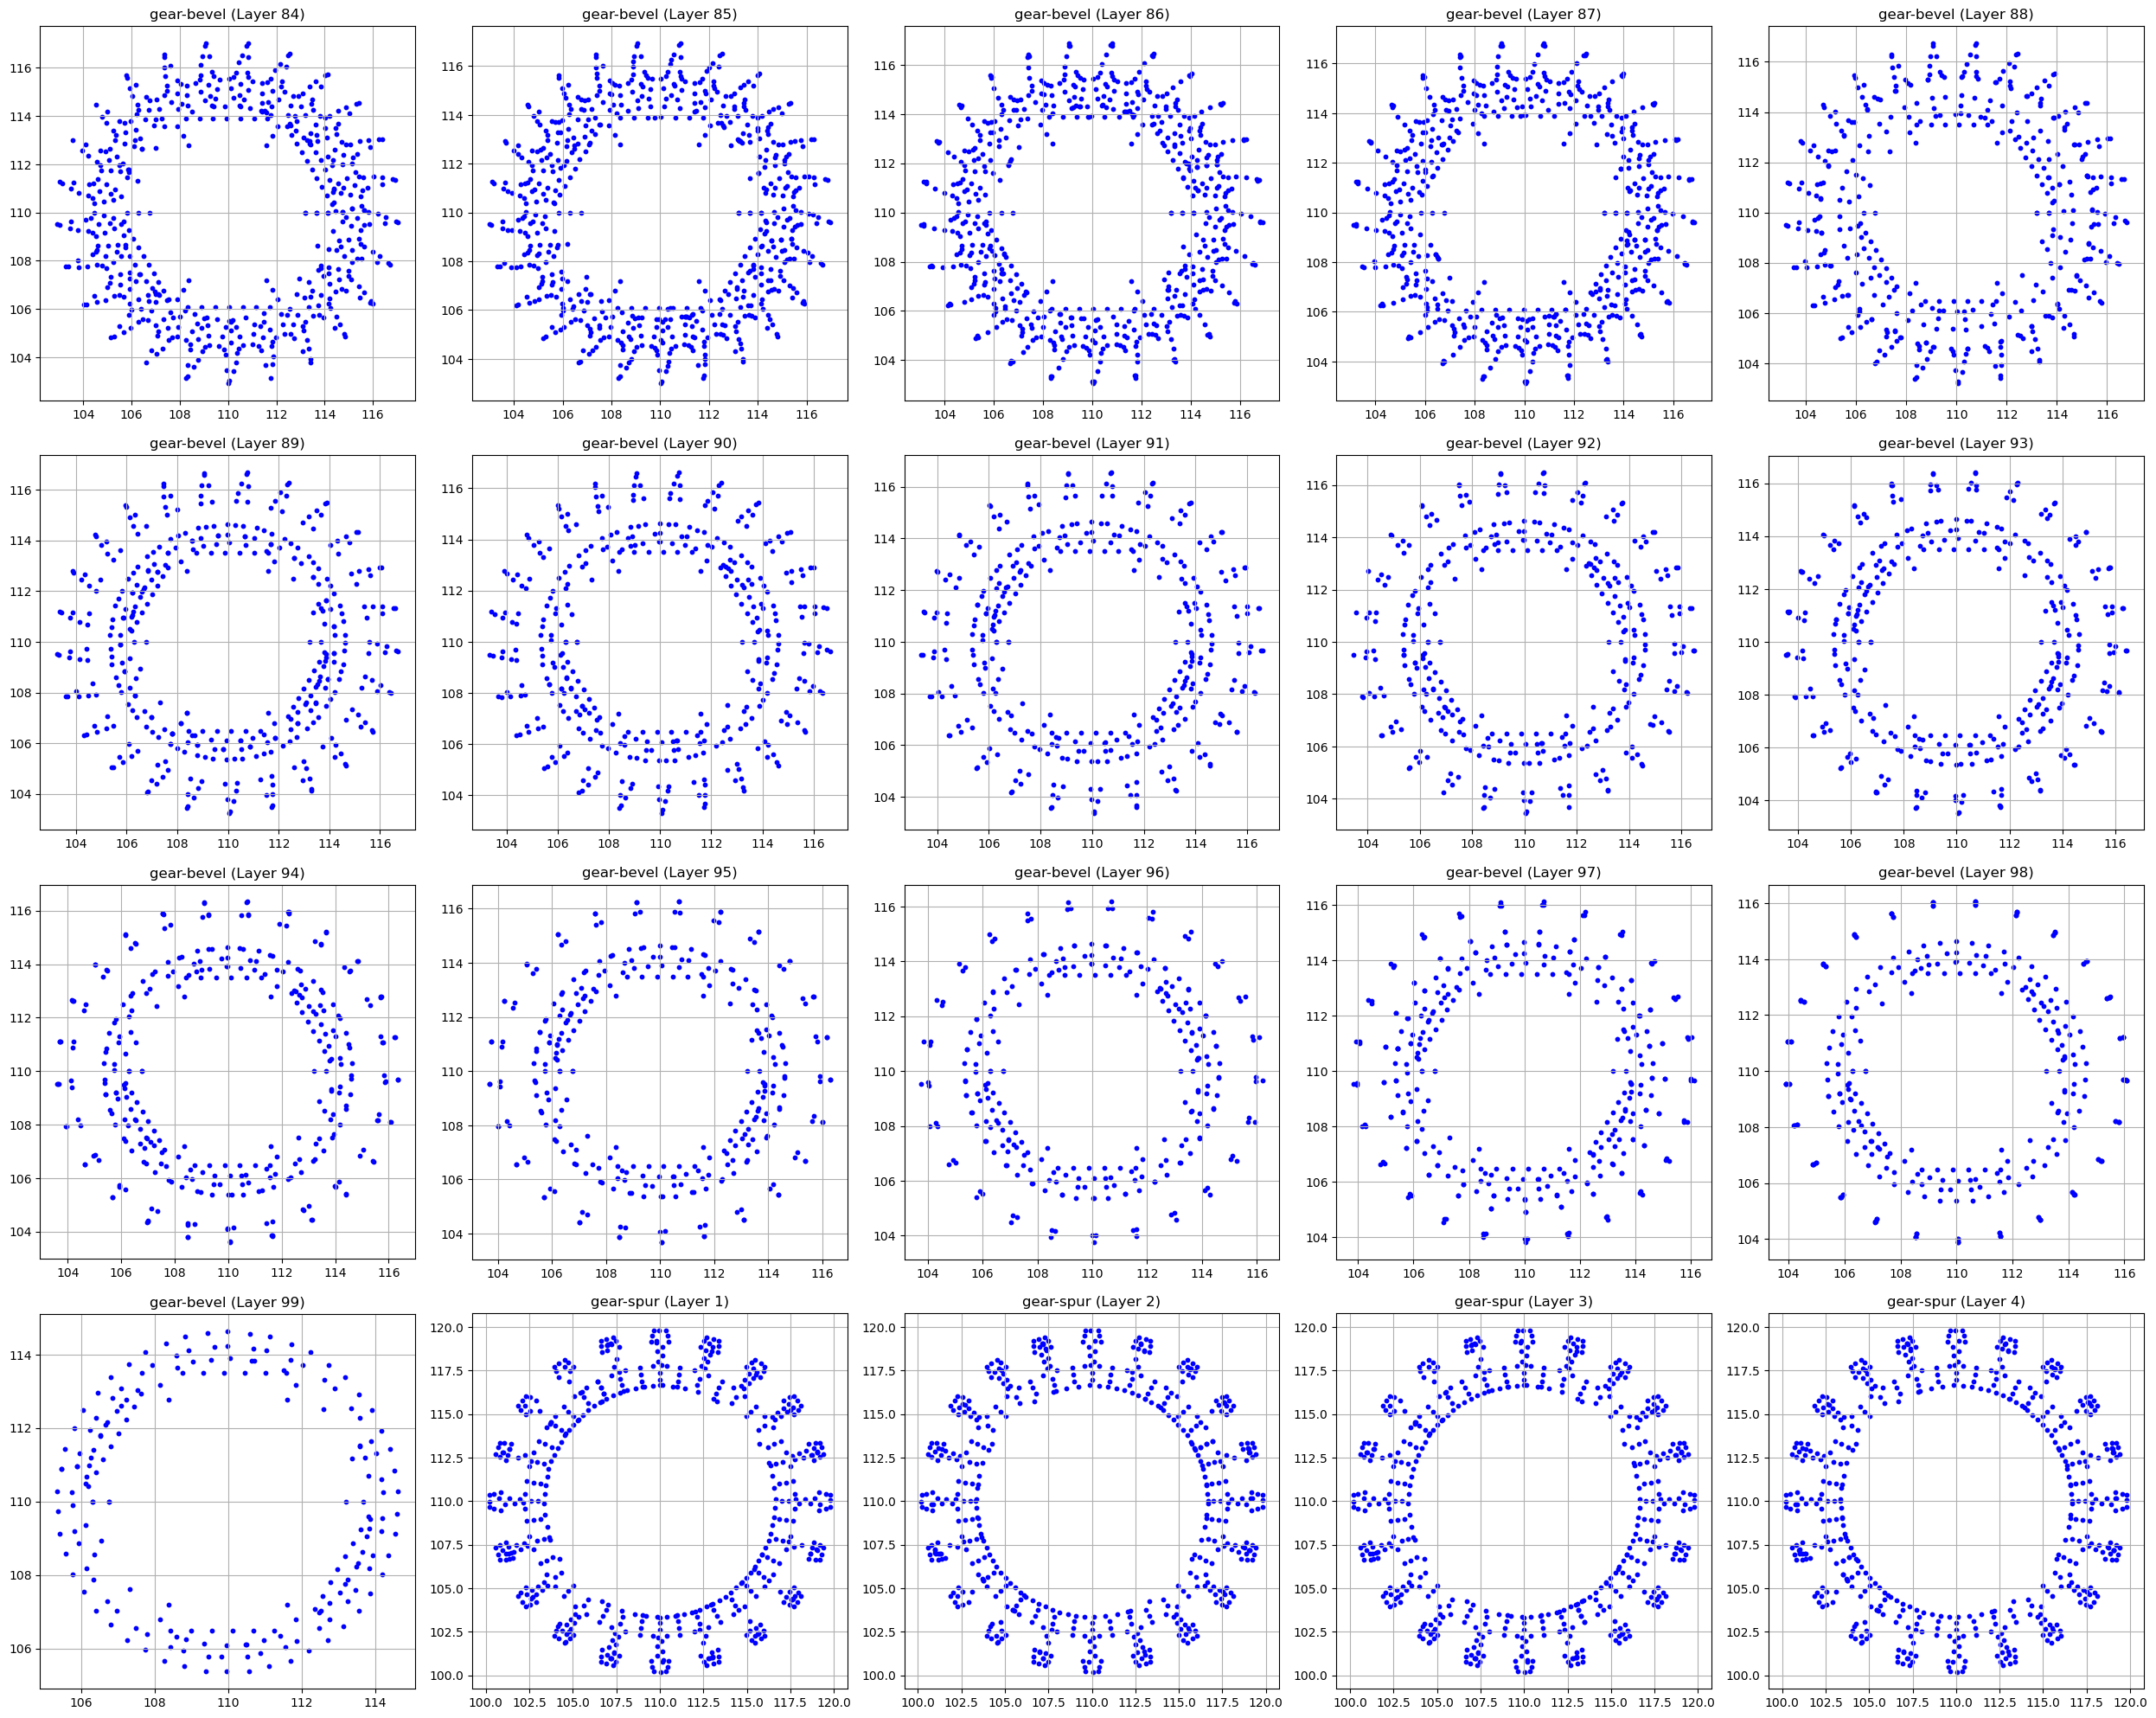

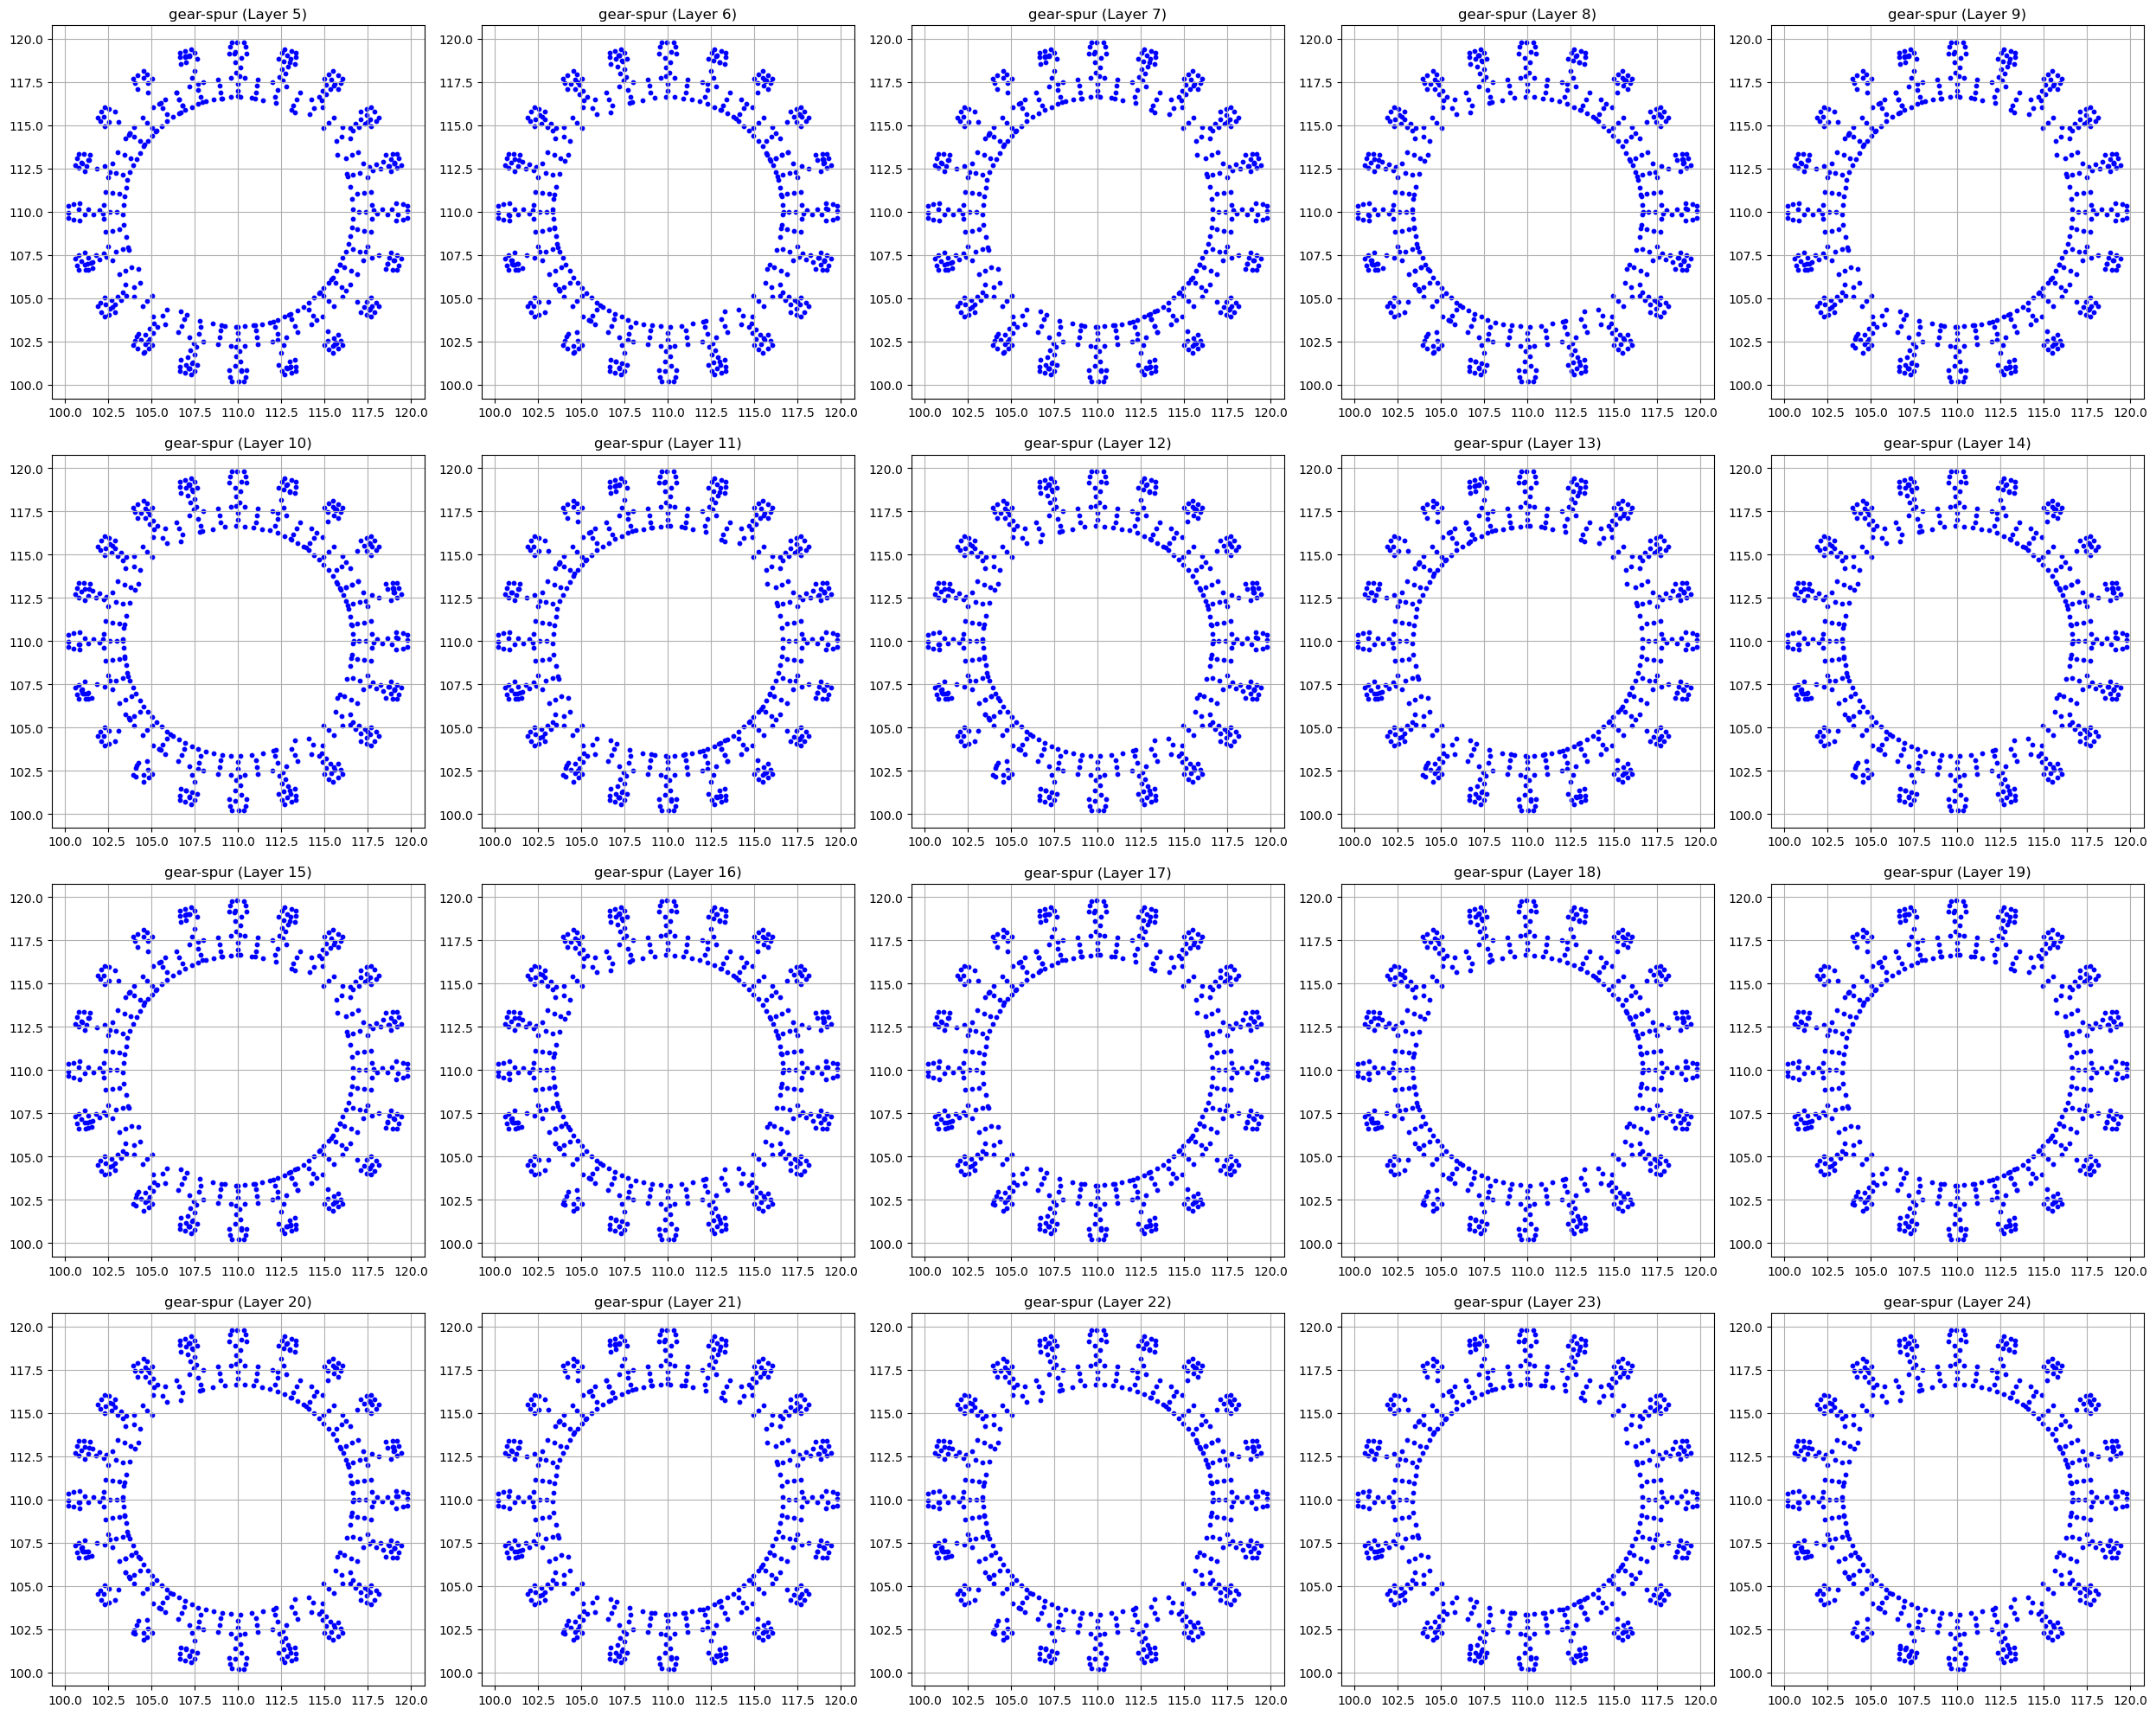

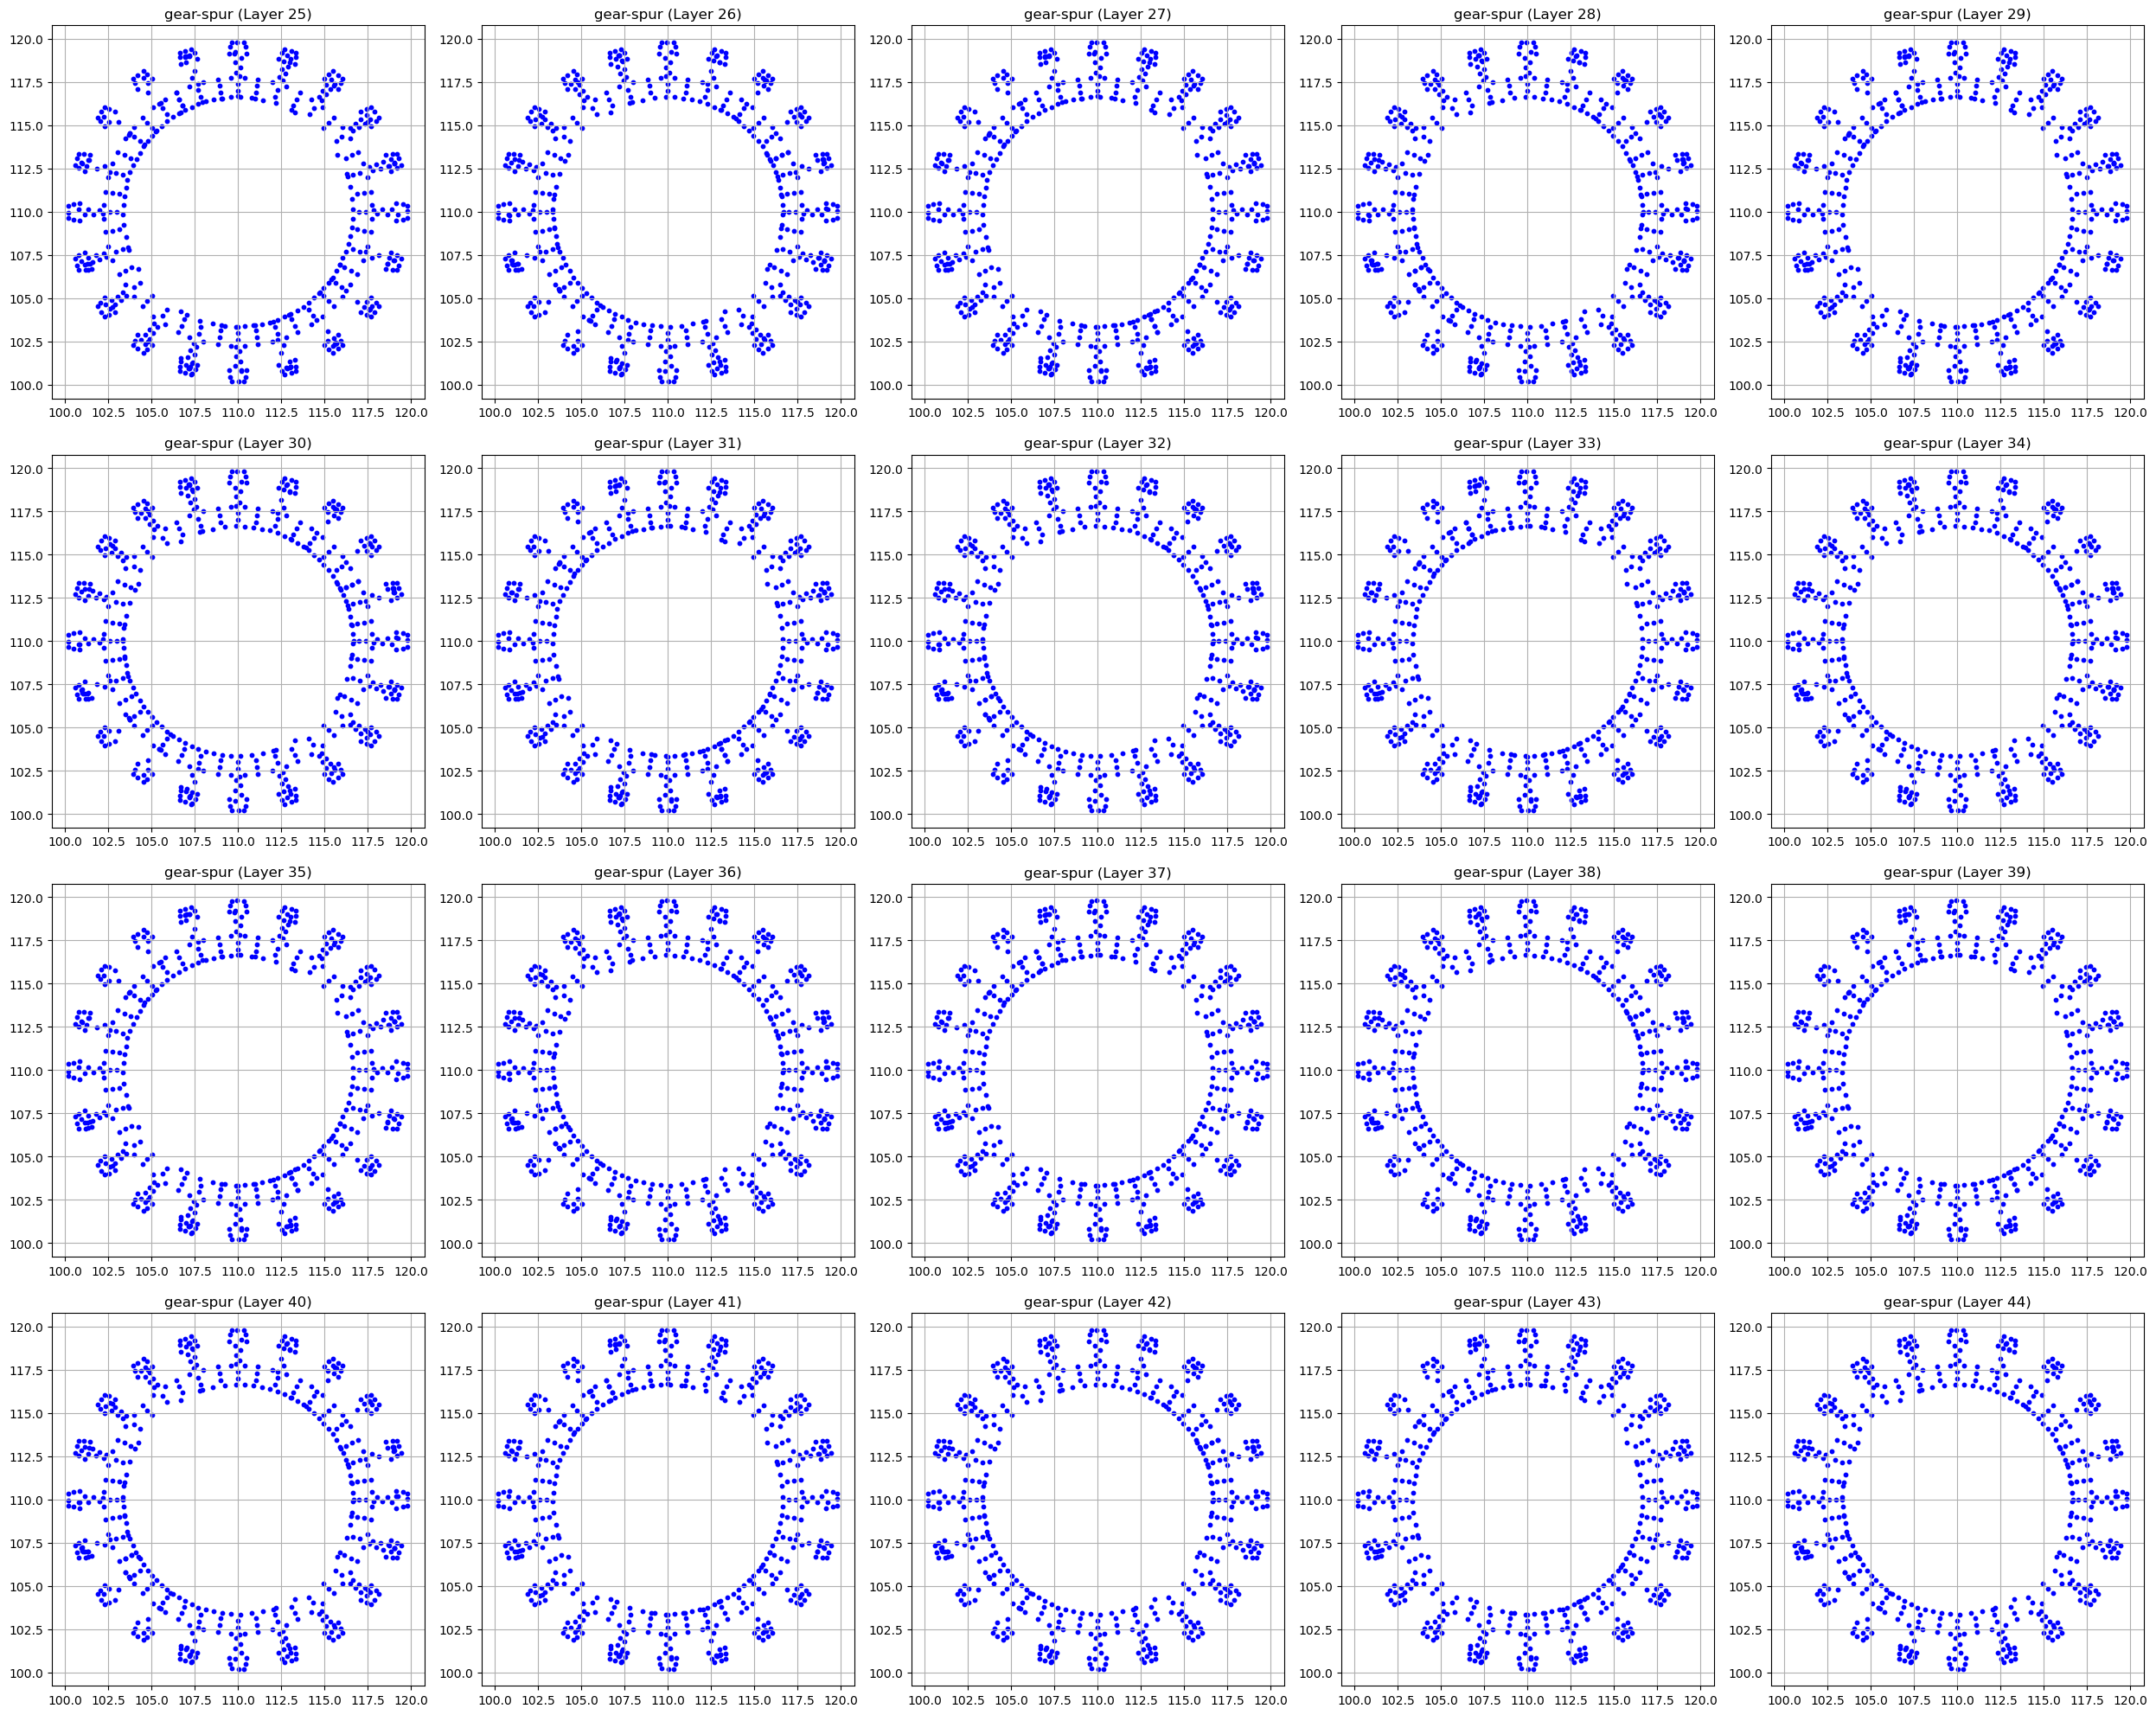

KeyboardInterrupt: 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# === Load dataset ===
npy_path = r"C:\Users\matsi\CodePResearch\Testing GAN\Coding of GAN\DataSetV2\gcode_layers_V3.npy"
loaded = np.load(npy_path, allow_pickle=True).item()

X = loaded["data"]
y = loaded["labels"]
label_map = loaded["label_map"]
name_map = {v: k for k, v in label_map.items()}

# === Collect layers with labels and local layer index ===
layers = []
for i, file in enumerate(X):
    shape_name = name_map[y[i]]
    local_layer_id = 1
    for layer in file:
        if np.any(layer):  
            points = layer[~np.all(layer == 0, axis=1)]
            if len(points) < 3:  # Skip "dot" or invalid layers
                continue
            layers.append((points, shape_name, local_layer_id))
            local_layer_id += 1

print(f"✅ Total valid layers to plot: {len(layers)}")

# === Plotting config ===
cols = 5
rows_per_fig = 4
plots_per_fig = cols * rows_per_fig

for start in range(0, len(layers), plots_per_fig):
    fig, axs = plt.subplots(rows_per_fig, cols, figsize=(5 * cols, 5 * rows_per_fig))
    axs = axs.flatten()

    for i in range(plots_per_fig):
        idx = start + i
        if idx >= len(layers):
            break

        points, shape_name, local_id = layers[idx]

        axs[i].scatter(points[:, 0], points[:, 1], s=10, color='blue')
        axs[i].set_title(f"{shape_name} (Layer {local_id})")
        #axs[i].set_xlim(-30, 140)
        #axs[i].set_ylim(-30, 140)
        axs[i].set_aspect('equal')
        axs[i].grid(True)

    for j in range(i + 1, plots_per_fig):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()
